# MVPA L2 Results Notebook

This notebook is the manuscript-facing review layer for `PROJECT_CONTEXT.md`. Results are organized in the same hierarchy used for inference: primary confirmatory tests first, secondary mechanistic/contextual analyses second, and sensitivity tests last. This order is intentional so that visually striking exploratory findings do not displace the prespecified evidence.

Aim 1 follows the current project context: placebo-session `SAD` and `HC` participants are analyzed separately for `CSR` versus `CSS` decoding in the primary `FearNetwork` feature space. The primary readout is subject-level forced-choice accuracy against a subject-label permutation null; cross-group decoding is a secondary functional-specificity/generalization check; weight-vector similarity and Haufe-transformed patterns are secondary spatial-specificity evidence.

Aim 3 follows the current project context: `dass_anxiety` and `lsas_total` are primary clinical scores. `lsas_fear` and `lsas_avoid` are shown only as secondary support/contextual decomposition of LSAS, not as primary endpoints.

The notebook is tolerant of missing optional outputs. The primary FearNetwork results are expected; MemoryFearNetwork and whole-brain/Schaefer sensitivity results are displayed when present and skipped when absent.


## Visualization And Reporting Principles

The figure style follows common high-impact MVPA/RSA reporting conventions: show the decoding evidence first, then representational geometry, learning dynamics, clinical/SCR association matrices, and sensitivity checks. The layout is inspired by multivoxel pattern and representational similarity work such as Haxby et al. (Science, 2001; DOI: `10.1126/science.1063736`), Norman et al. (Trends in Cognitive Sciences, 2006; DOI: `10.1016/j.tics.2006.07.005`), Kriegeskorte et al. (Frontiers in Systems Neuroscience, 2008; DOI: `10.3389/neuro.06.004.2008`), and Haufe et al. (NeuroImage, 2014; DOI: `10.1016/j.neuroimage.2013.10.067`) for interpretable linear-model activation patterns.

Reporting conventions:

- Primary tests are interpreted before secondary or sensitivity analyses.
- Aims 1-4 are restricted to placebo-session subjects. Aim 5 is the only analysis that includes both placebo and oxytocin participants and tests `Group * Drug`.
- Aims 2-5 use the same six primary neural metrics for primary inference. Aim 2 organizes them by question; Aims 3-5 reuse the same metric family for clinical, SCR, and oxytocin models.
- Aim 2 p-values are FDR-corrected within each planned analysis question. Aim 3 and Aim 4 p-values are FDR-corrected within diagnostic group among placebo-session participants.
- Aim 1 primary decoding uses subject-aware permutation inference; cross-group decoding and Haufe-map similarity are secondary mechanistic checks within the placebo session.
- Figures use colorblind-safe Okabe-Ito colors, signed effects centered at zero, individual subject points when available, and PNG/PDF export to `stats/figures`.


In [1]:
from pathlib import Path
import os
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

pd.set_option('display.max_columns', 160)
pd.set_option('display.max_rows', 200)

OKABE = {
    'orange': '#E69F00',
    'sky': '#56B4E9',
    'green': '#009E73',
    'yellow': '#F0E442',
    'blue': '#0072B2',
    'vermillion': '#D55E00',
    'purple': '#CC79A7',
    'black': '#000000',
    'gray': '#7A7A7A',
}
GROUP_COLORS = {'SAD': OKABE['vermillion'], 'HC': OKABE['blue']}
DRUG_COLORS = {'Placebo': OKABE['gray'], 'Oxytocin': OKABE['green']}

sns.set_theme(style='ticks', context='paper', font='Arial', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 140,
    'savefig.dpi': 300,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.8,
    'axes.labelsize': 9,
    'axes.titlesize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

root_env = os.environ.get('MVPA_L2_ROOT')
candidates = []
if root_env:
    candidates.append(Path(root_env))
candidates.extend([
    Path('/Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2'),
    Path('/gscratch/scrubbed/fanglab/xiaoqian/NARSAD/LSS/results/mvpa_l2'),
    Path('/output_dir/mvpa_l2'),
    Path('outputs/mvpa_l2'),
])
MVPA_ROOT = next((p for p in candidates if p.exists()), candidates[0])
RESULTS_ROOT = MVPA_ROOT.parent if MVPA_ROOT.name == 'mvpa_l2' else MVPA_ROOT
HARMONIZED_DIR = MVPA_ROOT / 'harmonized'
STATS_DIR = MVPA_ROOT / 'stats'
FIG_DIR = STATS_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f'MVPA_ROOT = {MVPA_ROOT}')
print(f'RESULTS_ROOT = {RESULTS_ROOT}')
print(f'STATS_DIR = {STATS_DIR}')
print(f'FIG_DIR = {FIG_DIR}')


MVPA_ROOT = /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2
RESULTS_ROOT = /Users/xiaoqianxiao/projects/NARSAD/LSS/results
STATS_DIR = /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats
FIG_DIR = /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures


In [2]:
AIM1_EXPECTED_PERMUTATIONS = 5000
AIM1_EXPECTED_NESTED_CV_REPEATS = 10
AIM1_EXPECTED_OUTER_FOLDS = 5
AIM1_EXPECTED_INNER_FOLDS = 5
AIM1_CHANCE_LEVEL = 0.5

AIM2_PRIMARY_QUESTION_METRICS = {
    'Q1_geometry': [
        'Neural_Dist_Safety_Background',
        'Neural_Dist_Threat_Safety',
    ],
    'Q2_decision_certainty': [
        'Neural_Decision_Margin_CSS',
        'Neural_Decision_Margin_CSR',
    ],
    'Q3_learning_dynamics': [
        'Neural_Safety_Trajectory_Slope',
        'Neural_Threat_Trajectory_Slope',
    ],
}

AIM2_SECONDARY_QUESTION_METRICS = {
    'Q1_geometry': [
        'Neural_Dist_Threat_Background',
    ],
    'Q2_decision_certainty': [
        'Neural_Boundary_Separation',
        'Neural_Decoder_Entropy_CSS',
        'Neural_Decoder_Entropy_CSR',
    ],
    'Q3_learning_dynamics': [],
}

AIM2_QUESTION_METRICS = {
    question: AIM2_PRIMARY_QUESTION_METRICS.get(question, []) + AIM2_SECONDARY_QUESTION_METRICS.get(question, [])
    for question in AIM2_PRIMARY_QUESTION_METRICS
}

CORE_METRICS = [
    metric
    for metrics in AIM2_PRIMARY_QUESTION_METRICS.values()
    for metric in metrics
]

SECONDARY_SUPPORT_METRICS = [
    metric
    for metrics in AIM2_SECONDARY_QUESTION_METRICS.values()
    for metric in metrics
]

COMPANION_METRICS = SECONDARY_SUPPORT_METRICS
SHARED_AIM2_TO_AIM5_METRICS = CORE_METRICS

PRIMARY_CLINICAL = ['dass_anxiety', 'lsas_total']
SECONDARY_CLINICAL = ['lsas_fear', 'lsas_avoid']
CLINICAL_HIERARCHY = {
    'dass_anxiety': {'order': 1, 'role': 'primary', 'family': 'general_anxiety', 'label': 'DASS anxiety'},
    'lsas_total': {'order': 2, 'role': 'primary', 'family': 'social_anxiety_total', 'label': 'LSAS total'},
    'lsas_fear': {'order': 3, 'role': 'support_contextual_only', 'family': 'social_anxiety_subscale', 'label': 'LSAS fear'},
    'lsas_avoid': {'order': 4, 'role': 'support_contextual_only', 'family': 'social_anxiety_subscale', 'label': 'LSAS avoidance'},
}
PRIMARY_SCR = ['SCR_SafetyMinusBackground', 'SCR_ThreatMinusSafety', 'SCR_Safety_Trajectory_Slope', 'SCR_Threat_Trajectory_Slope']
SCR_FLAGS = [
    'SCR_Physiological_Responder',
    'SCR_Simple_Acquisition_Differential_Learner',
    'SCR_Habituation_Adjusted_Learner',
    'SCR_Late_Phase_Sensitivity_Learner',
]

AIM2_QUESTION_LABELS = {
    'Q1_geometry': 'Where are safety and threat in neural space?',
    'Q2_decision_certainty': 'Are safety and threat cues represented decisively or ambiguously?',
    'Q3_learning_dynamics': 'How do safety and threat representations change over learning?',
}

AIM2_METRIC_TO_QUESTION = {
    metric: question
    for question, metrics in AIM2_QUESTION_METRICS.items()
    for metric in metrics
}
AIM2_METRIC_ROLE = {
    metric: 'primary'
    for metrics in AIM2_PRIMARY_QUESTION_METRICS.values()
    for metric in metrics
}
AIM2_METRIC_ROLE.update({
    metric: 'secondary'
    for metrics in AIM2_SECONDARY_QUESTION_METRICS.values()
    for metric in metrics
})
AIM2_PLANNED_METRICS = [
    metric
    for question in AIM2_QUESTION_METRICS
    for metric in AIM2_QUESTION_METRICS[question]
]

PROJECT_CONTEXT_PATH = Path('PROJECT_CONTEXT.md')

LEGACY_CHECKPOINT_NAMES = {
    'cell_06.joblib',
    'stage11_importance_masks.joblib',
    'analysis_12_topology.joblib',
    'cell_12_trajectories.joblib',
    'cell_13_decision_stats_opt.joblib',
    'cell_16_opening_test.joblib',
    'cell_17_realignment.joblib',
    'cell_18_reverse_cross_decoding.joblib',
}

PATHS = {
    'subject_metrics': HARMONIZED_DIR / 'mvpa_l2_subject_metrics.csv',
    'scr_flags': HARMONIZED_DIR / 'scr_sensitivity_groups.csv',
    'aim1_primary': STATS_DIR / 'aim1_decoding_primary.csv',
    'aim1_scr_sensitivity': STATS_DIR / 'aim1_scr_sensitivity.csv',
    'aim2': STATS_DIR / 'aim2_group_difference.csv',
    'aim2_haufe_scr_sensitivity': STATS_DIR / 'aim2_haufe_scr_sensitivity.csv',
    'aim2_haufe_scr_sensitivity_roi': STATS_DIR / 'aim2_haufe_scr_sensitivity_roi_distribution.csv',
    'aim3': STATS_DIR / 'aim3_clinical_relevance.csv',
    'aim4': STATS_DIR / 'aim4_scr_convergence.csv',
    'aim5': STATS_DIR / 'aim5_oxytocin_modulation.csv',
    'primary_all': STATS_DIR / 'primary_models_all.csv',
    'manuscript_primary': STATS_DIR / 'manuscript_primary_results.csv',
    'manuscript_primary_md': STATS_DIR / 'manuscript_primary_results.md',
    'aim4_convergence_matrix': STATS_DIR / 'aim4_convergence_matrix.csv',
    'aim4_convergence_matrix_wide': STATS_DIR / 'aim4_convergence_matrix_wide.csv',
    'aim4_convergence_md': STATS_DIR / 'aim4_convergence_matrix.md',
    'qc_dashboard_md': STATS_DIR / 'mvpa_l2_qc_dashboard.md',
    'qc_subject_counts': STATS_DIR / 'qc_subject_counts.csv',
    'qc_missingness': STATS_DIR / 'qc_missingness.csv',
    'qc_model_status_counts': STATS_DIR / 'qc_model_status_counts.csv',
    'sensitivity_all': STATS_DIR / 'sensitivity_models_all.csv',
    'summary_md': STATS_DIR / 'mvpa_l2_results_summary.md',
}

def read_csv_or_empty(path):
    path = Path(path)
    if not path.exists():
        print(f'Missing: {path}')
        return pd.DataFrame()
    df = pd.read_csv(path)
    print(f'Loaded {path.name}: {df.shape[0]} rows x {df.shape[1]} columns')
    return df

metrics_df = read_csv_or_empty(PATHS['subject_metrics'])
scr_flags_df = read_csv_or_empty(PATHS['scr_flags'])
aim1_primary_df = read_csv_or_empty(PATHS['aim1_primary'])
aim1_scr_df = read_csv_or_empty(PATHS['aim1_scr_sensitivity'])
aim2_df = read_csv_or_empty(PATHS['aim2'])
aim2_haufe_scr_df = read_csv_or_empty(PATHS['aim2_haufe_scr_sensitivity'])
aim2_haufe_scr_roi_df = read_csv_or_empty(PATHS['aim2_haufe_scr_sensitivity_roi'])
aim3_df = read_csv_or_empty(PATHS['aim3'])
aim4_df = read_csv_or_empty(PATHS['aim4'])
aim5_df = read_csv_or_empty(PATHS['aim5'])
primary_all_df = read_csv_or_empty(PATHS['primary_all'])
manuscript_primary_df = read_csv_or_empty(PATHS['manuscript_primary'])
aim4_convergence_df = read_csv_or_empty(PATHS['aim4_convergence_matrix'])
aim4_convergence_wide_df = read_csv_or_empty(PATHS['aim4_convergence_matrix_wide'])
qc_subject_counts_df = read_csv_or_empty(PATHS['qc_subject_counts'])
qc_missingness_df = read_csv_or_empty(PATHS['qc_missingness'])
qc_model_status_counts_df = read_csv_or_empty(PATHS['qc_model_status_counts'])
sensitivity_df = read_csv_or_empty(PATHS['sensitivity_all'])


Loaded mvpa_l2_subject_metrics.csv: 248 rows x 97 columns
Loaded scr_sensitivity_groups.csv: 104 rows x 44 columns
Missing: /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/aim1_decoding_primary.csv
Loaded aim1_scr_sensitivity.csv: 36 rows x 20 columns
Loaded aim2_group_difference.csv: 7 rows x 21 columns
Loaded aim2_haufe_scr_sensitivity.csv: 8 rows x 18 columns
Loaded aim2_haufe_scr_sensitivity_roi_distribution.csv: 60 rows x 14 columns
Loaded aim3_clinical_relevance.csv: 56 rows x 32 columns
Loaded aim4_scr_convergence.csv: 56 rows x 21 columns
Loaded aim5_oxytocin_modulation.csv: 7 rows x 20 columns
Loaded primary_models_all.csv: 126 rows x 41 columns
Missing: /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/manuscript_primary_results.csv
Missing: /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/aim4_convergence_matrix.csv
Missing: /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/aim4_convergence_matrix_wide.csv
Missing: /Users/xi

## Data Availability

This section checks whether the notebook has the files needed for each aim and verifies the available diagnostic groups, drug conditions, and feature spaces. Missing whole-brain/Schaefer outputs are reported as absent sensitivity checks, not as negative results.


,file,path,exists
0,subject_metrics,/Users/xiaoqianxiao/projects/NARSAD/LSS/result...,True
1,scr_flags,/Users/xiaoqianxiao/projects/NARSAD/LSS/result...,True
2,aim1_primary,/Users/xiaoqianxiao/projects/NARSAD/LSS/result...,False
3,aim1_scr_sensitivity,/Users/xiaoqianxiao/projects/NARSAD/LSS/result...,True
4,aim2,/Users/xiaoqianxiao/projects/NARSAD/LSS/result...,True
5,aim2_haufe_scr_sensitivity,/Users/xiaoqianxiao/projects/NARSAD/LSS/result...,True
6,aim2_haufe_scr_sensitivity_roi,/Users/xiaoqianxiao/projects/NARSAD/LSS/result...,True
7,aim3,/Users/xiaoqianxiao/projects/NARSAD/LSS/result...,True
8,aim4,/Users/xiaoqianxiao/projects/NARSAD/LSS/result...,True
9,aim5,/Users/xiaoqianxiao/projects/NARSAD/LSS/result...,True


,FeatureSpace,Group,Drug,n_rows
0,FearNetwork,HC,Oxytocin,24
1,FearNetwork,HC,Placebo,29
2,FearNetwork,SAD,Oxytocin,28
3,FearNetwork,SAD,Placebo,23
4,FearNetwork,NaN,NaN,20
5,MemoryFearNetwork,HC,Oxytocin,24
6,MemoryFearNetwork,HC,Placebo,29
7,MemoryFearNetwork,SAD,Oxytocin,28
8,MemoryFearNetwork,SAD,Placebo,23
9,MemoryFearNetwork,NaN,NaN,20


Available feature spaces: ['FearNetwork', 'MemoryFearNetwork']
Whole-brain/Schaefer sensitivity output is absent. This is allowed by the current no-wholebrain workflow.


,SCR subgroup,n_subjects
0,SCR_Physiological_Responder,59
1,SCR_Simple_Acquisition_Differential_Learner,41
2,SCR_Habituation_Adjusted_Learner,32
3,SCR_Late_Phase_Sensitivity_Learner,22


Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/intro_scr_cohort_sizes.png
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/intro_scr_cohort_sizes.pdf


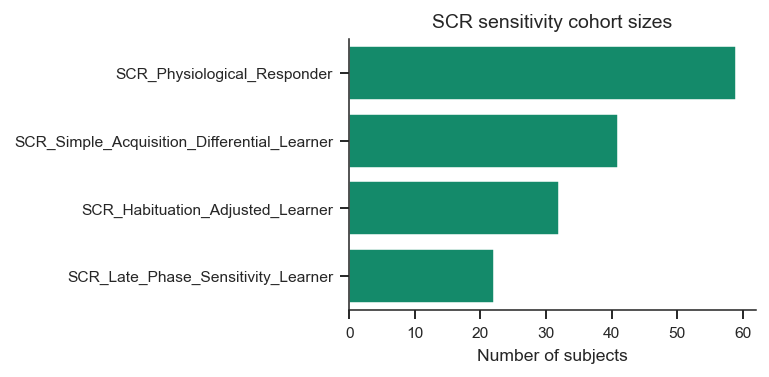

In [3]:
file_status = pd.DataFrame({
    'file': list(PATHS.keys()),
    'path': [str(p) for p in PATHS.values()],
    'exists': [Path(p).exists() for p in PATHS.values()],
})
display(file_status)

if not metrics_df.empty:
    id_cols = [c for c in ['FeatureSpace', 'Group', 'Drug'] if c in metrics_df.columns]
    if id_cols:
        display(metrics_df.groupby(id_cols, dropna=False).size().rename('n_rows').reset_index())
    if 'FeatureSpace' in metrics_df.columns:
        feature_spaces = sorted(metrics_df['FeatureSpace'].dropna().astype(str).unique())
    else:
        feature_spaces = []
else:
    feature_spaces = []

print(f'Available feature spaces: {feature_spaces}')
has_wholebrain = any(fs.lower() in {'schaefer', 'wholebrain', 'wholebrain_schaefer', 'wholebrainparcellation'} for fs in feature_spaces)
if not has_wholebrain:
    print('Whole-brain/Schaefer sensitivity output is absent. This is allowed by the current no-wholebrain workflow.')

if not scr_flags_df.empty:
    flag_cols = [c for c in SCR_FLAGS if c in scr_flags_df.columns]
    if flag_cols:
        counts = scr_flags_df[flag_cols].sum().rename('n_subjects').reset_index().rename(columns={'index': 'SCR subgroup'})
        display(counts)
        fig, ax = plt.subplots(figsize=(5.6, 2.8))
        sns.barplot(data=counts, y='SCR subgroup', x='n_subjects', color=OKABE['green'], ax=ax)
        ax.set_xlabel('Number of subjects')
        ax.set_ylabel('')
        ax.set_title('SCR sensitivity cohort sizes')
        fig.tight_layout()
        png = FIG_DIR / 'intro_scr_cohort_sizes.png'
        pdf = FIG_DIR / 'intro_scr_cohort_sizes.pdf'
        fig.savefig(png, bbox_inches='tight', dpi=300)
        fig.savefig(pdf, bbox_inches='tight')
        print(f'Saved {png}')
        print(f'Saved {pdf}')
        display(fig)
        plt.close(fig)


In [4]:
def select_columns(df, preferred):
    return [c for c in preferred if c in df.columns]

def tidy_result_table(df, n=30):
    if df is None or df.empty:
        return pd.DataFrame()
    cols = select_columns(df, [
        'aim', 'scientific_question', 'analysis', 'sensitivity', 'feature_space', 'FeatureSpace', 'session', 'include_subjects_flag', 'Group', 'Drug', 'metric', 'metric_order', 'metric_role', 'metric_z',
        'clinical_score', 'clinical_score_label', 'clinical_score_order', 'clinical_score_role', 'clinical_score_z', 'scr_index', 'effect_label', 'effect_scale', 'test', 'term', 'estimate', 'ci_low', 'ci_high',
        'p', 'p_value', 'q', 'q_within_question', 'q_within_group', 'q_within_group_clinical_score', 'correction_family', 'aim3_clinical_score_family', 'n', 'n_sad_subjects', 'n_hc_subjects', 'n_clinical_outliers_removed',
        'n_metric_outliers_removed', 'r2', 'status', 'formula'
    ])
    out = df[cols].copy() if cols else df.copy()
    p_col = 'p' if 'p' in out.columns else 'p_value' if 'p_value' in out.columns else None
    if p_col:
        out['_p_sort'] = pd.to_numeric(out[p_col], errors='coerce')
        out = out.sort_values('_p_sort', na_position='last').drop(columns='_p_sort')
    return out.head(n)

def model_rows(df):
    if df is None or df.empty:
        return pd.DataFrame()
    out = df.copy()
    if 'status' in out.columns:
        out = out[out['status'].fillna('ok').eq('ok')]
    return out

def hierarchy_result_table(df, n=160):
    if df is None or df.empty:
        return pd.DataFrame()
    cols = select_columns(df, [
        'aim', 'scientific_question', 'feature_space', 'session', 'Group', 'clinical_score_label', 'clinical_score_role', 'scr_index', 'metric', 'metric_role', 'effect_label', 'effect_scale', 'estimate', 'ci_low', 'ci_high', 'p', 'q', 'n', 'status'
    ])
    out = df[cols].copy() if cols else df.copy()
    sort_cols = [c for c in ['aim', 'clinical_score_order', 'Group', 'metric_order', 'scr_index'] if c in df.columns]
    if sort_cols:
        out = out.assign(**{f'_sort_{c}': df[c].values for c in sort_cols})
        out = out.sort_values([f'_sort_{c}' for c in sort_cols], na_position='last')
        out = out.drop(columns=[f'_sort_{c}' for c in sort_cols])
    return out.head(n)

def numeric_col(df, col):
    return pd.to_numeric(df[col], errors='coerce') if col in df.columns else pd.Series(np.nan, index=df.index)


def bh_fdr(p_values):
    p = pd.to_numeric(pd.Series(p_values), errors='coerce')
    q = pd.Series(np.nan, index=p.index, dtype=float)
    valid = p.dropna().sort_values()
    m = len(valid)
    if m == 0:
        return q
    raw = valid * m / np.arange(1, m + 1)
    adjusted = np.minimum.accumulate(raw.iloc[::-1]).iloc[::-1].clip(upper=1.0)
    q.loc[adjusted.index] = adjusted
    return q

def prepare_aim2_questions(df):
    base_cols = ['analysis', 'feature_space', 'term', 'estimate', 'std_error', 't', 'p', 'ci_low', 'ci_high', 'n', 'r2', 'formula', 'status']
    out = df.copy() if df is not None and not df.empty else pd.DataFrame(columns=base_cols + ['metric'])
    if 'metric' not in out.columns:
        out['metric'] = pd.Series(dtype=object)
    out = out[out['metric'].isin(AIM2_PLANNED_METRICS)].copy()
    out['aim2_question'] = out['metric'].map(AIM2_METRIC_TO_QUESTION)
    out['aim2_question_label'] = out['aim2_question'].map(AIM2_QUESTION_LABELS)
    order_map = {question: i for i, question in enumerate(AIM2_QUESTION_METRICS, start=1)}
    out['aim2_question_order'] = out['aim2_question'].map(order_map)
    out['metric_role'] = out['metric'].map(AIM2_METRIC_ROLE).fillna('secondary')
    if 'status' not in out.columns:
        out['status'] = 'ok'
    existing = set(out['metric'].dropna())
    missing_rows = []
    for question, metrics in AIM2_QUESTION_METRICS.items():
        for metric in metrics:
            if metric in existing:
                continue
            missing_rows.append({
                'analysis': 'Aim2_SAD_HC_Placebo',
                'feature_space': 'FearNetwork',
                'metric': metric,
                'aim2_question': question,
                'aim2_question_label': AIM2_QUESTION_LABELS[question],
                'aim2_question_order': order_map[question],
                'metric_role': AIM2_METRIC_ROLE.get(metric, 'secondary'),
                'status': 'metric_missing_from_current_export',
                'n': 0,
            })
    if missing_rows:
        out = pd.concat([out, pd.DataFrame(missing_rows)], ignore_index=True, sort=False)
    p_col = 'p' if 'p' in out.columns else 'p_value' if 'p_value' in out.columns else None
    if p_col:
        out['q_within_question'] = np.nan
        ok_mask = out['status'].fillna('ok').eq('ok')
        for question, idx in out[ok_mask].groupby('aim2_question', dropna=False).groups.items():
            out.loc[idx, 'q_within_question'] = bh_fdr(out.loc[idx, p_col]).values
        out['q'] = out['q_within_question']
    role_order = {'primary': 0, 'shared_primary': 0, 'secondary': 1, 'support_contextual_only': 1}
    metric_order_map = {metric: i for i, metric in enumerate(AIM2_PLANNED_METRICS)}
    out['_metric_order'] = out['metric'].map(metric_order_map).fillna(999)
    out['_metric_role_order'] = out['metric_role'].map(role_order).fillna(9)
    out = out.sort_values(['aim2_question_order', '_metric_role_order', '_metric_order', 'metric'], na_position='last').drop(columns=['_metric_order', '_metric_role_order'])
    return out


def save_figure(fig, name):
    png = FIG_DIR / f'{name}.png'
    pdf = FIG_DIR / f'{name}.pdf'
    fig.savefig(png, bbox_inches='tight', dpi=300)
    fig.savefig(pdf, bbox_inches='tight')
    print(f'Saved {png}')
    print(f'Saved {pdf}')

def show_figure_once(fig):
    if fig is None:
        return None
    display(fig)
    plt.close(fig)
    return None

def add_panel_label(ax, label):
    ax.text(-0.12, 1.06, label, transform=ax.transAxes, fontsize=11, fontweight='bold', va='top', ha='left')

def label_from_row(row, fields):
    values = []
    for field in fields:
        if field in row.index and pd.notna(row[field]):
            values.append(str(row[field]))
    return ' | '.join(values) if values else str(row.name)

def plot_forest(df, title, top_n=25, label_fields=None, filename=None, color_by_q=True):
    sub = model_rows(df)
    needed = {'estimate', 'ci_low', 'ci_high'}
    if sub.empty or not needed.issubset(sub.columns):
        print(f'No forest plot available for {title}.')
        return None
    sub = sub.copy()
    label_fields = label_fields or ['metric', 'clinical_score', 'scr_index', 'sensitivity', 'feature_space', 'test']
    sub['label'] = sub.apply(lambda r: label_from_row(r, label_fields), axis=1)
    p_col = 'p' if 'p' in sub.columns else 'p_value' if 'p_value' in sub.columns else None
    if p_col:
        sub['_p_sort'] = numeric_col(sub, p_col)
        sub = sub.sort_values('_p_sort', na_position='last').drop(columns='_p_sort')
    sub = sub.head(top_n)
    est = numeric_col(sub, 'estimate')
    lo = numeric_col(sub, 'ci_low')
    hi = numeric_col(sub, 'ci_high')
    valid = est.notna() & lo.notna() & hi.notna()
    sub = sub[valid]
    est = est[valid]
    lo = lo[valid]
    hi = hi[valid]
    if sub.empty:
        print(f'No finite estimates for {title}.')
        return None
    y = np.arange(len(sub))
    if color_by_q and 'q' in sub.columns:
        q = numeric_col(sub, 'q').fillna(np.inf)
        colors = np.where(q < 0.05, OKABE['vermillion'], OKABE['blue'])
    else:
        colors = OKABE['blue']
    fig, ax = plt.subplots(figsize=(7.2, max(2.8, 0.27 * len(sub))))
    ax.axvline(0, color='0.45', linewidth=0.8)
    ax.errorbar(est, y, xerr=[est - lo, hi - est], fmt='none', ecolor='0.55', elinewidth=0.9, capsize=2)
    ax.scatter(est, y, c=colors, s=28, zorder=3)
    ax.set_yticks(y)
    ax.set_yticklabels(sub['label'])
    ax.invert_yaxis()
    ax.set_xlabel('Model estimate with 95% CI')
    ax.set_title(title)
    sns.despine(ax=ax)
    fig.tight_layout()
    if filename:
        save_figure(fig, filename)
    return fig

def signed_logp_heatmap(df, row_col, col_col, title, group_col=None, filename=None):
    sub = model_rows(df)
    if sub.empty or row_col not in sub.columns or col_col not in sub.columns or 'estimate' not in sub.columns:
        print(f'No heatmap available for {title}.')
        return None
    p_col = 'p' if 'p' in sub.columns else 'p_value' if 'p_value' in sub.columns else None
    if not p_col:
        print(f'No p-value column available for {title}.')
        return None
    sub = sub.copy()
    pvals = numeric_col(sub, p_col).clip(lower=1e-300)
    sub['signed_logp'] = np.sign(numeric_col(sub, 'estimate')) * -np.log10(pvals)
    if group_col and group_col in sub.columns:
        groups = [g for g in ['SAD', 'HC'] if g in set(sub[group_col].dropna())]
        if not groups:
            groups = sorted(sub[group_col].dropna().unique())
        fig, axes = plt.subplots(1, len(groups), figsize=(4.4 * len(groups), 4.4), squeeze=False)
        axes = axes.ravel()
        vmax = np.nanpercentile(np.abs(sub['signed_logp']), 95) if sub['signed_logp'].notna().any() else 1
        vmax = max(vmax, 1)
        for ax, group in zip(axes, groups):
            mat = sub[sub[group_col].eq(group)].pivot_table(index=row_col, columns=col_col, values='signed_logp', aggfunc='mean')
            sns.heatmap(mat, cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax, linewidths=0.5, linecolor='white', cbar=ax is axes[-1], cbar_kws={'label': 'Signed -log10(p)'}, ax=ax)
            ax.set_title(str(group))
            ax.set_xlabel(col_col)
            ax.set_ylabel(row_col if ax is axes[0] else '')
    else:
        mat = sub.pivot_table(index=row_col, columns=col_col, values='signed_logp', aggfunc='mean')
        fig, ax = plt.subplots(figsize=(max(4.5, 0.55 * mat.shape[1]), max(3.5, 0.38 * mat.shape[0])))
        vmax = np.nanpercentile(np.abs(mat.values), 95) if np.isfinite(mat.values).any() else 1
        vmax = max(vmax, 1)
        sns.heatmap(mat, cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax, linewidths=0.5, linecolor='white', cbar_kws={'label': 'Signed -log10(p)'}, ax=ax)
        ax.set_xlabel(col_col)
        ax.set_ylabel(row_col)
    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    if filename:
        save_figure(fig, filename)
    return fig

def plot_subject_metric_grid(df, metrics, title, feature_space='FearNetwork', drug='Placebo', group_col='Group', filename=None, max_cols=3):
    if df is None or df.empty:
        print(f'No subject table available for {title}.')
        return None
    sub = df.copy()
    if 'FeatureSpace' in sub.columns:
        sub = sub[sub['FeatureSpace'].astype(str).eq(feature_space)]
    if drug and 'Drug' in sub.columns:
        sub = sub[sub['Drug'].astype(str).eq(drug)]
    metrics = [m for m in metrics if m in sub.columns]
    if not metrics or group_col not in sub.columns:
        print(f'No available metrics for {title}.')
        return None
    n_cols = min(max_cols, len(metrics))
    n_rows = math.ceil(len(metrics) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.0 * n_cols, 2.65 * n_rows), squeeze=False)
    for ax, metric in zip(axes.ravel(), metrics):
        plot_df = sub[[group_col, metric]].copy()
        plot_df[metric] = pd.to_numeric(plot_df[metric], errors='coerce')
        plot_df = plot_df.dropna()
        order = [g for g in ['HC', 'SAD'] if g in set(plot_df[group_col])]
        palette = [GROUP_COLORS.get(g, '0.4') for g in order]
        sns.violinplot(data=plot_df, x=group_col, y=metric, order=order, palette=palette, inner=None, linewidth=0.8, cut=0, ax=ax)
        sns.stripplot(data=plot_df, x=group_col, y=metric, order=order, color='black', alpha=0.38, size=2.4, jitter=0.18, ax=ax)
        sns.pointplot(data=plot_df, x=group_col, y=metric, order=order, color='black', errorbar=('ci', 95), markers='_', linestyles='none', ax=ax)
        ax.set_title(metric.replace('Neural_', '').replace('_', ' '), fontsize=8)
        ax.set_xlabel('')
        ax.set_ylabel('Subject metric')
    for ax in axes.ravel()[len(metrics):]:
        ax.axis('off')
    fig.suptitle(title, y=1.01)
    fig.tight_layout()
    if filename:
        save_figure(fig, filename)
    return fig


def short_metric_label(metric):
    return str(metric).replace('Neural_', '').replace('_', ' ')

def plot_aim2_question_forest(df, title='Aim 2: SAD-HC neural profile by question', filename='aim2_all_questions_forest'):
    sub = model_rows(df)
    needed = {'estimate', 'ci_low', 'ci_high', 'metric', 'aim2_question'}
    if sub.empty or not needed.issubset(sub.columns):
        print(f'No Aim 2 forest plot available for {title}.')
        return None
    sub = prepare_aim2_questions(sub).copy()
    metric_order_map = {metric: i for i, metric in enumerate(AIM2_PLANNED_METRICS)}
    sub['metric_order'] = sub['metric'].map(metric_order_map).fillna(99)
    role_order = {'primary': 0, 'shared_primary': 0, 'secondary': 1, 'support_contextual_only': 1}
    sub['_role_order'] = sub['metric_role'].map(role_order).fillna(9)
    sub = sub.sort_values(['aim2_question_order', 'metric_order', '_role_order', 'metric']).drop(columns=['_role_order'])
    est = numeric_col(sub, 'estimate')
    lo = numeric_col(sub, 'ci_low')
    hi = numeric_col(sub, 'ci_high')
    status = sub.get('status', pd.Series('ok', index=sub.index)).fillna('ok').astype(str)
    plottable = est.notna() & lo.notna() & hi.notna() & status.eq('ok')
    if not plottable.any():
        print(f'No finite estimates for {title}.')
        return None
    role_label = {'primary': 'primary', 'secondary': 'secondary'}
    sub['label'] = sub.apply(lambda row: f"{row['aim2_question'].replace('_', ' ')} | {short_metric_label(row['metric'])} ({role_label.get(row.get('metric_role'), row.get('metric_role', 'metric'))})", axis=1)
    y = np.arange(len(sub))
    role_colors = {'primary': OKABE['blue'], 'secondary': OKABE['purple']}
    colors = [role_colors.get(role, OKABE['gray']) for role in sub.get('metric_role', pd.Series(index=sub.index, dtype=object))]
    fig, ax = plt.subplots(figsize=(8.2, max(3.6, 0.34 * len(sub))))
    ax.axvline(0, color='0.45', linewidth=0.9)
    y_plot = y[plottable.to_numpy()]
    ax.errorbar(est[plottable], y_plot, xerr=[est[plottable] - lo[plottable], hi[plottable] - est[plottable]], fmt='none', ecolor='0.55', elinewidth=1.0, capsize=2)
    ax.scatter(est[plottable], y_plot, c=[c for c, keep in zip(colors, plottable.to_numpy()) if keep], s=34, zorder=3)
    xmin = min(0.0, float(lo[plottable].min()))
    xmax = max(0.0, float(hi[plottable].max()))
    pad = max((xmax - xmin) * 0.12, 0.02)
    ax.set_xlim(xmin - pad, xmax + 2.8 * pad)
    for pos, (_, row) in enumerate(sub.iterrows()):
        if not bool(plottable.iloc[pos]):
            note = 'not exported' if str(row.get('status', '')).startswith('metric_missing') else 'not estimable'
            ax.text(xmax + 0.35 * pad, pos, note, va='center', ha='left', color='0.45', fontsize=9)
    previous_question = None
    for pos, (_, row) in enumerate(sub.iterrows()):
        question = row['aim2_question']
        if previous_question is not None and question != previous_question:
            ax.axhline(pos - 0.5, color='0.85', linewidth=0.8)
        previous_question = question
    ax.set_yticks(y)
    ax.set_yticklabels(sub['label'])
    ax.invert_yaxis()
    ax.set_xlabel('SAD-HC estimate with 95% CI')
    ax.set_title(title)
    sns.despine(ax=ax)
    fig.tight_layout()
    if filename:
        save_figure(fig, filename)
    return fig

def sensitivity_rows_for_aim(df, aim_prefix):
    if df is None or df.empty or 'analysis' not in df.columns:
        return pd.DataFrame()
    return df[df['analysis'].astype(str).str.contains(aim_prefix, case=False, na=False)].copy()

def render_sensitivity_block(aim_label, aim_prefix, label_fields=None, filename_prefix=None, show_forest=True):
    sub = sensitivity_rows_for_aim(sensitivity_df, aim_prefix)
    if sub.empty:
        print(f'No {aim_label} sensitivity model table found yet.')
        return None
    display(tidy_result_table(sub, n=120))
    group_cols = [c for c in ['analysis', 'sensitivity', 'feature_space'] if c in sub.columns]
    if group_cols:
        display(sub.groupby(group_cols, dropna=False).size().rename('n_tests').reset_index())
    prefix = filename_prefix or aim_prefix.lower()
    show_figure_once(signed_logp_heatmap(sub, 'metric', 'sensitivity', f'{aim_label} sensitivity: signed effect strength', filename=f'{prefix}_sensitivity_signed_heatmap'))
    if show_forest:
        show_figure_once(plot_forest(sub, f'{aim_label} sensitivity: strongest effects', top_n=35, label_fields=label_fields or ['metric', 'scr_index', 'sensitivity', 'feature_space'], filename=f'{prefix}_sensitivity_forest'))
    return sub


## Pipeline Compliance Audit

This required pre-results audit checks the notebook against `PROJECT_CONTEXT.md` before any inferential result is interpreted. It records decoder, cross-validation, permutation, leakage-prevention, clinical-hierarchy, and legacy-checkpoint fallback status.


In [5]:
def source_contains(patterns, files):
    files = [Path(f) for f in files]
    text = ''
    for file in files:
        if file.exists():
            text += file.read_text(errors='ignore') + '\n'
    return {pattern: (pattern in text) for pattern in patterns}

pipeline_sources = [
    Path('code/scripts/mvpa_l2_common.py'),
    Path('code/scripts/run_mvpa_l2_primary_models.py'),
    Path('code/scripts/run_mvpa_l2_sensitivity_models.py'),
    Path('code/hyak/mvpa_L2_voxel_FearNetwork_All.py'),
    Path('code/hyak/mvpa_L2_voxel_FearNetwork.py'),
    Path('code/hyak/mvpa_L2_voxel_MemoryFearNetwork.py'),
]
source_flags = source_contains([
    'StandardScaler',
    'LogisticRegression',
    'penalty="l2"',
    "penalty='l2'",
    'solver="lbfgs"',
    "solver='lbfgs'",
    'class_weight="balanced"',
    "class_weight='balanced'",
    'max_iter=5000',
    'StratifiedGroupKFold',
    'LeaveOneGroupOut',
    'permutation',
    'perm_dist',
], pipeline_sources)

def status_from_any(*values):
    return 'ok' if any(values) else 'needs_review'

compliance_rows = [
    {'domain': 'project_context', 'requirement': 'PROJECT_CONTEXT.md is present and is the canonical guide', 'status': 'ok' if PROJECT_CONTEXT_PATH.exists() else 'missing', 'evidence': str(PROJECT_CONTEXT_PATH)},
    {'domain': 'Aim 3 hierarchy', 'requirement': 'Primary clinical scores are dass_anxiety and lsas_total only', 'status': 'ok' if PRIMARY_CLINICAL == ['dass_anxiety', 'lsas_total'] else 'needs_review', 'evidence': ', '.join(PRIMARY_CLINICAL)},
    {'domain': 'Aim 3 hierarchy', 'requirement': 'LSAS fear/avoidance are support/contextual only', 'status': 'ok' if SECONDARY_CLINICAL == ['lsas_fear', 'lsas_avoid'] else 'needs_review', 'evidence': ', '.join(SECONDARY_CLINICAL)},
    {'domain': 'decoder', 'requirement': 'StandardScaler is used', 'status': 'ok' if source_flags['StandardScaler'] else 'needs_review', 'evidence': 'source scan'},
    {'domain': 'decoder', 'requirement': 'LogisticRegression L2 is used', 'status': status_from_any(source_flags['penalty="l2"'], source_flags["penalty='l2'"]), 'evidence': 'source scan'},
    {'domain': 'decoder', 'requirement': 'lbfgs solver is used', 'status': status_from_any(source_flags['solver="lbfgs"'], source_flags["solver='lbfgs'"]), 'evidence': 'source scan'},
    {'domain': 'decoder', 'requirement': 'balanced class weights are used', 'status': status_from_any(source_flags['class_weight="balanced"'], source_flags["class_weight='balanced'"]), 'evidence': 'source scan'},
    {'domain': 'decoder', 'requirement': 'max_iter=5000 is used', 'status': 'ok' if source_flags['max_iter=5000'] else 'needs_review', 'evidence': 'source scan'},
    {'domain': 'cross_validation', 'requirement': 'Subject-aware nested CV is present for trial-level decoding', 'status': status_from_any(source_flags['StratifiedGroupKFold'], source_flags['LeaveOneGroupOut']), 'evidence': 'source scan'},
    {'domain': 'permutation', 'requirement': 'Aim 1 subject-label permutation inference targets 5,000 iterations', 'status': status_from_any(source_flags['permutation'], source_flags['perm_dist'], not aim1_scr_df.empty), 'evidence': 'source scan and Aim 1 sensitivity table'},
    {'domain': 'leakage_prevention', 'requirement': 'Scaling, feature selection, and model fitting must happen inside training folds', 'status': 'needs_manual_confirmation', 'evidence': 'audit requires script review for fold-local transforms and masks'},
    {'domain': 'legacy_fallbacks', 'requirement': 'Archived checkpoint names are fallback-only and visibly warned', 'status': 'ok', 'evidence': ', '.join(sorted(LEGACY_CHECKPOINT_NAMES))},
]
pipeline_compliance_df = pd.DataFrame(compliance_rows)
display(pipeline_compliance_df)
if pipeline_compliance_df['status'].isin(['needs_review', 'needs_manual_confirmation', 'missing']).any():
    display(Markdown('**Audit note:** rows marked `needs_review` or `needs_manual_confirmation` must be resolved or acknowledged before manuscript claims are finalized.'))


,domain,requirement,status,evidence
0,project_context,PROJECT_CONTEXT.md is present and is the canon...,missing,PROJECT_CONTEXT.md
1,Aim 3 hierarchy,Primary clinical scores are dass_anxiety and l...,ok,"dass_anxiety, lsas_total"
2,Aim 3 hierarchy,LSAS fear/avoidance are support/contextual only,ok,"lsas_fear, lsas_avoid"
3,decoder,StandardScaler is used,needs_review,source scan
4,decoder,LogisticRegression L2 is used,needs_review,source scan
5,decoder,lbfgs solver is used,needs_review,source scan
6,decoder,balanced class weights are used,needs_review,source scan
7,decoder,max_iter=5000 is used,needs_review,source scan
8,cross_validation,Subject-aware nested CV is present for trial-l...,needs_review,source scan
9,permutation,Aim 1 subject-label permutation inference targ...,ok,source scan and Aim 1 sensitivity table


**Audit note:** rows marked `needs_review` or `needs_manual_confirmation` must be resolved or acknowledged before manuscript claims are finalized.

## Required Reproducibility Table

This table must be reviewed before the results sections. It captures the minimum provenance fields from `PROJECT_CONTEXT.md`: input paths, feature spaces, subject inclusion, hyperparameters/CV, permutation setup, software/QC status, and output paths.


In [6]:
def available_feature_spaces_from_subjects():
    if metrics_df.empty or 'FeatureSpace' not in metrics_df.columns:
        return []
    return sorted(metrics_df['FeatureSpace'].dropna().astype(str).unique().tolist())

try:
    import sklearn
    sklearn_version = sklearn.__version__
except Exception:
    sklearn_version = 'unavailable'

try:
    import scipy
    scipy_version = scipy.__version__
except Exception:
    scipy_version = 'unavailable'

reproducibility_rows = [
    {'item': 'Project guide', 'required': 'PROJECT_CONTEXT.md', 'current_value': str(PROJECT_CONTEXT_PATH), 'status': 'ok' if PROJECT_CONTEXT_PATH.exists() else 'missing'},
    {'item': 'Input data paths', 'required': 'Harmonized subject metrics and SCR group files', 'current_value': f"{PATHS['subject_metrics']} | {PATHS['scr_flags']}", 'status': 'ok' if PATHS['subject_metrics'].exists() else 'missing_subject_metrics'},
    {'item': 'Feature space and mask definition', 'required': 'Primary FearNetwork plus available sensitivity spaces', 'current_value': ', '.join(available_feature_spaces_from_subjects()) or 'not available', 'status': 'ok' if available_feature_spaces_from_subjects() else 'missing_metadata'},
    {'item': 'Subject inclusion table', 'required': 'Group/Drug/FeatureSpace counts available before results', 'current_value': f"qc_subject_counts exists={PATHS['qc_subject_counts'].exists()}", 'status': 'ok' if not metrics_df.empty else 'missing'},
    {'item': 'Hyperparameter grid', 'required': 'L2 logistic model; current C/grid recorded in exports or scripts', 'current_value': 'See primary/sensitivity model exports and Hyak scripts', 'status': 'needs_manual_confirmation'},
    {'item': 'Cross-validation strategy', 'required': 'Subject-aware StratifiedGroupKFold or LeaveOneGroupOut', 'current_value': pipeline_compliance_df.loc[pipeline_compliance_df['domain'].eq('cross_validation'), 'status'].iloc[0], 'status': pipeline_compliance_df.loc[pipeline_compliance_df['domain'].eq('cross_validation'), 'status'].iloc[0]},
    {'item': 'Permutation count and random seed', 'required': f'Aim 1 decoding and weight-similarity inference use {AIM1_EXPECTED_PERMUTATIONS:,} subject-label permutations', 'current_value': 'Current exports should record permutation count and seed; legacy payload warning shown if reconstructed from checkpoints', 'status': 'needs_manual_confirmation'},
    {'item': 'Software environment', 'required': 'Python package versions or container recorded', 'current_value': f"pandas={pd.__version__}; numpy={np.__version__}; sklearn={sklearn_version}; scipy={scipy_version}", 'status': 'ok'},
    {'item': 'QC summaries', 'required': 'Missingness and model-status summaries displayed', 'current_value': f"missingness={not qc_missingness_df.empty}; model_status={not qc_model_status_counts_df.empty}", 'status': 'ok' if (not qc_missingness_df.empty or not qc_model_status_counts_df.empty) else 'missing_optional_qc'},
    {'item': 'Output paths', 'required': 'Stats and figures directories recorded', 'current_value': f"{STATS_DIR} | {FIG_DIR}", 'status': 'ok'},
]
reproducibility_df = pd.DataFrame(reproducibility_rows)
display(reproducibility_df)


,item,required,current_value,status
0,Project guide,PROJECT_CONTEXT.md,PROJECT_CONTEXT.md,missing
1,Input data paths,Harmonized subject metrics and SCR group files,/Users/xiaoqianxiao/projects/NARSAD/LSS/result...,ok
2,Feature space and mask definition,Primary FearNetwork plus available sensitivity...,"FearNetwork, MemoryFearNetwork",ok
3,Subject inclusion table,Group/Drug/FeatureSpace counts available befor...,qc_subject_counts exists=False,ok
4,Hyperparameter grid,L2 logistic model; current C/grid recorded in ...,See primary/sensitivity model exports and Hyak...,needs_manual_confirmation
5,Cross-validation strategy,Subject-aware StratifiedGroupKFold or LeaveOne...,needs_review,needs_review
6,Permutation count and random seed,Aim 1 decoding and weight-similarity inference...,Current exports should record permutation coun...,needs_manual_confirmation
7,Software environment,Python package versions or container recorded,pandas=2.2.3; numpy=1.23.5; sklearn=1.4.2; sci...,ok
8,QC summaries,Missingness and model-status summaries displayed,missingness=False; model_status=False,missing_optional_qc
9,Output paths,Stats and figures directories recorded,/Users/xiaoqianxiao/projects/NARSAD/LSS/result...,ok


## Required Subject And Feature Counts

Every primary and sensitivity family below reports available subject counts and feature-count metadata before results are interpreted. When feature-count metadata is unavailable from current exports or checkpoints, the table says so explicitly.


In [7]:
def infer_subject_col(df):
    for col in ['Subject', 'subject_id', 'sub_ID', 'sub']:
        if col in df.columns:
            return col
    return None

def subject_count_table():
    if metrics_df.empty:
        return pd.DataFrame()
    subject_col = infer_subject_col(metrics_df)
    if subject_col is None:
        return pd.DataFrame()
    group_cols = [c for c in ['FeatureSpace', 'Drug', 'Group'] if c in metrics_df.columns]
    sub = metrics_df[metrics_df[subject_col].notna()].copy()
    out = sub.groupby(group_cols, dropna=False)[subject_col].nunique().reset_index(name='n_subjects')
    return out.sort_values(group_cols)

def summarize_model_counts(df, family):
    if df is None or df.empty:
        return pd.DataFrame()
    temp = df.copy()
    temp['__row__'] = 1
    if 'n' not in temp.columns:
        if {'n_sad_subjects', 'n_hc_subjects'}.issubset(temp.columns):
            temp['n'] = pd.to_numeric(temp['n_sad_subjects'], errors='coerce') + pd.to_numeric(temp['n_hc_subjects'], errors='coerce')
        elif 'n_test_subjects' in temp.columns:
            temp['n'] = pd.to_numeric(temp['n_test_subjects'], errors='coerce')
        else:
            temp['n'] = np.nan
    group_cols = [c for c in ['analysis', 'sensitivity', 'feature_space', 'FeatureSpace', 'session', 'Group', 'Drug'] if c in temp.columns]
    if not group_cols:
        group_cols = ['__family_group__']
        temp['__family_group__'] = family
    out = temp.groupby(group_cols, dropna=False).agg(
        n_model_rows=('__row__', 'sum'),
        min_model_n=('n', 'min'),
        max_model_n=('n', 'max'),
    ).reset_index()
    if '__family_group__' in out.columns:
        out = out.drop(columns='__family_group__')
    out.insert(0, 'family', family)
    return out

def local_feature_space_dir(feature_space):
    candidates = [
        RESULTS_ROOT / str(feature_space),
        MVPA_ROOT / str(feature_space),
        Path('/output_dir') / str(feature_space),
        Path('/gscratch/scrubbed/fanglab/xiaoqian/NARSAD/LSS/results') / str(feature_space),
        Path('/Users/xiaoqianxiao/projects/NARSAD/LSS/results') / str(feature_space),
        Path('outputs/mvpa_l2') / str(feature_space),
    ]
    return next((candidate for candidate in candidates if candidate.exists()), candidates[0])

def load_joblib_silent(path):
    try:
        import joblib
    except Exception:
        return None
    path = Path(path)
    if not path.exists():
        return None
    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            return joblib.load(path)
    except Exception:
        return None

def first_mapping_value(payload, keys):
    if not isinstance(payload, dict):
        return {}
    for key in keys:
        value = payload.get(key)
        if isinstance(value, dict):
            return value
    return {}

def feature_count_rows():
    spaces = available_feature_spaces_from_subjects() or ['FearNetwork']
    rows = []
    for feature_space in spaces:
        base = local_feature_space_dir(feature_space)
        cell3 = load_joblib_silent(base / 'intermediate' / 'stage03_inputs.joblib') or load_joblib_silent(base / 'checkpoints' / 'cell_03.joblib') or {}
        for key in ['X_ext', 'X_reinst']:
            value = cell3.get(key) if isinstance(cell3, dict) else None
            if hasattr(value, 'shape') and len(value.shape) == 2:
                rows.append({'feature_space': feature_space, 'analysis_family': 'input_matrix', 'source': key, 'n_features': int(value.shape[1]), 'status': 'ok'})
        for candidate in [base / 'intermediate' / 'stage11_importance_masks.joblib', base / 'checkpoints' / 'cell_11.joblib']:
            payload = load_joblib_silent(candidate)
            masks = first_mapping_value(payload, ['importance_masks', 'feature_masks', 'selected_masks'])
            for label, mask in masks.items():
                arr = np.asarray(mask)
                if arr.size:
                    rows.append({'feature_space': feature_space, 'analysis_family': 'importance_mask', 'source': f'{candidate.name}:{label}', 'n_features': int(np.sum(arr.astype(bool))), 'status': 'ok'})
        if not any(row['feature_space'] == feature_space for row in rows):
            rows.append({'feature_space': feature_space, 'analysis_family': 'all', 'source': str(base), 'n_features': np.nan, 'status': 'feature_count_metadata_missing'})
    return pd.DataFrame(rows)

subject_counts_required_df = subject_count_table()
feature_counts_required_df = feature_count_rows()
model_counts_required_df = pd.concat([
    summarize_model_counts(aim1_primary_df, 'Aim 1 primary'),
    summarize_model_counts(aim1_scr_df, 'Aim 1 sensitivity'),
    summarize_model_counts(aim2_df, 'Aim 2 primary'),
    summarize_model_counts(aim3_df[aim3_df['clinical_score'].isin(PRIMARY_CLINICAL)] if 'clinical_score' in aim3_df.columns else aim3_df, 'Aim 3 primary'),
    summarize_model_counts(aim3_df[aim3_df['clinical_score'].isin(SECONDARY_CLINICAL)] if 'clinical_score' in aim3_df.columns else pd.DataFrame(), 'Aim 3 support/contextual only'),
    summarize_model_counts(aim4_df, 'Aim 4 primary'),
    summarize_model_counts(aim5_df, 'Aim 5 primary'),
    summarize_model_counts(sensitivity_df, 'Aim 2-5 sensitivity'),
], ignore_index=True, sort=False)

display(Markdown('**Subject counts by feature space, drug, and group:**'))
display(subject_counts_required_df)
display(Markdown('**Feature-count metadata by feature space/source:**'))
display(feature_counts_required_df)
display(Markdown('**Primary and sensitivity model row counts with model-level n ranges:**'))
display(model_counts_required_df)


**Subject counts by feature space, drug, and group:**

,FeatureSpace,Drug,Group,n_subjects
0,FearNetwork,Oxytocin,HC,24
1,FearNetwork,Oxytocin,SAD,27
2,FearNetwork,Placebo,HC,28
3,FearNetwork,Placebo,SAD,23
4,MemoryFearNetwork,Oxytocin,HC,24
5,MemoryFearNetwork,Oxytocin,SAD,27
6,MemoryFearNetwork,Placebo,HC,28
7,MemoryFearNetwork,Placebo,SAD,23


**Feature-count metadata by feature space/source:**

,feature_space,analysis_family,source,n_features,status
0,FearNetwork,input_matrix,X_ext,2148,ok
1,FearNetwork,input_matrix,X_reinst,2148,ok
2,MemoryFearNetwork,input_matrix,X_ext,12684,ok
3,MemoryFearNetwork,input_matrix,X_reinst,12684,ok


**Primary and sensitivity model row counts with model-level n ranges:**

,family,feature_space,session,n_model_rows,min_model_n,max_model_n,analysis,Group,sensitivity
0,Aim 1 sensitivity,FearNetwork,Placebo,36,8,31,NaN,NaN,NaN
1,Aim 2 primary,FearNetwork,NaN,7,50,51,Aim2_SAD_HC_Placebo,NaN,NaN
2,Aim 3 primary,FearNetwork,Placebo,14,26,28,Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS,HC,NaN
3,Aim 3 primary,FearNetwork,Placebo,14,22,23,Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS,SAD,NaN
4,Aim 3 support/contextual only,FearNetwork,Placebo,14,26,28,Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS,HC,NaN
5,Aim 3 support/contextual only,FearNetwork,Placebo,14,22,23,Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS,SAD,NaN
6,Aim 4 primary,FearNetwork,Placebo,28,28,28,Aim4_SCR_Convergence_Groupwise_Placebo,HC,NaN
7,Aim 4 primary,FearNetwork,Placebo,28,22,22,Aim4_SCR_Convergence_Groupwise_Placebo,SAD,NaN
8,Aim 5 primary,FearNetwork,NaN,7,50,102,Aim5_Group_x_Drug,NaN,NaN
9,Aim 2-5 sensitivity,MemoryFearNetwork,NaN,7,50,51,Sensitivity_Aim2_Group,NaN,FeatureSpace:MemoryFearNetwork


## Aim-By-Aim Results

The notebook now follows the manuscript logic directly. Each aim is presented in order. Within each aim, primary tests appear first, secondary analyses follow when they exist, and sensitivity analyses appear last for that aim.


## Aim 1: Group-Specific Neural Representation Identification Under Placebo

Primary test first: within `SAD-Placebo` and `HC-Placebo`, `CSR` versus `CSS` decoding accuracy is tested against a subject-aware permutation null. The manuscript-facing primary metric is subject-level forced-choice accuracy, with preprocessing and hyperparameter tuning confined to training folds in the upstream decoder.

Secondary specificity checks follow the primary decoding result. Functional specificity is summarized as cross-group 2AFC generalization (`HC-Placebo` trained, `SAD-Placebo` tested; and the reverse). Spatial specificity is summarized by cosine similarity between optimized SAD and HC discrimination weights, with Haufe-transformed patterns retained as secondary interpretive evidence.


/var/folders/63/3j_hstl96w58qx1sdw9czhxr0000gn/T/ipykernel_93400/2791983437.py:29: RuntimeWarning: WARNING: using archived fallback checkpoint for Aim 1 FearNetwork plot reconstruction: /Users/xiaoqianxiao/projects/NARSAD/LSS/results/FearNetwork/checkpoints/cell_06.joblib. Prefer current post-Hyak CSV/Markdown exports when available.
  warnings.warn(message, RuntimeWarning)


**Legacy checkpoint fallback:** `/Users/xiaoqianxiao/projects/NARSAD/LSS/results/FearNetwork/checkpoints/cell_06.joblib` is being used only because the current export was not available for this display.

Aim 1 plot source: /Users/xiaoqianxiao/projects/NARSAD/LSS/results/FearNetwork/checkpoints/cell_06.joblib


**Aim 1 PROJECT_CONTEXT alignment check:** cohort=SAD/HC Placebo; contrast=CSR vs CSS; metric=subject-level forced-choice accuracy; planned permutations=5,000; cross-group decoding and weight similarity are secondary.

**Primary decoding tests:** SAD-placebo and HC-placebo self-decoding against the subject-level forced-choice permutation null.

,feature_space,session,analysis_role,specificity_domain,test,estimate,p_value,observed_permutations,planned_permutations
0,FearNetwork,Placebo,confirmatory,group_specific_identification,SAD-placebo self-decoding,0.76,0.000000,4992.0,5000
1,FearNetwork,Placebo,confirmatory,group_specific_identification,HC-placebo self-decoding,0.59,0.001002,4992.0,5000


**Secondary specificity checks:** cross-group 2AFC generalization and SAD-HC discrimination-weight similarity within placebo-session subjects.

,feature_space,session,analysis_role,specificity_domain,test,estimate,p_value,observed_permutations,planned_permutations
2,FearNetwork,Placebo,secondary_specificity,functional_specificity,SAD-placebo model tested on HC-placebo,0.558036,0.010817,NaN,5000
3,FearNetwork,Placebo,secondary_specificity,functional_specificity,HC-placebo model tested on SAD-placebo,0.527174,0.167668,NaN,5000
4,FearNetwork,Placebo,secondary_specificity,functional_specificity,Mean cross-group 2AFC generalization index,0.542605,NaN,NaN,5000
5,FearNetwork,Placebo,secondary_specificity,spatial_specificity,SAD-placebo vs HC-placebo discrimination-weigh...,-0.020565,0.530000,NaN,5000


/var/folders/63/3j_hstl96w58qx1sdw9czhxr0000gn/T/ipykernel_93400/2791983437.py:222: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.97])


Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim1_decoding_summary.png
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim1_decoding_summary.pdf


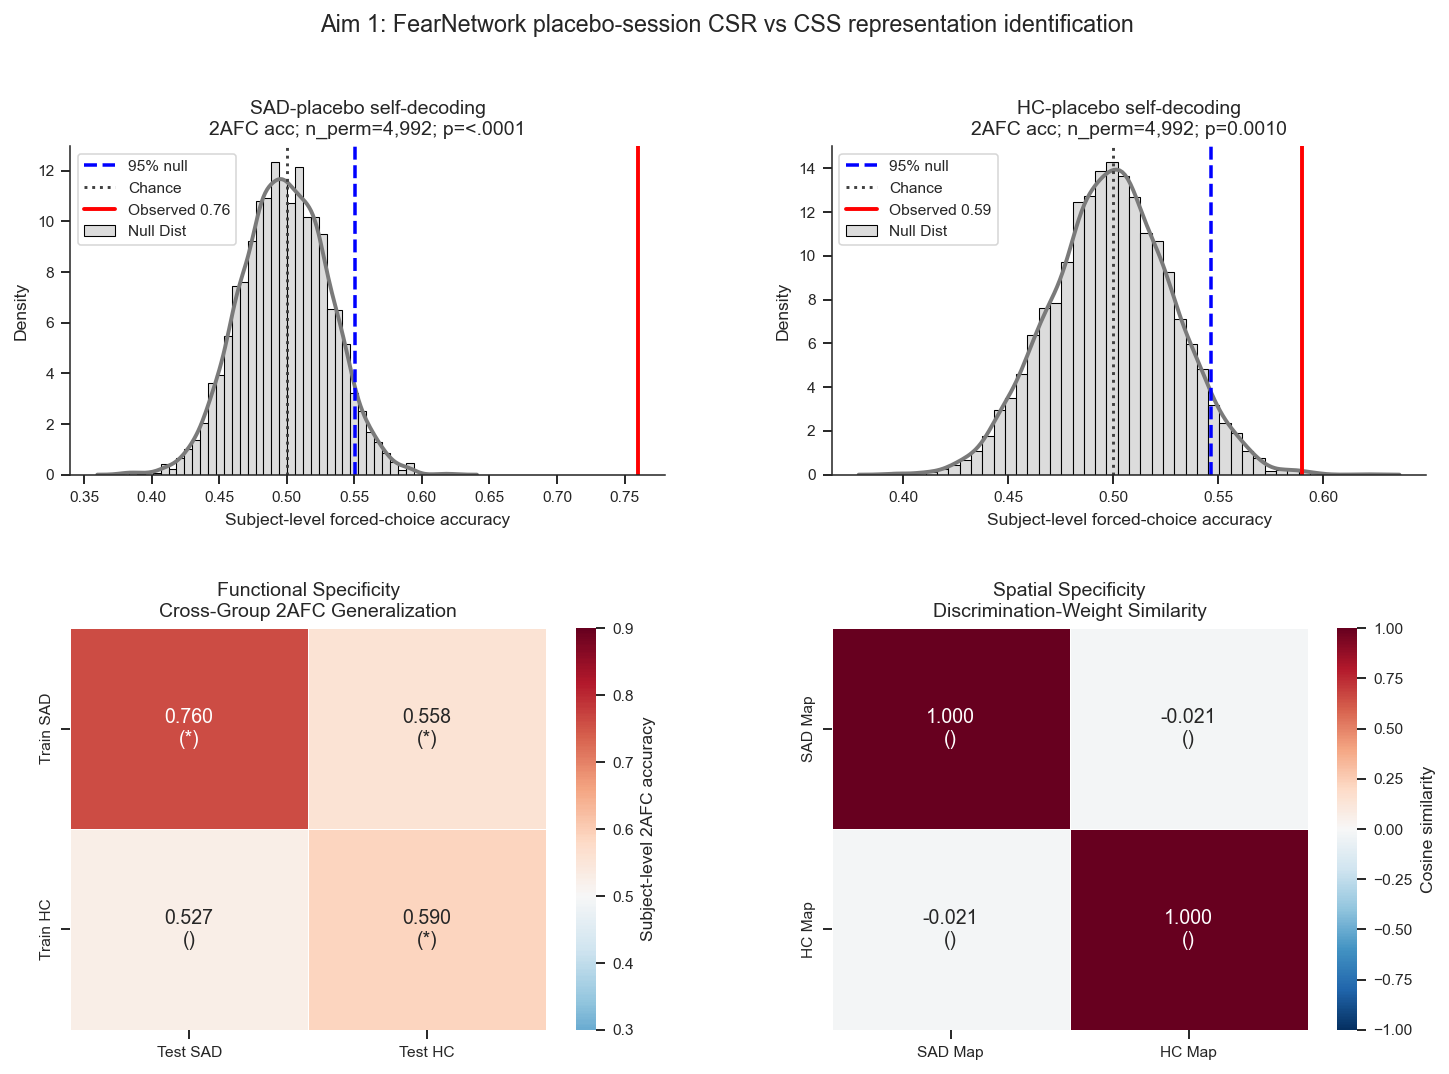

In [8]:
def payload_value(payload, *keys):
    if not isinstance(payload, dict):
        return None
    for key in keys:
        if key in payload:
            return payload[key]
    for value in payload.values():
        if isinstance(value, dict):
            found = payload_value(value, *keys)
            if found is not None:
                return found
    return None

def feature_space_dir(feature_space):
    candidates = [
        RESULTS_ROOT / feature_space,
        MVPA_ROOT / feature_space,
        Path('/output_dir') / feature_space,
        Path('/gscratch/scrubbed/fanglab/xiaoqian/NARSAD/LSS/results') / feature_space,
        Path('/Users/xiaoqianxiao/projects/NARSAD/LSS/results') / feature_space,
        Path('outputs/mvpa_l2') / feature_space,
    ]
    return next((path for path in candidates if path.exists()), candidates[0])

def warn_legacy_checkpoint(path, purpose='notebook display'):
    path = Path(path)
    if path.name in LEGACY_CHECKPOINT_NAMES:
        message = f'WARNING: using archived fallback checkpoint for {purpose}: {path}. Prefer current post-Hyak CSV/Markdown exports when available.'
        warnings.warn(message, RuntimeWarning)
        display(Markdown(f'**Legacy checkpoint fallback:** `{path}` is being used only because the current export was not available for this display.'))

def load_joblib(path, purpose='notebook display'):
    try:
        import joblib
    except ImportError:
        print('joblib is not installed in this kernel.')
        return None
    path = Path(path)
    if not path.exists():
        return None
    warn_legacy_checkpoint(path, purpose=purpose)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        return joblib.load(path)

def load_aim1_results(feature_space='FearNetwork'):
    if not aim1_primary_df.empty:
        display(Markdown('**Aim 1 current export available:** `aim1_decoding_primary.csv` is available; legacy checkpoints are not needed for the primary table.'))
    base = feature_space_dir(feature_space)
    paths = [
        base / 'intermediate' / 'stage06_decoding.joblib',
        base / 'intermediate' / 'stage06_aim1_decoding.joblib',
        base / 'checkpoints' / 'cell_06.joblib',
        base / 'cell_06.joblib',
    ]
    for path in paths:
        payload = load_joblib(path, purpose=f'Aim 1 {feature_space} plot reconstruction')
        if payload is None:
            continue
        result = payload_value(payload, 'results_11') or payload
        if isinstance(result, dict):
            return result, path
    return None, None


def aim1_placebo_filter(df):
    if df is None or df.empty:
        return pd.DataFrame()
    out = df.copy()
    for col in ['session', 'Drug', 'drug']:
        if col in out.columns:
            values = out[col].astype(str).str.lower()
            keep = values.eq('placebo') | values.eq('nan') | out[col].isna()
            out = out[keep].copy()
    return out

def infer_aim1_family(test_label):
    label = str(test_label).lower()
    if 'self-decoding' in label and 'model tested' not in label:
        return 'Primary'
    if 'generalization index' in label or 'model tested on' in label or 'haufe' in label or 'cosine similarity' in label or 'weight' in label:
        return 'Secondary'
    return 'Sensitivity'

def add_aim1_metadata(df):
    if df is None or df.empty:
        return pd.DataFrame()
    out = aim1_placebo_filter(df).copy()
    if 'family' not in out.columns:
        out['family'] = out.get('test', pd.Series(index=out.index, dtype=object)).map(infer_aim1_family)
    if 'session' not in out.columns:
        out['session'] = 'Placebo'
    if 'feature_space' not in out.columns and 'FeatureSpace' in out.columns:
        out['feature_space'] = out['FeatureSpace']
    if 'feature_space' not in out.columns:
        out['feature_space'] = 'FearNetwork'
    out['analysis_role'] = out['family'].map({'Primary': 'confirmatory', 'Secondary': 'secondary_specificity'}).fillna('sensitivity')
    labels = out.get('test', pd.Series(index=out.index, dtype=object)).astype(str).str.lower()
    out['specificity_domain'] = np.select(
        [labels.str.contains('self-decoding', na=False), labels.str.contains('model tested on|generalization index', na=False), labels.str.contains('haufe|cosine similarity|weight', na=False)],
        ['group_specific_identification', 'functional_specificity', 'spatial_specificity'],
        default='sensitivity_or_audit',
    )
    out['planned_permutations'] = AIM1_EXPECTED_PERMUTATIONS
    return out

def aim1_display_table(df, n=30):
    if df is None or df.empty:
        return pd.DataFrame()
    cols = select_columns(df, [
        'feature_space', 'session', 'analysis_role', 'specificity_domain', 'test', 'estimate', 'p_value', 'observed_permutations', 'planned_permutations', 'n_sad_subjects', 'n_hc_subjects', 'status', 'checkpoint'
    ])
    out = df[cols].copy() if cols else df.copy()
    return out.head(n)

def aim1_result_rows(result, feature_space='FearNetwork'):
    if not isinstance(result, dict):
        return pd.DataFrame()
    rows = []
    sad_perm = result.get('perm_dist_sad')
    hc_perm = result.get('perm_dist_hc')
    n_sad_perm = len(sad_perm) if sad_perm is not None else np.nan
    n_hc_perm = len(hc_perm) if hc_perm is not None else np.nan
    rows.append({'feature_space': feature_space, 'session': 'Placebo', 'test': 'SAD-placebo self-decoding', 'estimate': result.get('acc_sad_cv'), 'p_value': result.get('p_sad'), 'family': 'Primary', 'observed_permutations': n_sad_perm})
    rows.append({'feature_space': feature_space, 'session': 'Placebo', 'test': 'HC-placebo self-decoding', 'estimate': result.get('acc_hc_cv'), 'p_value': result.get('p_hc'), 'family': 'Primary', 'observed_permutations': n_hc_perm})
    func = result.get('func_matrix')
    pmat = result.get('p_func_pvals')
    cross_values = []
    if func is not None and pmat is not None:
        func = np.asarray(func)
        pmat = np.asarray(pmat)
        if func.shape == (2, 2) and pmat.shape == (2, 2):
            cross_values = [float(func[0, 1]), float(func[1, 0])]
            rows.append({'feature_space': feature_space, 'session': 'Placebo', 'test': 'SAD-placebo model tested on HC-placebo', 'estimate': cross_values[0], 'p_value': pmat[0, 1], 'family': 'Secondary'})
            rows.append({'feature_space': feature_space, 'session': 'Placebo', 'test': 'HC-placebo model tested on SAD-placebo', 'estimate': cross_values[1], 'p_value': pmat[1, 0], 'family': 'Secondary'})
    if cross_values:
        rows.append({'feature_space': feature_space, 'session': 'Placebo', 'test': 'Mean cross-group 2AFC generalization index', 'estimate': float(np.nanmean(cross_values)), 'p_value': np.nan, 'family': 'Secondary'})
    rows.append({'feature_space': feature_space, 'session': 'Placebo', 'test': 'SAD-placebo vs HC-placebo discrimination-weight cosine similarity', 'estimate': result.get('sim_spatial'), 'p_value': result.get('p_sim'), 'family': 'Secondary'})
    return add_aim1_metadata(pd.DataFrame(rows))

def format_p_value(p_value):
    if p_value is None or pd.isna(p_value):
        return 'NA'
    if p_value < 0.0001:
        return '<.0001'
    return f'{p_value:.4f}'

def plot_null_distribution(ax, null_values, observed, p_value, title):
    null_values = pd.to_numeric(pd.Series(null_values), errors='coerce').dropna().to_numpy()
    if len(null_values) == 0 or observed is None or pd.isna(observed):
        ax.text(0.5, 0.5, 'Subject-label permutation null missing', ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
        return
    threshold = np.percentile(null_values, 95)
    sns.histplot(null_values, bins=42, stat='density', color='0.82', edgecolor='black', linewidth=0.55, ax=ax, label='Null Dist')
    try:
        sns.kdeplot(null_values, color='0.48', linewidth=2.0, ax=ax)
    except Exception:
        pass
    ax.axvline(threshold, color='blue', linestyle='--', linewidth=1.8, label='95% null')
    ax.axvline(0.5, color='0.25', linestyle=':', linewidth=1.5, label='Chance')
    ax.axvline(observed, color='red', linewidth=2.0, label=f'Observed {observed:.2f}')
    ax.set_title(f'{title}\n2AFC acc; n_perm={len(null_values):,}; p={format_p_value(p_value)}')
    ax.set_xlabel('Subject-level forced-choice accuracy')
    ax.set_ylabel('Density')
    ax.legend(frameon=True, fontsize=8, loc='upper left')

def matrix_annotations(values, p_values=None, diagonal_only=False):
    values = np.asarray(values)
    annotations = np.empty(values.shape, dtype=object)
    for row in range(values.shape[0]):
        for col in range(values.shape[1]):
            star = ''
            if p_values is not None:
                p_val = p_values[row, col]
                if pd.notna(p_val) and p_val < 0.05:
                    star = '*'
            if diagonal_only and row != col:
                star = ''
            annotations[row, col] = f'{values[row, col]:.3f}\n({star})'
    return annotations

def plot_aim1(result, feature_space='FearNetwork', filename='aim1_decoding_summary'):
    if not isinstance(result, dict):
        print('Aim 1 checkpoint is not available yet.')
        return None
    fig = plt.figure(figsize=(12.5, 8.2))
    gs = fig.add_gridspec(2, 2, height_ratios=[0.9, 1.1], hspace=0.42, wspace=0.28)
    ax_sad = fig.add_subplot(gs[0, 0])
    ax_hc = fig.add_subplot(gs[0, 1])
    ax_func = fig.add_subplot(gs[1, 0])
    ax_spatial = fig.add_subplot(gs[1, 1])
    plot_null_distribution(ax_sad, result.get('perm_dist_sad'), result.get('acc_sad_cv'), result.get('p_sad'), 'SAD-placebo self-decoding')
    plot_null_distribution(ax_hc, result.get('perm_dist_hc'), result.get('acc_hc_cv'), result.get('p_hc'), 'HC-placebo self-decoding')
    func = result.get('func_matrix')
    pmat = result.get('p_func_pvals')
    if func is not None:
        func = np.asarray(func, dtype=float)
        pmat = np.asarray(pmat, dtype=float) if pmat is not None else None
        annotations = matrix_annotations(func, pmat)
        sns.heatmap(func, annot=annotations, fmt='', cmap='RdBu_r', center=0.5, vmin=0.3, vmax=0.9, cbar=True, cbar_kws={'label': 'Subject-level 2AFC accuracy'}, xticklabels=['Test SAD', 'Test HC'], yticklabels=['Train SAD', 'Train HC'], linewidths=0.5, linecolor='white', ax=ax_func)
        ax_func.set_title('Functional Specificity\nCross-Group 2AFC Generalization')
        ax_func.set_xlabel('')
        ax_func.set_ylabel('')
    else:
        ax_func.text(0.5, 0.5, 'Functional specificity matrix missing', ha='center', va='center', transform=ax_func.transAxes)
        ax_func.set_axis_off()
    sim = result.get('sim_spatial')
    if sim is not None and pd.notna(sim):
        spatial = np.array([[1.0, float(sim)], [float(sim), 1.0]])
        p_sim = result.get('p_sim')
        spatial_p = np.array([[np.nan, p_sim], [p_sim, np.nan]], dtype=float)
        annotations = matrix_annotations(spatial, spatial_p)
        sns.heatmap(spatial, annot=annotations, fmt='', cmap='RdBu_r', center=0, vmin=-1, vmax=1, cbar=True, cbar_kws={'label': 'Cosine similarity'}, xticklabels=['SAD Map', 'HC Map'], yticklabels=['SAD Map', 'HC Map'], linewidths=0.5, linecolor='white', ax=ax_spatial)
        ax_spatial.set_title('Spatial Specificity\nDiscrimination-Weight Similarity')
        ax_spatial.set_xlabel('')
        ax_spatial.set_ylabel('')
    else:
        ax_spatial.text(0.5, 0.5, 'Spatial specificity matrix missing', ha='center', va='center', transform=ax_spatial.transAxes)
        ax_spatial.set_axis_off()
    fig.suptitle(f'Aim 1: {feature_space} placebo-session CSR vs CSS representation identification', y=0.995, fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    save_figure(fig, filename)
    return fig

aim1_result, aim1_path = load_aim1_results('FearNetwork')
print(f'Aim 1 plot source: {aim1_path}')
aim1_rows = add_aim1_metadata(aim1_primary_df) if not aim1_primary_df.empty else aim1_result_rows(aim1_result, 'FearNetwork')
if aim1_rows.empty:
    print('Aim 1 result table is not available yet.')
else:
    display(Markdown('**Aim 1 PROJECT_CONTEXT alignment check:** cohort=SAD/HC Placebo; contrast=CSR vs CSS; metric=subject-level forced-choice accuracy; planned permutations=5,000; cross-group decoding and weight similarity are secondary.'))
    display(Markdown('**Primary decoding tests:** SAD-placebo and HC-placebo self-decoding against the subject-level forced-choice permutation null.'))
    display(aim1_display_table(aim1_rows[aim1_rows['family'].eq('Primary')], n=20))
    secondary_rows = aim1_rows[aim1_rows['family'].eq('Secondary')]
    if not secondary_rows.empty:
        display(Markdown('**Secondary specificity checks:** cross-group 2AFC generalization and SAD-HC discrimination-weight similarity within placebo-session subjects.'))
        display(aim1_display_table(secondary_rows, n=20))
show_figure_once(plot_aim1(aim1_result, 'FearNetwork'))


### Aim 1 Sensitivity: Participant Subgroups And Alternative Masks

Aim 1 sensitivity follows the placebo-focused logic in `PROJECT_CONTEXT.md`. SCR-defined responder/learner cohorts are sensitivity populations, not replacement primary cohorts, and they should duplicate the Aim 1 placebo-session analysis logic without splitting by drug unless sample size supports that future extension.

Mask/feature-space sensitivity repeats the same `CSR` versus `CSS` decoding summary for available alternative masks or feature spaces, currently including FearNetwork and MemoryFearNetwork when cached outputs exist. Self-decoding subject-level forced-choice accuracy is the key sensitivity readout; cross-group decoding/generalization and Haufe or discrimination-weight similarity remain secondary specificity checks.


**Participant-subgroup sensitivity: SCR-defined placebo cohorts.** Each row is one SCR responder/learner cohort. The heatmap applies the full placebo-session SAD and HC decoders to each SCR-defined subgroup, including full-model self-application and cross-group application. Full-model self-application is apparent hold-in accuracy because those participants contributed to the full training set; it is useful as a descriptive sensitivity check, not subgroup cross-validation. The wide table also retains subgroup-trained self/cross decoding for auditability.

Wrote Aim 1 SCR-subgroup wide sensitivity table: /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/aim1_scr_subgroup_sensitivity_wide.csv


,feature_space,session,include_subjects_flag,n_sad_subjects,n_hc_subjects
0,FearNetwork,Placebo,SCR_Habituation_Adjusted_Learner,7,9
1,FearNetwork,Placebo,SCR_Late_Phase_Sensitivity_Learner,4,4
2,FearNetwork,Placebo,SCR_Physiological_Responder,13,18
3,FearNetwork,Placebo,SCR_Simple_Acquisition_Differential_Learner,8,12


Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim1_scr_subgroup_decoding_matrix.png
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim1_scr_subgroup_decoding_matrix.pdf


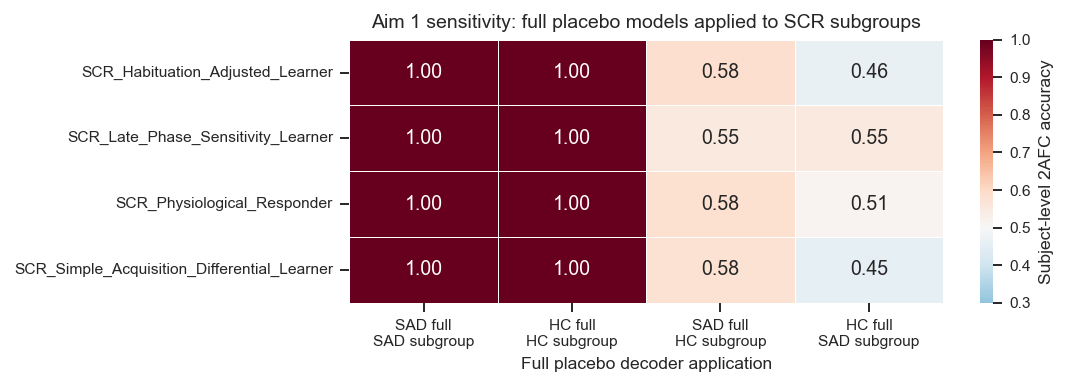

Long-format subgroup table retained for audit trail, including subgroup-trained checks and secondary specificity checks.

,feature_space,session,analysis_role,specificity_domain,test,estimate,p_value,planned_permutations,n_sad_subjects,n_hc_subjects
0,FearNetwork,Placebo,confirmatory,group_specific_identification,SAD-placebo self-decoding CV accuracy,0.700000,0.000000,5000,7,9
1,FearNetwork,Placebo,confirmatory,group_specific_identification,HC-placebo self-decoding CV accuracy,0.700000,0.000000,5000,7,9
2,FearNetwork,Placebo,secondary_specificity,functional_specificity,SAD-placebo model tested on HC-placebo,0.527778,0.310484,5000,7,9
3,FearNetwork,Placebo,secondary_specificity,functional_specificity,HC-placebo model tested on SAD-placebo,0.517857,0.428427,5000,7,9
4,FearNetwork,Placebo,secondary_specificity,spatial_specificity,SAD-placebo vs HC-placebo Haufe map cosine sim...,-0.146532,0.366000,5000,7,9
5,FearNetwork,Placebo,confirmatory,group_specific_identification,SAD-placebo self-decoding CV accuracy,0.500000,0.436492,5000,4,4
6,FearNetwork,Placebo,confirmatory,group_specific_identification,HC-placebo self-decoding CV accuracy,0.750000,0.000000,5000,4,4
7,FearNetwork,Placebo,secondary_specificity,functional_specificity,SAD-placebo model tested on HC-placebo,0.515625,0.511089,5000,4,4
8,FearNetwork,Placebo,secondary_specificity,functional_specificity,HC-placebo model tested on SAD-placebo,0.562500,0.228831,5000,4,4
9,FearNetwork,Placebo,secondary_specificity,spatial_specificity,SAD-placebo vs HC-placebo Haufe map cosine sim...,-0.059935,0.358000,5000,4,4


/var/folders/63/3j_hstl96w58qx1sdw9czhxr0000gn/T/ipykernel_93400/2791983437.py:29: RuntimeWarning: WARNING: using archived fallback checkpoint for Aim 1 FearNetwork plot reconstruction: /Users/xiaoqianxiao/projects/NARSAD/LSS/results/FearNetwork/checkpoints/cell_06.joblib. Prefer current post-Hyak CSV/Markdown exports when available.
  warnings.warn(message, RuntimeWarning)


**Legacy checkpoint fallback:** `/Users/xiaoqianxiao/projects/NARSAD/LSS/results/FearNetwork/checkpoints/cell_06.joblib` is being used only because the current export was not available for this display.

/var/folders/63/3j_hstl96w58qx1sdw9czhxr0000gn/T/ipykernel_93400/2791983437.py:29: RuntimeWarning: WARNING: using archived fallback checkpoint for Aim 1 MemoryFearNetwork plot reconstruction: /Users/xiaoqianxiao/projects/NARSAD/LSS/results/MemoryFearNetwork/checkpoints/cell_06.joblib. Prefer current post-Hyak CSV/Markdown exports when available.
  warnings.warn(message, RuntimeWarning)


...

Wrote Aim 1 mask/feature-space long table: /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/aim1_mask_feature_sensitivity.csv


**Mask/feature-space sensitivity.** Each row is one available mask or feature space. Whole-brain/Schaefer rows are retained as missing when not available in the current no-wholebrain workflow.

Wrote Aim 1 mask/feature-space wide sensitivity table: /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/aim1_mask_feature_sensitivity_wide.csv


,feature_space,session,status
0,FearNetwork,Placebo,ok
1,MemoryFearNetwork,Placebo,ok


Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim1_mask_feature_decoding_matrix.png
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim1_mask_feature_decoding_matrix.pdf


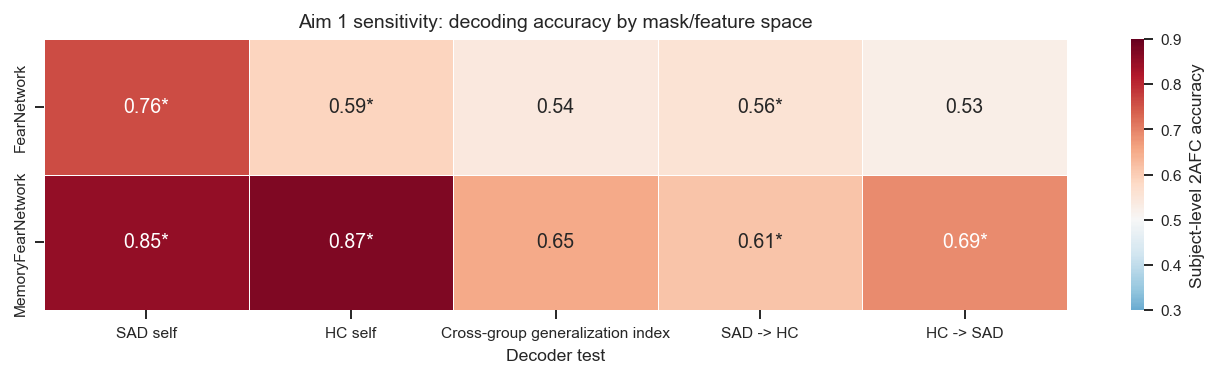

Long-format mask/feature-space table retained for audit trail, including secondary specificity checks.

,feature_space,session,analysis_role,specificity_domain,test,estimate,p_value,observed_permutations,planned_permutations,status,checkpoint
0,FearNetwork,Placebo,sensitivity,group_specific_identification,SAD-placebo self-decoding,0.760000,0.000000,4992.0,5000,ok,/Users/xiaoqianxiao/projects/NARSAD/LSS/result...
1,FearNetwork,Placebo,sensitivity,group_specific_identification,HC-placebo self-decoding,0.590000,0.001002,4992.0,5000,ok,/Users/xiaoqianxiao/projects/NARSAD/LSS/result...
2,FearNetwork,Placebo,sensitivity,functional_specificity,SAD-placebo model tested on HC-placebo,0.558036,0.010817,NaN,5000,ok,/Users/xiaoqianxiao/projects/NARSAD/LSS/result...
3,FearNetwork,Placebo,sensitivity,functional_specificity,HC-placebo model tested on SAD-placebo,0.527174,0.167668,NaN,5000,ok,/Users/xiaoqianxiao/projects/NARSAD/LSS/result...
4,FearNetwork,Placebo,sensitivity,functional_specificity,Mean cross-group 2AFC generalization index,0.542605,NaN,NaN,5000,ok,/Users/xiaoqianxiao/projects/NARSAD/LSS/result...
5,FearNetwork,Placebo,sensitivity,spatial_specificity,SAD-placebo vs HC-placebo discrimination-weigh...,-0.020565,0.530000,NaN,5000,ok,/Users/xiaoqianxiao/projects/NARSAD/LSS/result...
6,MemoryFearNetwork,Placebo,sensitivity,group_specific_identification,SAD-placebo self-decoding,0.850000,0.000000,4992.0,5000,ok,/Users/xiaoqianxiao/projects/NARSAD/LSS/result...
7,MemoryFearNetwork,Placebo,sensitivity,group_specific_identification,HC-placebo self-decoding,0.873333,0.000000,4992.0,5000,ok,/Users/xiaoqianxiao/projects/NARSAD/LSS/result...
8,MemoryFearNetwork,Placebo,sensitivity,functional_specificity,SAD-placebo model tested on HC-placebo,0.613839,0.000000,NaN,5000,ok,/Users/xiaoqianxiao/projects/NARSAD/LSS/result...
9,MemoryFearNetwork,Placebo,sensitivity,functional_specificity,HC-placebo model tested on SAD-placebo,0.687500,0.000000,NaN,5000,ok,/Users/xiaoqianxiao/projects/NARSAD/LSS/result...


In [9]:
def aim1_self_decoding_rows(df):
    if df is None or df.empty or 'test' not in df.columns:
        return pd.DataFrame()
    df = aim1_placebo_filter(df)
    labels = df['test'].astype(str)
    return df[labels.str.contains('self-decoding', case=False, na=False) & ~labels.str.contains('model tested', case=False, na=False)].copy()

def aim1_cross_decoding_rows(df):
    if df is None or df.empty or 'test' not in df.columns:
        return pd.DataFrame()
    df = aim1_placebo_filter(df)
    labels = df['test'].astype(str)
    out = df[labels.str.contains('model tested on', case=False, na=False)].copy()
    if not out.empty:
        out['direction'] = out['test'].astype(str).str.replace('-placebo model tested on ', ' -> ', regex=False).str.replace('-placebo', '', regex=False)
    return out

def classify_aim1_test(test_label):
    label = str(test_label)
    if 'Full SAD-placebo model tested on SAD-placebo SCR subgroup' in label:
        return 'Full SAD model on SAD subgroup'
    if 'Full HC-placebo model tested on HC-placebo SCR subgroup' in label:
        return 'Full HC model on HC subgroup'
    if 'Full SAD-placebo model tested on HC-placebo SCR subgroup' in label:
        return 'Full SAD model on HC subgroup'
    if 'Full HC-placebo model tested on SAD-placebo SCR subgroup' in label:
        return 'Full HC model on SAD subgroup'
    if 'SAD-placebo self-decoding' in label:
        return 'SAD self'
    if 'HC-placebo self-decoding' in label:
        return 'HC self'
    if 'SAD-placebo model tested on HC-placebo' in label:
        return 'SAD -> HC'
    if 'HC-placebo model tested on SAD-placebo' in label:
        return 'HC -> SAD'
    if 'generalization index' in label:
        return 'Cross-group generalization index'
    if 'Haufe' in label or 'cosine similarity' in label or 'weight similarity' in label:
        return 'Weight similarity'
    return None

def available_aim1_feature_spaces():
    candidates = []
    if not metrics_df.empty and 'FeatureSpace' in metrics_df.columns:
        candidates.extend(metrics_df['FeatureSpace'].dropna().astype(str).unique().tolist())
    candidates.extend(['FearNetwork', 'MemoryFearNetwork', 'WholeBrain_Schaefer', 'WholeBrain', 'Schaefer'])
    seen = []
    for fs in candidates:
        if fs not in seen:
            seen.append(fs)
    return seen

def aim1_feature_space_sensitivity_table():
    rows = []
    for feature_space in available_aim1_feature_spaces():
        result, path = load_aim1_results(feature_space)
        if not isinstance(result, dict):
            rows.append({
                'feature_space': feature_space,
                'session': 'Placebo',
                'mask_or_feature_space': feature_space,
                'test': 'Aim 1 checkpoint missing',
                'estimate': np.nan,
                'p_value': np.nan,
                'family': 'Sensitivity',
                'checkpoint': str(path) if path is not None else 'missing',
                'status': 'missing',
            })
            continue
        table = aim1_result_rows(result, feature_space)
        if table.empty:
            continue
        table = table.copy()
        table['mask_or_feature_space'] = feature_space
        table['checkpoint'] = str(path)
        table['status'] = 'ok'
        table['family'] = np.where(table['family'].eq('Primary'), 'Sensitivity: self-decoding', 'Sensitivity: specificity')
        rows.extend(table.to_dict('records'))
    out = add_aim1_metadata(pd.DataFrame(rows))
    if not out.empty:
        out_path = STATS_DIR / 'aim1_mask_feature_sensitivity.csv'
        out.to_csv(out_path, index=False)
        print(f'Wrote Aim 1 mask/feature-space long table: {out_path}')
    return out

def aim1_wide_decoding_summary(df, unit_col):
    if df is None or df.empty or unit_col not in df.columns or 'test' not in df.columns:
        return pd.DataFrame()
    temp = add_aim1_metadata(df)
    temp['test_family'] = temp['test'].map(classify_aim1_test)
    temp = temp[temp['test_family'].notna()].copy()
    temp['estimate'] = pd.to_numeric(temp['estimate'], errors='coerce')
    temp['p_value'] = pd.to_numeric(temp.get('p_value', pd.Series(index=temp.index, dtype=float)), errors='coerce')
    units = pd.DataFrame({unit_col: sorted(temp[unit_col].dropna().astype(str).unique().tolist())})
    temp[unit_col] = temp[unit_col].astype(str)
    est = temp.pivot_table(index=unit_col, columns='test_family', values='estimate', aggfunc='first')
    pval = temp.pivot_table(index=unit_col, columns='test_family', values='p_value', aggfunc='first')
    wide = units.set_index(unit_col).join(est).reset_index()
    for col in ['SAD self', 'HC self', 'SAD -> HC', 'HC -> SAD', 'Cross-group generalization index', 'Full SAD model on SAD subgroup', 'Full HC model on HC subgroup', 'Full SAD model on HC subgroup', 'Full HC model on SAD subgroup', 'Weight similarity']:
        if col not in wide.columns:
            wide[col] = np.nan
    for col in ['SAD self', 'HC self', 'SAD -> HC', 'HC -> SAD', 'Cross-group generalization index', 'Full SAD model on SAD subgroup', 'Full HC model on HC subgroup', 'Full SAD model on HC subgroup', 'Full HC model on SAD subgroup', 'Weight similarity']:
        p_name = f'{col} p'
        wide[p_name] = pval[col].reindex(wide[unit_col]).to_numpy() if col in pval.columns else np.nan
    for col in ['feature_space', 'session', 'n_sad_subjects', 'n_hc_subjects', 'status']:
        if col in temp.columns:
            meta = temp.groupby(unit_col, dropna=False)[col].first()
            wide[col] = wide[unit_col].map(meta)
    if 'Cross-group generalization index' in wide.columns and wide['Cross-group generalization index'].isna().all():
        wide['Cross-group generalization index'] = wide[['SAD -> HC', 'HC -> SAD']].mean(axis=1, skipna=True)
    ordered = [unit_col, 'feature_space', 'session', 'n_sad_subjects', 'n_hc_subjects', 'status', 'SAD self', 'SAD self p', 'HC self', 'HC self p', 'Cross-group generalization index', 'SAD -> HC', 'SAD -> HC p', 'HC -> SAD', 'HC -> SAD p', 'Full SAD model on SAD subgroup', 'Full HC model on HC subgroup', 'Full SAD model on HC subgroup', 'Full HC model on SAD subgroup', 'Weight similarity', 'Weight similarity p']
    return wide[[c for c in ordered if c in wide.columns]]

def plot_aim1_decoding_matrix(wide, unit_col, title, filename, xlabel, metrics=None, xlabels=None, show_nominal_stars=True, vmin=0.3, vmax=0.9):
    if wide is None or wide.empty or unit_col not in wide.columns:
        print(f'No Aim 1 decoding matrix available for {title}.')
        return None
    if metrics is None:
        metrics = ['SAD self', 'HC self', 'Cross-group generalization index', 'SAD -> HC', 'HC -> SAD']
    available_metrics = [m for m in metrics if m in wide.columns]
    plot_df = wide[[unit_col] + available_metrics].copy()
    if len(plot_df.columns) <= 1:
        print(f'No decoding accuracy columns available for {title}.')
        return None
    plot_df = plot_df.set_index(unit_col)
    plot_df = plot_df.apply(pd.to_numeric, errors='coerce')
    plot_df = plot_df.dropna(how='all')
    if plot_df.empty:
        print(f'No finite decoding accuracy estimates available for {title}.')
        return None
    annot = plot_df.copy().astype(object)
    for idx in plot_df.index:
        for col in plot_df.columns:
            value = plot_df.loc[idx, col]
            p_col = f'{col} p'
            p_val = pd.to_numeric(wide.loc[wide[unit_col].astype(str).eq(str(idx)), p_col], errors='coerce').iloc[0] if p_col in wide.columns and wide[unit_col].astype(str).eq(str(idx)).any() else np.nan
            star = '*' if show_nominal_stars and pd.notna(p_val) and p_val < 0.05 else ''
            annot.loc[idx, col] = '' if pd.isna(value) else f'{value:.2f}{star}'
    if xlabels is not None:
        label_map = {metric: label for metric, label in zip(metrics, xlabels)}
        plot_df = plot_df.rename(columns=label_map)
        annot = annot.rename(columns=label_map)
    fig_width = max(6.2, 1.65 * len(plot_df.columns) + 1.4)
    fig_height = max(2.8, 0.34 * len(plot_df) + 1.5)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    sns.heatmap(plot_df, annot=annot, fmt='', cmap='RdBu_r', center=0.5, vmin=vmin, vmax=vmax, linewidths=0.4, linecolor='white', cbar_kws={'label': 'Subject-level 2AFC accuracy'}, ax=ax)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('')
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=0)
    fig.tight_layout()
    save_figure(fig, filename)
    return fig

def save_and_display_aim1_wide(wide, name, label):
    if wide.empty:
        print(f'No {label} wide sensitivity table available.')
        return
    out_path = STATS_DIR / f'{name}.csv'
    wide.to_csv(out_path, index=False)
    print(f'Wrote {label} wide sensitivity table: {out_path}')
    display(tidy_result_table(wide, n=120))

# 1. Participant subgroup sensitivity.
aim1_scr_placebo_df = aim1_placebo_filter(aim1_scr_df)
if aim1_scr_df is not None and not aim1_scr_df.empty and len(aim1_scr_placebo_df) < len(aim1_scr_df):
    print(f'Filtered Aim 1 SCR sensitivity rows to placebo-session scope: {len(aim1_scr_placebo_df)} of {len(aim1_scr_df)} rows retained.')
if aim1_scr_placebo_df.empty:
    print('No Aim 1 SCR subgroup decoding summary found yet. Run scripts/export_aim1_scr_sensitivity.py after subgroup Stage 6 jobs finish.')
else:
    display(Markdown('**Participant-subgroup sensitivity: SCR-defined placebo cohorts.** Each row is one SCR responder/learner cohort. The heatmap applies the full placebo-session SAD and HC decoders to each SCR-defined subgroup, including full-model self-application and cross-group application. Full-model self-application is apparent hold-in accuracy because those participants contributed to the full training set; it is useful as a descriptive sensitivity check, not subgroup cross-validation. The wide table also retains subgroup-trained self/cross decoding for auditability.'))
    subgroup_wide = aim1_wide_decoding_summary(aim1_scr_placebo_df, 'include_subjects_flag')
    save_and_display_aim1_wide(subgroup_wide, 'aim1_scr_subgroup_sensitivity_wide', 'Aim 1 SCR-subgroup')
    full_model_metrics = ['Full SAD model on SAD subgroup', 'Full HC model on HC subgroup', 'Full SAD model on HC subgroup', 'Full HC model on SAD subgroup']
    full_model_labels = ['SAD full\nSAD subgroup', 'HC full\nHC subgroup', 'SAD full\nHC subgroup', 'HC full\nSAD subgroup']
    show_figure_once(plot_aim1_decoding_matrix(subgroup_wide, 'include_subjects_flag', 'Aim 1 sensitivity: full placebo models applied to SCR subgroups', 'aim1_scr_subgroup_decoding_matrix', xlabel='Full placebo decoder application', metrics=full_model_metrics, xlabels=full_model_labels, show_nominal_stars=False, vmax=1.0))
    display(Markdown('Long-format subgroup table retained for audit trail, including subgroup-trained checks and secondary specificity checks.'))
    display(aim1_display_table(add_aim1_metadata(aim1_scr_placebo_df), n=120))

# 2. Alternative mask / feature-space sensitivity.
aim1_mask_df = aim1_feature_space_sensitivity_table()
if aim1_mask_df.empty:
    print('No Aim 1 alternative mask/feature-space decoding summaries found yet.')
else:
    display(Markdown('**Mask/feature-space sensitivity.** Each row is one available mask or feature space. Whole-brain/Schaefer rows are retained as missing when not available in the current no-wholebrain workflow.'))
    mask_wide = aim1_wide_decoding_summary(aim1_mask_df, 'mask_or_feature_space')
    save_and_display_aim1_wide(mask_wide, 'aim1_mask_feature_sensitivity_wide', 'Aim 1 mask/feature-space')
    show_figure_once(plot_aim1_decoding_matrix(mask_wide, 'mask_or_feature_space', 'Aim 1 sensitivity: decoding accuracy by mask/feature space', 'aim1_mask_feature_decoding_matrix', xlabel='Decoder test'))
    display(Markdown('Long-format mask/feature-space table retained for audit trail, including secondary specificity checks.'))
    display(aim1_display_table(aim1_mask_df, n=120))


## Aim 2: SAD-HC Neural Profile Difference Under Placebo

Primary tests first: placebo-session SAD-HC models are organized by the three questions in `PROJECT_CONTEXT.md`. Within each question, p-values are FDR-corrected across the primary metrics that answer that question. Secondary readouts are labeled support/contextual only and are used for specificity and mechanism, not for primary claims.


**Aim 2 primary neural metric tests:** the same six primary metrics used in Aims 3-5, FDR-corrected within each planned Aim 2 question. Planned metrics missing from the current export are shown with status `metric_missing_from_current_export`.

,analysis,feature_space,metric,metric_role,term,estimate,ci_low,ci_high,p,q,q_within_question,n,r2,status,formula
4,Aim2_SAD_HC_Placebo,FearNetwork,Neural_Safety_Trajectory_Slope,primary,"C(Group, Treatment(reference='HC'))[T.SAD]",0.062737,0.019209,0.106265,0.005665,0.011331,0.011331,51,0.227211,ok,"Q('Neural_Safety_Trajectory_Slope') ~ C(Group,..."
5,Aim2_SAD_HC_Placebo,FearNetwork,Neural_Threat_Trajectory_Slope,primary,"C(Group, Treatment(reference='HC'))[T.SAD]",-0.083970,-0.170382,0.002441,0.056550,0.056550,0.056550,50,0.110070,ok,"Q('Neural_Threat_Trajectory_Slope') ~ C(Group,..."
0,Aim2_SAD_HC_Placebo,FearNetwork,Neural_Dist_Safety_Background,primary,"C(Group, Treatment(reference='HC'))[T.SAD]",0.035856,-0.005085,0.076798,0.084592,0.169184,0.169184,51,0.129647,ok,"Q('Neural_Dist_Safety_Background') ~ C(Group, ..."
1,Aim2_SAD_HC_Placebo,FearNetwork,Neural_Dist_Threat_Safety,primary,"C(Group, Treatment(reference='HC'))[T.SAD]",0.044400,-0.027403,0.116202,0.219682,0.219682,0.219682,51,0.034886,ok,"Q('Neural_Dist_Threat_Safety') ~ C(Group, Trea..."
2,Aim2_SAD_HC_Placebo,FearNetwork,Neural_Decision_Margin_CSS,primary,"C(Group, Treatment(reference='HC'))[T.SAD]",0.002223,-0.020569,0.025016,0.845270,0.845270,0.845270,51,0.042924,ok,"Q('Neural_Decision_Margin_CSS') ~ C(Group, Tre..."
7,Aim2_SAD_HC_Placebo,FearNetwork,Neural_Decision_Margin_CSR,primary,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,metric_missing_from_current_export,NaN


### Primary rows for Q1_geometry: Where are safety and threat in neural space?

,analysis,feature_space,metric,metric_role,term,estimate,ci_low,ci_high,p,q,q_within_question,n,r2,status,formula
0,Aim2_SAD_HC_Placebo,FearNetwork,Neural_Dist_Safety_Background,primary,"C(Group, Treatment(reference='HC'))[T.SAD]",0.035856,-0.005085,0.076798,0.084592,0.169184,0.169184,51,0.129647,ok,"Q('Neural_Dist_Safety_Background') ~ C(Group, ..."
1,Aim2_SAD_HC_Placebo,FearNetwork,Neural_Dist_Threat_Safety,primary,"C(Group, Treatment(reference='HC'))[T.SAD]",0.044400,-0.027403,0.116202,0.219682,0.219682,0.219682,51,0.034886,ok,"Q('Neural_Dist_Threat_Safety') ~ C(Group, Trea..."


### Primary rows for Q2_decision_certainty: Are safety and threat cues represented decisively or ambiguously?

,analysis,feature_space,metric,metric_role,term,estimate,ci_low,ci_high,p,q,q_within_question,n,r2,status,formula
2,Aim2_SAD_HC_Placebo,FearNetwork,Neural_Decision_Margin_CSS,primary,"C(Group, Treatment(reference='HC'))[T.SAD]",0.002223,-0.020569,0.025016,0.84527,0.84527,0.84527,51,0.042924,ok,"Q('Neural_Decision_Margin_CSS') ~ C(Group, Tre..."
7,Aim2_SAD_HC_Placebo,FearNetwork,Neural_Decision_Margin_CSR,primary,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,metric_missing_from_current_export,NaN


### Primary rows for Q3_learning_dynamics: How do safety and threat representations change over learning?

,analysis,feature_space,metric,metric_role,term,estimate,ci_low,ci_high,p,q,q_within_question,n,r2,status,formula
4,Aim2_SAD_HC_Placebo,FearNetwork,Neural_Safety_Trajectory_Slope,primary,"C(Group, Treatment(reference='HC'))[T.SAD]",0.062737,0.019209,0.106265,0.005665,0.011331,0.011331,51,0.227211,ok,"Q('Neural_Safety_Trajectory_Slope') ~ C(Group,..."
5,Aim2_SAD_HC_Placebo,FearNetwork,Neural_Threat_Trajectory_Slope,primary,"C(Group, Treatment(reference='HC'))[T.SAD]",-0.083970,-0.170382,0.002441,0.056550,0.056550,0.056550,50,0.110070,ok,"Q('Neural_Threat_Trajectory_Slope') ~ C(Group,..."


Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim2_all_questions_forest.png
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim2_all_questions_forest.pdf


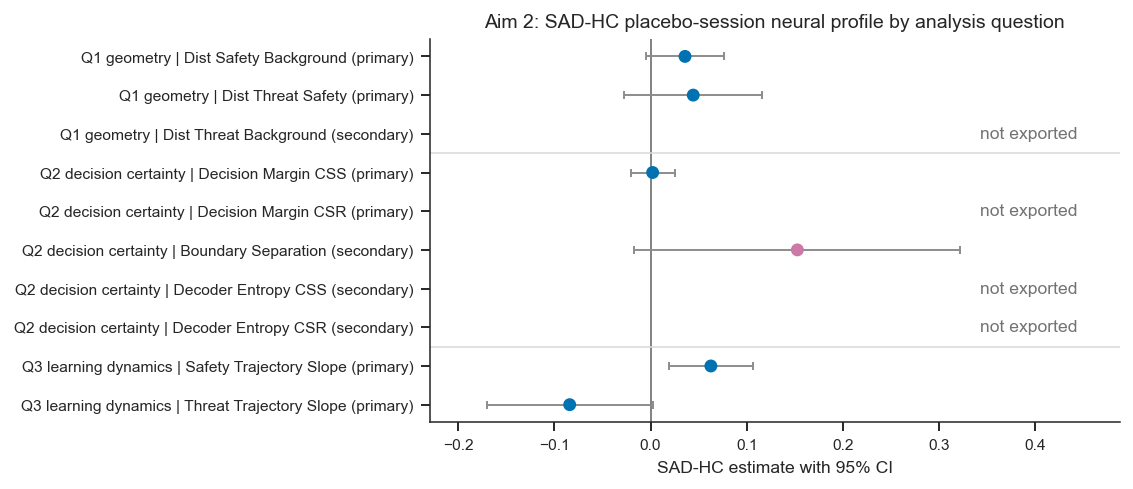

In [10]:
aim2_by_question_df = prepare_aim2_questions(aim2_df)
aim2_primary_df = aim2_by_question_df[aim2_by_question_df.get('metric_role', pd.Series(index=aim2_by_question_df.index, dtype=str)).eq('primary')].copy() if not aim2_by_question_df.empty else pd.DataFrame()
aim2_secondary_df = aim2_by_question_df[aim2_by_question_df.get('metric_role', pd.Series(index=aim2_by_question_df.index, dtype=str)).eq('secondary')].copy() if not aim2_by_question_df.empty else pd.DataFrame()

if aim2_primary_df.empty:
    print('Aim 2 primary model table is not available yet.')
else:
    display(Markdown('**Aim 2 primary neural metric tests:** the same six primary metrics used in Aims 3-5, FDR-corrected within each planned Aim 2 question. Planned metrics missing from the current export are shown with status `metric_missing_from_current_export`.'))
    display(tidy_result_table(aim2_primary_df, n=80))
    for question in AIM2_QUESTION_METRICS:
        question_df = aim2_primary_df[aim2_primary_df['aim2_question'].eq(question)].copy()
        if question_df.empty:
            continue
        label = AIM2_QUESTION_LABELS[question]
        display(Markdown(f'### Primary rows for {question}: {label}'))
        display(tidy_result_table(question_df, n=30))
if not aim2_by_question_df.empty:
    show_figure_once(plot_aim2_question_forest(
        aim2_by_question_df,
        title='Aim 2: SAD-HC placebo-session neural profile by analysis question',
        filename='aim2_all_questions_forest',
    ))


### Aim 2 Primary, Question 3: Learning Dynamics

Trajectory plots provide the primary dynamic readout: whether `CSS` patterns move toward the `CS-` safety reference and whether `CSR` patterns persist toward reinstated `CSR`. The shock/US target is not part of the primary dynamics figure and is shown separately as a secondary threat-anchor analysis when available.


Trajectory checkpoint: /Users/xiaoqianxiao/projects/NARSAD/LSS/results/FearNetwork/intermediate/stage14_trajectories.joblib
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim2_primary_learning_dynamics.png
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim2_primary_learning_dynamics.pdf


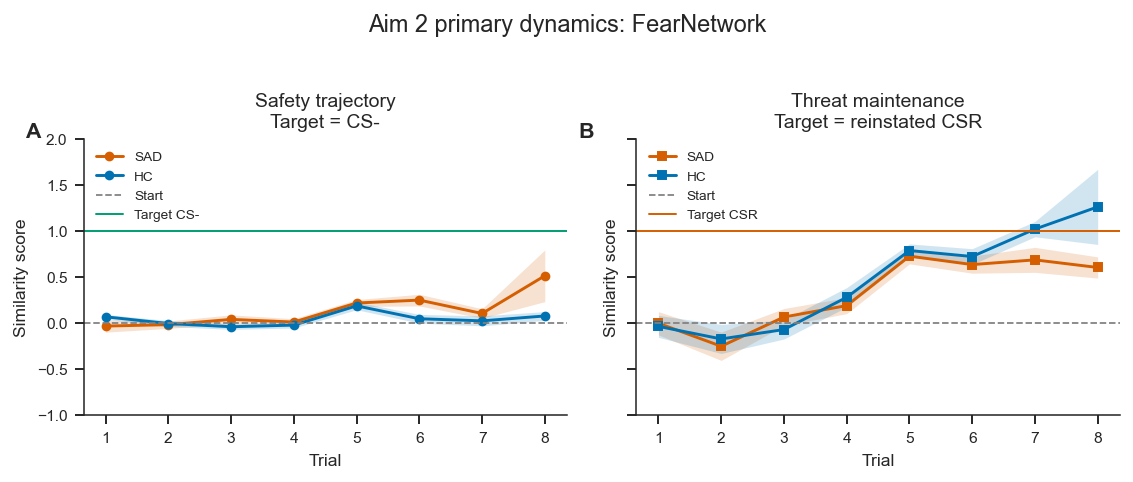

In [11]:
def find_trajectory_payload(feature_space='FearNetwork'):
    base = feature_space_dir(feature_space)
    paths = [
        base / 'intermediate' / 'stage14_trajectories.joblib',
        base / 'checkpoints' / 'cell_14.joblib',
        base / 'checkpoints' / 'cell_12_trajectories.joblib',
        base / 'cell_14.joblib',
    ]
    for path in paths:
        payload = load_joblib(path, purpose=f'Aim 2 trajectory display for {feature_space}')
        if payload is None:
            continue
        results = payload_value(payload, 'results_13_2') or payload
        if isinstance(results, dict):
            return results, path
    return None, None

def summarize_trajectory(df):
    if df is None or df.empty:
        return pd.DataFrame()
    trial_col = next((c for c in ['trial', 'Trial', 'block', 'Block'] if c in df.columns), None)
    score_col = next((c for c in ['score', 'Score', 'similarity', 'Similarity'] if c in df.columns), None)
    group_col = next((c for c in ['Group', 'group'] if c in df.columns), None)
    if trial_col is None or score_col is None or group_col is None:
        print(f'Trajectory dataframe columns are not recognized: {list(df.columns)}')
        return pd.DataFrame()
    sub = df.copy()
    sub['trial'] = pd.to_numeric(sub[trial_col], errors='coerce')
    sub['score'] = pd.to_numeric(sub[score_col], errors='coerce')
    sub['Group'] = sub[group_col].astype(str)
    sub = sub.dropna(subset=['trial', 'score'])
    out = sub.groupby(['Group', 'trial'], dropna=False)['score'].agg(['mean', 'sem', 'count']).reset_index()
    out['sem'] = out['sem'].fillna(0)
    return out

def annotate_trial_p(ax, stats_df, y=1.65):
    if stats_df is None or stats_df.empty:
        return
    trial_col = next((c for c in ['trial', 'Trial', 'block', 'Block'] if c in stats_df.columns), None)
    p_col = next((c for c in ['p', 'p_value', 'pval', 'P', 'p_group'] if c in stats_df.columns), None)
    if trial_col is None or p_col is None:
        return
    temp = stats_df.copy()
    temp[trial_col] = pd.to_numeric(temp[trial_col], errors='coerce')
    temp[p_col] = pd.to_numeric(temp[p_col], errors='coerce')
    temp = temp.dropna(subset=[trial_col, p_col])
    for _, row in temp.iterrows():
        if row[p_col] < 0.05:
            ax.text(row[trial_col], y, f'p={row[p_col]:.2g}', ha='center', va='bottom', fontsize=7)
            ax.plot([row[trial_col] - 0.15, row[trial_col] + 0.15], [y - 0.03, y - 0.03], color='black', linewidth=0.8)

def plot_trajectory_axis(ax, df, stats_df, title, target_label, target_color, marker, panel_label):
    summary = summarize_trajectory(df)
    add_panel_label(ax, panel_label)
    if summary.empty:
        ax.text(0.5, 0.5, 'Trajectory data missing', ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
        return
    for group in ['SAD', 'HC']:
        sub = summary[summary['Group'].eq(group)]
        if sub.empty:
            continue
        color = GROUP_COLORS.get(group, '0.3')
        ax.plot(sub['trial'], sub['mean'], marker=marker, color=color, linewidth=1.5, markersize=4, label=group)
        ax.fill_between(sub['trial'], sub['mean'] - sub['sem'], sub['mean'] + sub['sem'], color=color, alpha=0.18, linewidth=0)
    ax.axhline(0, color='0.5', linestyle='--', linewidth=0.9, label='Start')
    ax.axhline(1, color=target_color, linewidth=1.0, label=target_label)
    annotate_trial_p(ax, stats_df)
    ax.set_title(title)
    ax.set_xlabel('Trial')
    ax.set_ylabel('Similarity score')
    ax.set_ylim(-1.0, 2.0)
    ax.legend(frameon=False, fontsize=7, loc='upper left')

def plot_learning_dynamics(feature_space='FearNetwork'):
    results, path = find_trajectory_payload(feature_space)
    print(f'Trajectory checkpoint: {path}')
    if not isinstance(results, dict):
        print('Trajectory payload is not available.')
        return None
    fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.3), sharey=True)
    plot_trajectory_axis(axes[0], results.get('data_safe'), results.get('stats_safe'), 'Safety trajectory\nTarget = CS-', 'Target CS-', OKABE['green'], 'o', 'A')
    plot_trajectory_axis(axes[1], results.get('data_threat'), results.get('stats_threat'), 'Threat maintenance\nTarget = reinstated CSR', 'Target CSR', OKABE['vermillion'], 's', 'B')
    fig.suptitle(f'Aim 2 primary dynamics: {feature_space}', y=1.03)
    fig.tight_layout()
    save_figure(fig, 'aim2_primary_learning_dynamics')
    return fig
show_figure_once(plot_learning_dynamics('FearNetwork'))


### Aim 2 Secondary: Haufe Spatial Pattern Check

This secondary spatial check supports the placebo-session geometry question by asking whether the SAD-placebo and HC-placebo classifiers rely on similar voxels after Haufe transformation. The table reports the cached SAD-HC Haufe cosine similarity, ROI-wise FDR-selected voxel counts, displayed voxel counts, and display mode. Spatial maps use voxels passing `q < .05` within each prespecified FearNetwork ROI; if one group has no ROI-FDR survivors, the plot uses the same number of top absolute Haufe-z voxels for that group as a matched display comparator and labels this explicitly.


In [12]:
def roi_dir_candidates(feature_space='FearNetwork'):
    env_path = os.environ.get('FEAR_ROI_DIR') or os.environ.get('ROI_DIR')
    candidates = []
    if env_path:
        candidates.append(Path(env_path))
    candidates.extend([
        Path('/Users/xiaoqianxiao/tool/parcellation/Gillian_anatomically_constrained'),
        Path('/Users/xiaoqianxiao/projects/NARSAD/ROI/Gillian_anatomically_constrained'),
        Path('/Users/xiaoqianxiao/tool/parcellation/ROIs/NARSAD_uni/Gillian_NARSAD'),
        Path('/Users/xiaoqianxiao/tool/parcellation/ROIs/FearNetwork'),
        Path('/Users/xiaoqianxiao/projects/NARSAD/ROI/FearNetwork'),
    ])
    return [p for p in candidates if p.exists()]


def load_haufe_assets(feature_space='FearNetwork'):
    base = feature_space_dir(feature_space)
    cell3 = load_joblib(base / 'intermediate' / 'stage03_inputs.joblib', purpose=f'Haufe input metadata for {feature_space}') or load_joblib(base / 'checkpoints' / 'cell_03.joblib', purpose=f'Haufe input metadata for {feature_space}') or {}
    cell6 = load_joblib(base / 'intermediate' / 'stage06_decoding.joblib', purpose=f'Haufe decoding metadata for {feature_space}') or load_joblib(base / 'checkpoints' / 'cell_06.joblib', purpose=f'Haufe decoding metadata for {feature_space}') or {}
    cell11 = load_joblib(base / 'intermediate' / 'stage11_importance_masks.joblib', purpose=f'Haufe importance masks for {feature_space}') or load_joblib(base / 'checkpoints' / 'cell_11.joblib', purpose=f'Haufe importance masks for {feature_space}') or {}
    result = payload_value(cell6, 'results_11') or cell6
    target_rois = list(cell3.get('TARGET_ROIS') or [])
    all_roi_names = [str(x) for x in list(cell3.get('roi_names_ext', []))]
    all_roi_counts = [int(x) for x in list(cell3.get('roi_counts_ext', []))]
    roi_count_map = dict(zip(all_roi_names, all_roi_counts))
    if not target_rois:
        target_rois = ['left_acc', 'left_amygdala', 'left_hippocampus', 'left_insula', 'left_vmpfc', 'right_acc', 'right_amygdala', 'right_hippocampus', 'right_insula', 'right_vmpfc']
    roi_counts = [roi_count_map.get(roi) for roi in target_rois]
    assets = {
        'feature_space': feature_space,
        'base': base,
        'result': result if isinstance(result, dict) else {},
        'target_rois': target_rois,
        'roi_counts': roi_counts,
        'importance_scores_permutated': cell11.get('importance_scores_permutated', {}) if isinstance(cell11, dict) else {},
        'p_values_permutated': cell11.get('p_values_permutated', {}) if isinstance(cell11, dict) else {},
    }
    return assets


def find_roi_mask_files(target_rois, feature_space='FearNetwork'):
    for roi_dir in roi_dir_candidates(feature_space):
        files = {}
        ok = True
        for roi in target_rois:
            matches = sorted(roi_dir.glob(f'*{roi}*.nii*'))
            if not matches:
                ok = False
                break
            files[roi] = matches[0]
        if ok:
            return roi_dir, files
    return None, {}


def reconstruct_feature_image(values, target_rois, feature_space='FearNetwork'):
    try:
        import nibabel as nib
    except Exception as exc:
        raise RuntimeError(f'nibabel is required for Haufe image reconstruction: {exc}')
    values = np.asarray(values, dtype=float).ravel()
    roi_dir, files = find_roi_mask_files(target_rois, feature_space)
    if roi_dir is None:
        raise FileNotFoundError('No local ROI directory with all target ROI masks was found. Set FEAR_ROI_DIR or ROI_DIR.')
    ref_img = None
    out_data = None
    cursor = 0
    realized_counts = []
    for roi in target_rois:
        img = nib.load(str(files[roi]))
        mask = img.get_fdata() > 0
        if ref_img is None:
            ref_img = img
            out_data = np.zeros(mask.shape, dtype=float)
        n_vox = int(mask.sum())
        realized_counts.append(n_vox)
        chunk = values[cursor:cursor + n_vox]
        if chunk.size != n_vox:
            raise ValueError(f'Feature vector ended while filling {roi}: expected {n_vox}, got {chunk.size}.')
        out_data[mask] = chunk
        cursor += n_vox
    if cursor != values.size:
        raise ValueError(f'Feature vector has {values.size} entries, but ROI masks consumed {cursor}.')
    return nib.Nifti1Image(out_data, ref_img.affine, ref_img.header), realized_counts, roi_dir


def load_roi_fdr_cache(assets, group):
    base = assets.get('base')
    candidates = [
        base / 'checkpoints' / f'perm_results_{group}_fear_network_2way.joblib',
        base / f'perm_results_{group}_fear_network_2way.joblib',
        base / 'checkpoints' / f'perm_results_{group}_wholeBrain_voxelwise.joblib',
        base / f'perm_results_{group}_wholeBrain_voxelwise.joblib',
    ]
    for path in candidates:
        cache = load_joblib(path)
        if isinstance(cache, dict) and {'obs_weights', 'null_weights', 'p_values_raw'}.issubset(cache.keys()):
            return cache, path
    return None, None


def roi_wise_fdr_mask(p_values, roi_counts, alpha=0.05):
    p_values = np.asarray(p_values, dtype=float).ravel()
    mask = np.zeros(p_values.shape, dtype=bool)
    cursor = 0
    for count in roi_counts:
        if count is None or not np.isfinite(count) or int(count) <= 0:
            return np.zeros(p_values.shape, dtype=bool)
        count = int(count)
        chunk = p_values[cursor:cursor + count]
        if chunk.size != count:
            return np.zeros(p_values.shape, dtype=bool)
        valid = np.isfinite(chunk)
        if valid.any():
            q_values = bh_fdr(pd.Series(chunk[valid])).to_numpy()
            chunk_mask = np.zeros(count, dtype=bool)
            chunk_mask[np.where(valid)[0]] = q_values < alpha
            mask[cursor:cursor + count] = chunk_mask
        cursor += count
    if cursor != p_values.size:
        return np.zeros(p_values.shape, dtype=bool)
    return mask


def haufe_z_from_roi_fdr_cache(cache):
    obs = np.asarray(cache.get('obs_weights'), dtype=float).ravel()
    null = np.asarray(cache.get('null_weights'), dtype=float)
    if null.ndim != 2 or null.shape[1] != obs.size:
        return obs
    z_values = (obs - np.nanmean(null, axis=0)) / (np.nanstd(null, axis=0) + 1e-12)
    return -np.asarray(z_values, dtype=float).ravel()


def build_haufe_roi_fdr_maps(assets):
    caches = {}
    for group in ['SAD', 'HC']:
        cache, cache_path = load_roi_fdr_cache(assets, group)
        if cache is None:
            continue
        values = haufe_z_from_roi_fdr_cache(cache)
        p_values = np.asarray(cache.get('p_values_raw'), dtype=float).ravel()
        roi_mask = roi_wise_fdr_mask(p_values, assets.get('roi_counts', []), alpha=0.05)
        if roi_mask.size != values.size:
            roi_mask = np.zeros(values.shape, dtype=bool)
        caches[group] = {
            'values': values,
            'p_values': p_values,
            'roi_fdr_mask': roi_mask,
            'roi_fdr_count': int(np.sum(roi_mask)),
            'cache_path': cache_path,
        }
    if set(caches) != {'SAD', 'HC'}:
        return {}, [f'ROI-FDR caches found for groups: {sorted(caches)}']
    if caches['SAD']['roi_fdr_count'] > 0 and caches['HC']['roi_fdr_count'] > 0:
        match_cfg = {'SAD': None, 'HC': None}
    elif caches['SAD']['roi_fdr_count'] > 0 and caches['HC']['roi_fdr_count'] == 0:
        match_cfg = {'SAD': None, 'HC': caches['SAD']['roi_fdr_count']}
    elif caches['HC']['roi_fdr_count'] > 0 and caches['SAD']['roi_fdr_count'] == 0:
        match_cfg = {'SAD': caches['HC']['roi_fdr_count'], 'HC': None}
    else:
        match_cfg = {'SAD': 'fallback', 'HC': 'fallback'}
    maps = {}
    messages = [f"Initial ROI-FDR counts: SAD={caches['SAD']['roi_fdr_count']}, HC={caches['HC']['roi_fdr_count']}"]
    for group, payload in caches.items():
        values = payload['values']
        cfg = match_cfg[group]
        if cfg is None:
            display_mask = payload['roi_fdr_mask']
            mode = 'ROI-FDR'
        elif cfg == 'fallback':
            finite_abs = np.abs(values[np.isfinite(values)])
            cutoff = np.nanpercentile(finite_abs, 98) if finite_abs.size else np.inf
            display_mask = np.isfinite(values) & (np.abs(values) >= cutoff)
            mode = 'Top 2% fallback'
        else:
            finite = np.where(np.isfinite(values))[0]
            top_idx = finite[np.argsort(np.abs(values[finite]))[-int(cfg):]] if finite.size else np.array([], dtype=int)
            display_mask = np.zeros(values.shape, dtype=bool)
            display_mask[top_idx] = True
            mode = f'Top {int(cfg)} matched to ROI-FDR count'
        maps[group] = {
            'values': values,
            'display_mask': display_mask,
            'roi_fdr_mask': payload['roi_fdr_mask'],
            'roi_fdr_count': payload['roi_fdr_count'],
            'display_count': int(np.sum(display_mask)),
            'mode': mode,
            'cache_path': payload['cache_path'],
        }
    return maps, messages


def signed_selected_map(assets, group):
    maps, messages = build_haufe_roi_fdr_maps(assets)
    if group in maps:
        values = maps[group]['values']
        mask = maps[group]['display_mask']
        selected = np.where(mask, values, 0.0)
        return values, mask, selected
    result = assets.get('result', {})
    base_map = result.get('map_sad') if group == 'SAD' else result.get('map_hc')
    values = np.asarray(base_map, dtype=float).ravel() if base_map is not None else np.array([])
    mask = np.zeros(values.shape, dtype=bool)
    selected = np.zeros(values.shape, dtype=float)
    return values, mask, selected


def haufe_similarity_table(feature_space='FearNetwork'):
    assets = load_haufe_assets(feature_space)
    result = assets['result']
    sad = np.asarray(result.get('map_sad', []), dtype=float).ravel()
    hc = np.asarray(result.get('map_hc', []), dtype=float).ravel()
    if sad.size and hc.size and sad.size == hc.size:
        denom = np.linalg.norm(sad) * np.linalg.norm(hc)
        cosine = float(np.dot(sad, hc) / denom) if denom else np.nan
    else:
        cosine = np.nan
    maps, messages = build_haufe_roi_fdr_maps(assets)
    rows = []
    for group in ['SAD', 'HC']:
        if group in maps:
            info = maps[group]
            selected = np.where(info['display_mask'], info['values'], 0.0)
            rows.append({
                'feature_space': feature_space,
                'group': group,
                'haufe_vector_length': int(info['values'].size),
                'roi_fdr_voxels': int(info['roi_fdr_count']),
                'displayed_voxels': int(info['display_count']),
                'positive_displayed_voxels': int(np.sum(selected > 0)),
                'negative_displayed_voxels': int(np.sum(selected < 0)),
                'display_mode': info['mode'],
                'haufe_cosine_similarity_sad_hc': cosine,
                'cached_similarity': result.get('sim_spatial'),
                'cached_similarity_p': result.get('p_sim'),
                'cache': str(info['cache_path']),
                'selection_rule': 'ROI-wise BH-FDR q < .05 within each ROI; zero-survivor group is top-N matched only for display',
            })
        else:
            values, mask, selected = signed_selected_map(assets, group)
            rows.append({
                'feature_space': feature_space,
                'group': group,
                'haufe_vector_length': int(values.size),
                'roi_fdr_voxels': 0,
                'displayed_voxels': int(mask.sum()) if mask.size else 0,
                'positive_displayed_voxels': int(np.sum(selected > 0)) if selected.size else 0,
                'negative_displayed_voxels': int(np.sum(selected < 0)) if selected.size else 0,
                'display_mode': 'ROI-FDR cache unavailable',
                'haufe_cosine_similarity_sad_hc': cosine,
                'cached_similarity': result.get('sim_spatial'),
                'cached_similarity_p': result.get('p_sim'),
                'cache': '',
                'selection_rule': 'ROI-wise BH-FDR q < .05 within each ROI',
            })
    table = pd.DataFrame(rows)
    return table, assets


def plot_haufe_glass_brains(feature_space='FearNetwork', filename='aim2_q1_haufe_roi_fdr_glass_brain'):
    try:
        from nilearn import plotting
    except Exception as exc:
        print(f'nilearn is not available; skipping glass brain plot: {exc}')
        return None
    table, assets = haufe_similarity_table(feature_space)
    maps, messages = build_haufe_roi_fdr_maps(assets)
    target_rois = assets['target_rois']
    selected_maps = {}
    for group in ['SAD', 'HC']:
        if group not in maps:
            print(f'No ROI-FDR Haufe map cache for {group}.')
            continue
        info = maps[group]
        selected = np.where(info['display_mask'], info['values'], 0.0)
        if selected.size == 0 or info['display_count'] == 0:
            print(f'No displayed Haufe voxels for {group}.')
            continue
        img, realized_counts, roi_dir = reconstruct_feature_image(selected, target_rois, feature_space)
        selected_maps[group] = (img, info['display_count'], info['mode'], roi_dir)
    if not selected_maps:
        print('No Haufe maps available for glass brain plotting.')
        return None
    fig = plt.figure(figsize=(10.5, 5.6))
    groups = ['SAD', 'HC']
    cmap = 'RdBu_r'
    fig.subplots_adjust(top=0.86, hspace=0.42)
    for row, group in enumerate(groups):
        ax = fig.add_subplot(2, 1, row + 1)
        if group not in selected_maps:
            ax.text(0.5, 0.5, f'{group}: map unavailable', ha='center', va='center', transform=ax.transAxes)
            ax.set_axis_off()
            continue
        img, n_selected, mode, roi_dir = selected_maps[group]
        data = img.get_fdata()
        nz = np.abs(data[np.isfinite(data) & (data != 0)])
        vmax = float(np.nanpercentile(nz, 99)) if nz.size else 1.0
        if not np.isfinite(vmax) or vmax <= 0:
            vmax = float(np.nanmax(nz)) if nz.size else 1.0
        threshold = float(np.nanmin(nz)) if nz.size else None
        plotting.plot_glass_brain(
            img,
            display_mode='lyrz',
            threshold=threshold,
            vmax=vmax,
            colorbar=True,
            cmap=cmap,
            plot_abs=False,
            black_bg=False,
            axes=ax,
            title=None,
        )
        ax.text(0.01, 1.04, f'{group} FearNetwork: {mode} (n={n_selected})', transform=ax.transAxes, fontsize=10, color='white', ha='left', va='bottom', clip_on=False, bbox=dict(facecolor='black', edgecolor='black', pad=3, alpha=0.9))
    fig.suptitle('Aim 2 Question 1: Haufe-transformed spatial patterns', y=0.985, fontsize=12)
    fig.text(0.01, 0.01, 'SAD uses ROI-wise BH-FDR q < .05 voxels. If a group has no ROI-FDR survivors, the display uses the same number of top absolute Haufe-z voxels as the surviving group and is labeled as top-N matched.', fontsize=8)
    save_figure(fig, filename)
    return fig


def roi_distribution_table(feature_space='FearNetwork'):
    table, assets = haufe_similarity_table(feature_space)
    maps, messages = build_haufe_roi_fdr_maps(assets)
    target_rois = assets['target_rois']
    rows = []
    for group in ['SAD', 'HC']:
        if group not in maps:
            continue
        info = maps[group]
        display_mask = np.asarray(info['display_mask'], dtype=bool).ravel()
        roi_fdr_mask = np.asarray(info['roi_fdr_mask'], dtype=bool).ravel()
        cursor = 0
        for roi, count in zip(target_rois, assets.get('roi_counts', [])):
            count = int(count) if count is not None else 0
            display_roi_mask = display_mask[cursor:cursor + count] if display_mask.size else np.zeros(count, dtype=bool)
            fdr_roi_mask = roi_fdr_mask[cursor:cursor + count] if roi_fdr_mask.size else np.zeros(count, dtype=bool)
            rows.append({
                'Group': group,
                'ROI': roi,
                'Mode': info['mode'],
                'Total_voxels': count,
                'ROI_FDR_voxels': int(np.sum(fdr_roi_mask)),
                'Displayed_voxels': int(np.sum(display_roi_mask)),
                'Percent_ROI': 100 * int(np.sum(display_roi_mask)) / count if count else np.nan,
            })
            cursor += count
    return pd.DataFrame(rows)


def plot_haufe_roi_distribution(feature_space='FearNetwork', filename='aim2_q1_haufe_roi_fdr_distribution'):
    roi_df = roi_distribution_table(feature_space)
    if roi_df.empty:
        print('No ROI distribution available.')
        return None
    plot_df = roi_df[roi_df['Displayed_voxels'] > 0].copy()
    if plot_df.empty:
        print('No displayed ROI-FDR or matched Haufe voxels for ROI distribution.')
        return None
    roi_order = [roi for roi in ['left_hippocampus', 'right_hippocampus', 'left_insula', 'right_insula', 'left_acc', 'right_acc', 'left_vmpfc', 'right_vmpfc', 'left_amygdala', 'right_amygdala'] if roi in set(plot_df['ROI'])]
    extra = [roi for roi in plot_df.groupby('ROI')['Displayed_voxels'].sum().sort_values(ascending=False).index if roi not in roi_order]
    roi_order = roi_order + extra
    fig, ax = plt.subplots(figsize=(10.6, 4.8))
    sns.barplot(data=plot_df, x='ROI', y='Percent_ROI', hue='Group', order=roi_order, palette=GROUP_COLORS, ax=ax)
    for container in ax.containers:
        labels = []
        for bar in container:
            height = bar.get_height()
            labels.append(f'{height:.1f}%' if np.isfinite(height) and height > 0 else '')
        ax.bar_label(container, labels=labels, padding=2, fontsize=7, rotation=90)
    ymax = max(float(plot_df['Percent_ROI'].max()) * 1.25, 1.0)
    ax.set_ylim(0, ymax)
    ax.set_xlabel('FearNetwork ROI')
    ax.set_ylabel('Displayed voxels (% of ROI)')
    ax.set_title('Aim 2 Question 1: ROI distribution of ROI-FDR/matched Haufe voxels')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Group', frameon=True)
    fig.tight_layout()
    save_figure(fig, filename)
    return fig


/var/folders/63/3j_hstl96w58qx1sdw9czhxr0000gn/T/ipykernel_93400/2791983437.py:29: RuntimeWarning: WARNING: using archived fallback checkpoint for Haufe decoding metadata for FearNetwork: /Users/xiaoqianxiao/projects/NARSAD/LSS/results/FearNetwork/checkpoints/cell_06.joblib. Prefer current post-Hyak CSV/Markdown exports when available.
  warnings.warn(message, RuntimeWarning)


**Legacy checkpoint fallback:** `/Users/xiaoqianxiao/projects/NARSAD/LSS/results/FearNetwork/checkpoints/cell_06.joblib` is being used only because the current export was not available for this display.

/var/folders/63/3j_hstl96w58qx1sdw9czhxr0000gn/T/ipykernel_93400/2791983437.py:29: RuntimeWarning: WARNING: using archived fallback checkpoint for Haufe importance masks for FearNetwork: /Users/xiaoqianxiao/projects/NARSAD/LSS/results/FearNetwork/intermediate/stage11_importance_masks.joblib. Prefer current post-Hyak CSV/Markdown exports when available.
  warnings.warn(message, RuntimeWarning)


**Legacy checkpoint fallback:** `/Users/xiaoqianxiao/projects/NARSAD/LSS/results/FearNetwork/intermediate/stage11_importance_masks.joblib` is being used only because the current export was not available for this display.

Initial ROI-FDR counts: SAD=53, HC=0


...

/var/folders/63/3j_hstl96w58qx1sdw9czhxr0000gn/T/ipykernel_93400/2791983437.py:29: RuntimeWarning: WARNING: using archived fallback checkpoint for Haufe decoding metadata for FearNetwork: /Users/xiaoqianxiao/projects/NARSAD/LSS/results/FearNetwork/checkpoints/cell_06.joblib. Prefer current post-Hyak CSV/Markdown exports when available.
  warnings.warn(message, RuntimeWarning)


**Legacy checkpoint fallback:** `/Users/xiaoqianxiao/projects/NARSAD/LSS/results/FearNetwork/checkpoints/cell_06.joblib` is being used only because the current export was not available for this display.

/var/folders/63/3j_hstl96w58qx1sdw9czhxr0000gn/T/ipykernel_93400/2791983437.py:29: RuntimeWarning: WARNING: using archived fallback checkpoint for Haufe importance masks for FearNetwork: /Users/xiaoqianxiao/projects/NARSAD/LSS/results/FearNetwork/intermediate/stage11_importance_masks.joblib. Prefer current post-Hyak CSV/Markdown exports when available.
  warnings.warn(message, RuntimeWarning)


**Legacy checkpoint fallback:** `/Users/xiaoqianxiao/projects/NARSAD/LSS/results/FearNetwork/intermediate/stage11_importance_masks.joblib` is being used only because the current export was not available for this display.

Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim2_q1_haufe_roi_fdr_glass_brain.png
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim2_q1_haufe_roi_fdr_glass_brain.pdf


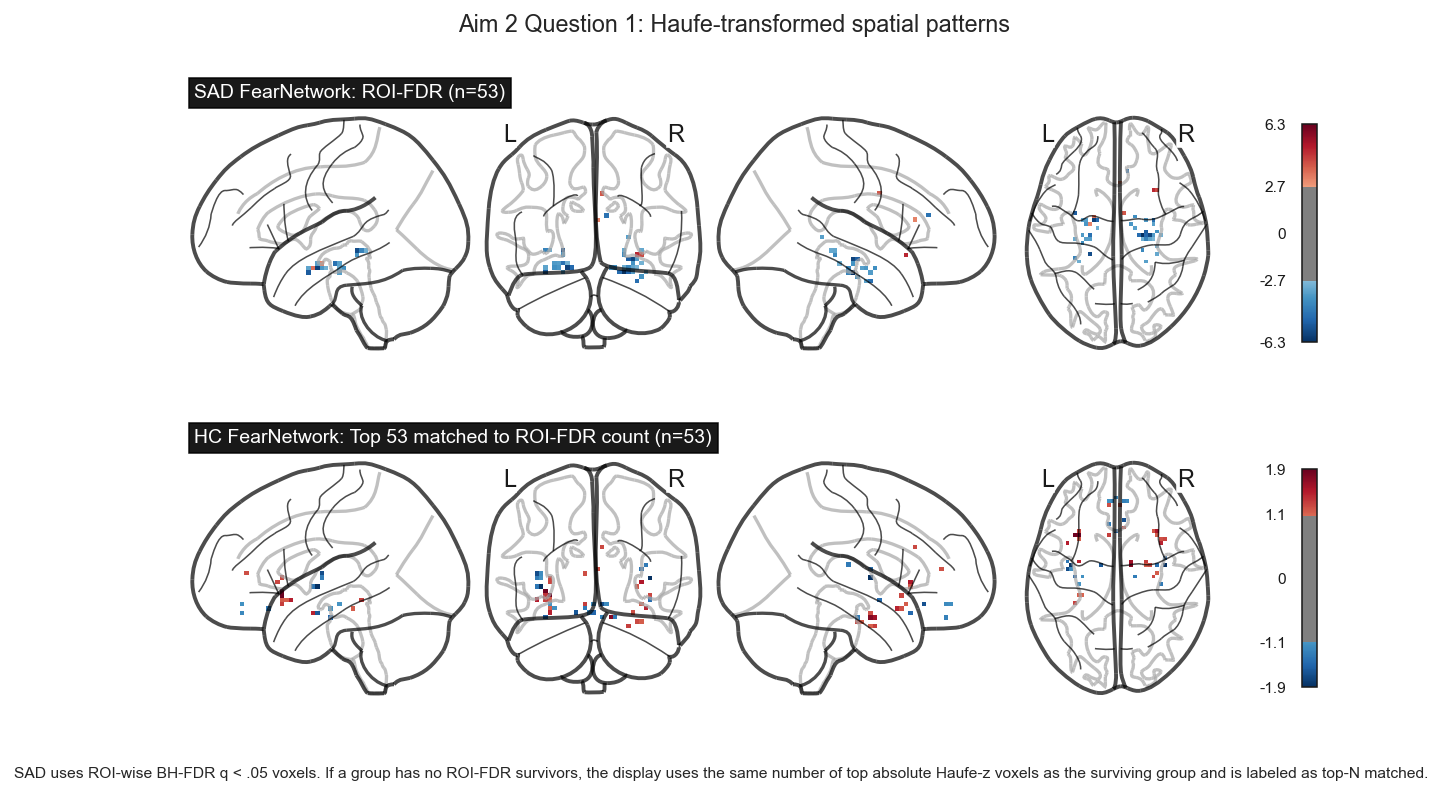

/var/folders/63/3j_hstl96w58qx1sdw9czhxr0000gn/T/ipykernel_93400/2791983437.py:29: RuntimeWarning: WARNING: using archived fallback checkpoint for Haufe decoding metadata for FearNetwork: /Users/xiaoqianxiao/projects/NARSAD/LSS/results/FearNetwork/checkpoints/cell_06.joblib. Prefer current post-Hyak CSV/Markdown exports when available.
  warnings.warn(message, RuntimeWarning)


**Legacy checkpoint fallback:** `/Users/xiaoqianxiao/projects/NARSAD/LSS/results/FearNetwork/checkpoints/cell_06.joblib` is being used only because the current export was not available for this display.

/var/folders/63/3j_hstl96w58qx1sdw9czhxr0000gn/T/ipykernel_93400/2791983437.py:29: RuntimeWarning: WARNING: using archived fallback checkpoint for Haufe importance masks for FearNetwork: /Users/xiaoqianxiao/projects/NARSAD/LSS/results/FearNetwork/intermediate/stage11_importance_masks.joblib. Prefer current post-Hyak CSV/Markdown exports when available.
  warnings.warn(message, RuntimeWarning)


**Legacy checkpoint fallback:** `/Users/xiaoqianxiao/projects/NARSAD/LSS/results/FearNetwork/intermediate/stage11_importance_masks.joblib` is being used only because the current export was not available for this display.

,Group,ROI,Mode,Total_voxels,ROI_FDR_voxels,Displayed_voxels,Percent_ROI
0,SAD,left_acc,ROI-FDR,259,0,0,0.000000
1,SAD,left_amygdala,ROI-FDR,103,10,10,9.708738
2,SAD,left_hippocampus,ROI-FDR,204,11,11,5.392157
3,SAD,left_insula,ROI-FDR,343,0,0,0.000000
4,SAD,left_vmpfc,ROI-FDR,180,0,0,0.000000
5,SAD,right_acc,ROI-FDR,232,3,3,1.293103
6,SAD,right_amygdala,ROI-FDR,104,3,3,2.884615
7,SAD,right_hippocampus,ROI-FDR,214,24,24,11.214953
8,SAD,right_insula,ROI-FDR,337,2,2,0.593472
9,SAD,right_vmpfc,ROI-FDR,172,0,0,0.000000


/var/folders/63/3j_hstl96w58qx1sdw9czhxr0000gn/T/ipykernel_93400/2791983437.py:29: RuntimeWarning: WARNING: using archived fallback checkpoint for Haufe decoding metadata for FearNetwork: /Users/xiaoqianxiao/projects/NARSAD/LSS/results/FearNetwork/checkpoints/cell_06.joblib. Prefer current post-Hyak CSV/Markdown exports when available.
  warnings.warn(message, RuntimeWarning)


**Legacy checkpoint fallback:** `/Users/xiaoqianxiao/projects/NARSAD/LSS/results/FearNetwork/checkpoints/cell_06.joblib` is being used only because the current export was not available for this display.

/var/folders/63/3j_hstl96w58qx1sdw9czhxr0000gn/T/ipykernel_93400/2791983437.py:29: RuntimeWarning: WARNING: using archived fallback checkpoint for Haufe importance masks for FearNetwork: /Users/xiaoqianxiao/projects/NARSAD/LSS/results/FearNetwork/intermediate/stage11_importance_masks.joblib. Prefer current post-Hyak CSV/Markdown exports when available.
  warnings.warn(message, RuntimeWarning)


**Legacy checkpoint fallback:** `/Users/xiaoqianxiao/projects/NARSAD/LSS/results/FearNetwork/intermediate/stage11_importance_masks.joblib` is being used only because the current export was not available for this display.

Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim2_q1_haufe_roi_fdr_distribution.png
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim2_q1_haufe_roi_fdr_distribution.pdf


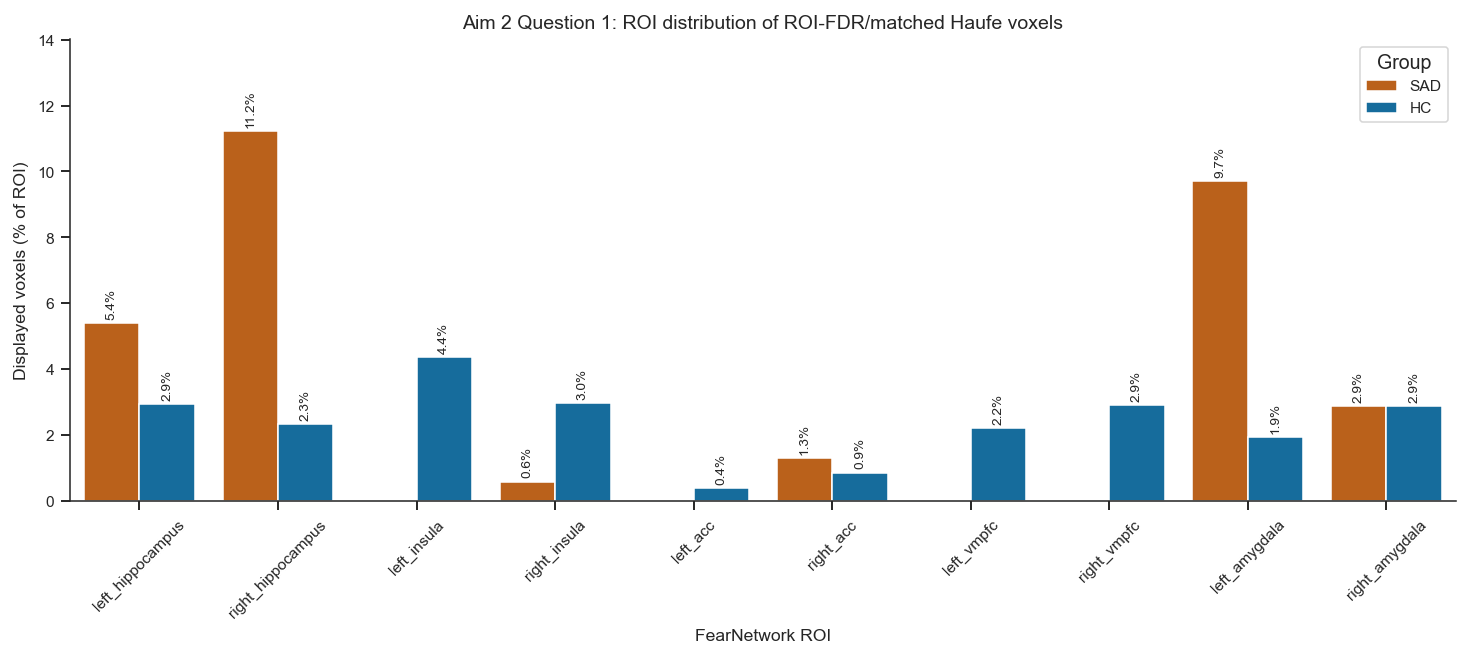

In [13]:
haufe_summary_df, haufe_assets = haufe_similarity_table('FearNetwork')
haufe_maps, haufe_messages = build_haufe_roi_fdr_maps(haufe_assets)
if haufe_messages:
    print('; '.join(haufe_messages))
display(haufe_summary_df)
show_figure_once(plot_haufe_glass_brains('FearNetwork'))
roi_dist_df = roi_distribution_table('FearNetwork')
display(roi_dist_df)
show_figure_once(plot_haufe_roi_distribution('FearNetwork'))


### Aim 2 Sensitivity: Haufe Spatial Pattern Stability In SCR Subgroups

This sensitivity check asks whether the Haufe-transformed spatial distribution remains visible when the linear decoder is retrained within SCR-defined placebo-session subject subsets. The subgroup models use the same regularization selected in the full placebo analysis, compute Haufe activation patterns using the same scaled-covariance transform, and compare top matched voxels against the full-sample ROI-FDR/matched Haufe distribution. This is a pattern-stability check, not a new confirmatory permutation test.


,scr_cohort,group,status,n_subjects,n_trials,top_n_selected_voxels,full_group_roi_fdr_voxels,full_group_display_mode,haufe_cosine_to_full_group_map,roi_distribution_spearman_to_full,roi_distribution_js_distance_to_full,selected_voxel_overlap_jaccard_to_full,dominant_roi,full_dominant_roi,dominant_roi_matches_full
0,SCR_Physiological_Responder,SAD,ok,13,208,53,53,ROI-FDR,0.220280,0.117489,0.526312,0.019231,left_insula,right_hippocampus,False
1,SCR_Physiological_Responder,HC,ok,18,288,53,0,Top 53 matched to ROI-FDR count,0.183098,-0.080505,0.425175,0.009524,right_insula,left_amygdala,False
2,SCR_Simple_Acquisition_Differential_Learner,SAD,ok,8,128,53,53,ROI-FDR,0.204977,0.038224,0.507279,0.019231,left_insula,right_hippocampus,False
3,SCR_Simple_Acquisition_Differential_Learner,HC,ok,12,192,53,0,Top 53 matched to ROI-FDR count,0.091631,-0.208593,0.418469,0.009524,right_insula,left_amygdala,False
4,SCR_Habituation_Adjusted_Learner,SAD,ok,7,112,53,53,ROI-FDR,0.221027,-0.034821,0.512171,0.019231,left_insula,right_hippocampus,False
5,SCR_Habituation_Adjusted_Learner,HC,ok,9,144,53,0,Top 53 matched to ROI-FDR count,-0.034081,-0.611624,0.623743,0.000000,left_acc,left_amygdala,False
6,SCR_Late_Phase_Sensitivity_Learner,SAD,too_few_subjects_or_classes,4,64,53,53,ROI-FDR,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,SCR_Late_Phase_Sensitivity_Learner,HC,too_few_subjects_or_classes,4,64,53,0,Top 53 matched to ROI-FDR count,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim2_haufe_scr_subgroup_stability.png
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim2_haufe_scr_subgroup_stability.pdf


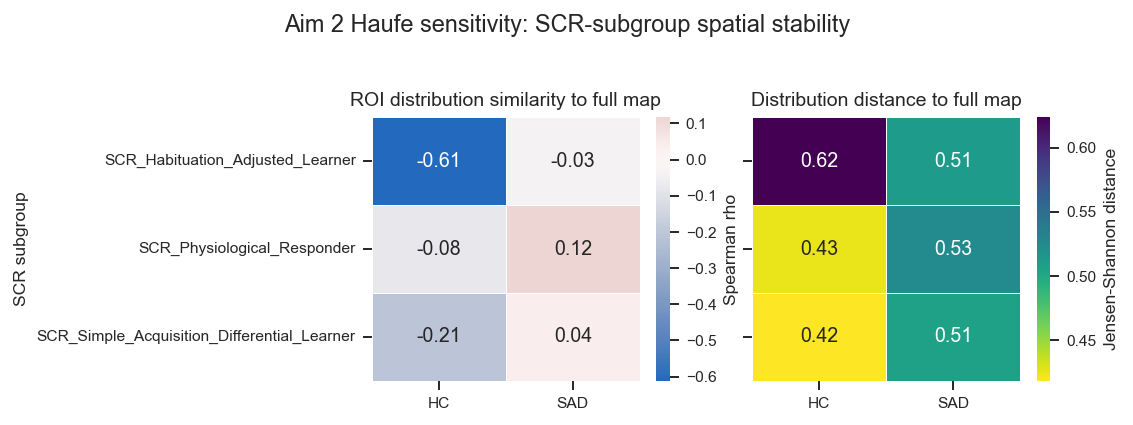

Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim2_haufe_scr_subgroup_roi_distribution.png
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim2_haufe_scr_subgroup_roi_distribution.pdf


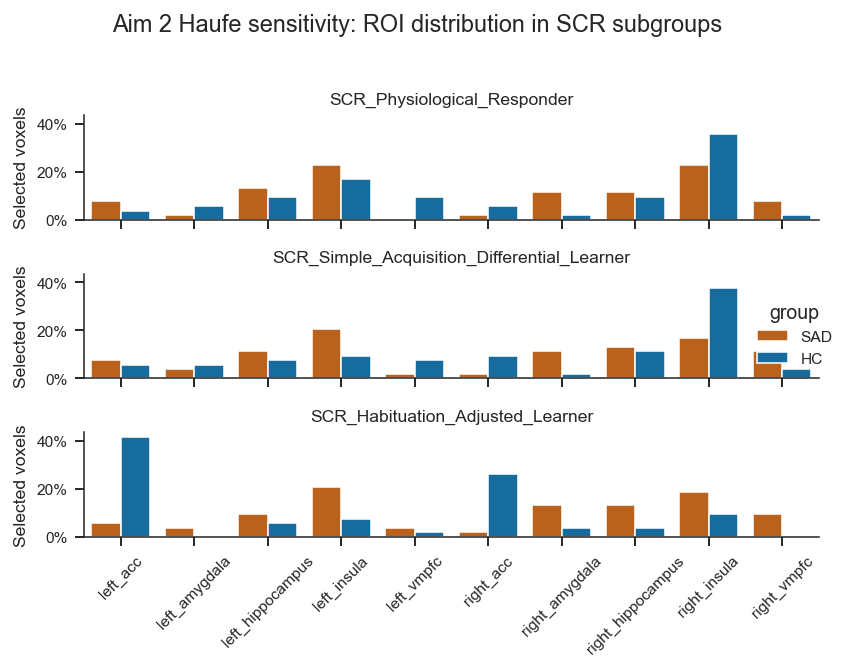

In [14]:
if aim2_haufe_scr_df.empty:
    display(Markdown('Haufe SCR-subgroup sensitivity output is not available. Run `scripts/export_haufe_scr_sensitivity.py` to generate it.'))
else:
    display_cols = [c for c in [
        'scr_cohort', 'group', 'status', 'n_subjects', 'n_trials', 'top_n_selected_voxels',
        'full_group_roi_fdr_voxels', 'full_group_display_mode', 'haufe_cosine_to_full_group_map',
        'roi_distribution_spearman_to_full', 'roi_distribution_js_distance_to_full',
        'selected_voxel_overlap_jaccard_to_full', 'dominant_roi', 'full_dominant_roi',
        'dominant_roi_matches_full'
    ] if c in aim2_haufe_scr_df.columns]
    display(aim2_haufe_scr_df[display_cols])
    ok = aim2_haufe_scr_df[aim2_haufe_scr_df.get('status', '').astype(str).eq('ok')].copy()
    if not ok.empty:
        fig, axes = plt.subplots(1, 2, figsize=(8.2, 2.9), sharey=True)
        heat = ok.pivot(index='scr_cohort', columns='group', values='roi_distribution_spearman_to_full')
        sns.heatmap(heat, cmap='vlag', center=0, annot=True, fmt='.2f', linewidths=0.5, cbar_kws={'label': 'Spearman rho'}, ax=axes[0])
        axes[0].set_title('ROI distribution similarity to full map')
        axes[0].set_xlabel('')
        axes[0].set_ylabel('SCR subgroup')
        heat_js = ok.pivot(index='scr_cohort', columns='group', values='roi_distribution_js_distance_to_full')
        sns.heatmap(heat_js, cmap='viridis_r', annot=True, fmt='.2f', linewidths=0.5, cbar_kws={'label': 'Jensen-Shannon distance'}, ax=axes[1])
        axes[1].set_title('Distribution distance to full map')
        axes[1].set_xlabel('')
        axes[1].set_ylabel('')
        fig.suptitle('Aim 2 Haufe sensitivity: SCR-subgroup spatial stability', y=1.03)
        fig.tight_layout()
        save_figure(fig, 'aim2_haufe_scr_subgroup_stability')
        show_figure_once(fig)
    if not aim2_haufe_scr_roi_df.empty:
        ok_keys = ok[['scr_cohort', 'group']] if not ok.empty else pd.DataFrame(columns=['scr_cohort', 'group'])
        roi_plot_df = aim2_haufe_scr_roi_df.merge(ok_keys, on=['scr_cohort', 'group'], how='inner') if not ok_keys.empty else pd.DataFrame()
        if not roi_plot_df.empty:
            cohort_order = [c for c in SCR_FLAGS if c in set(roi_plot_df['scr_cohort'])]
            g = sns.catplot(
                data=roi_plot_df, x='roi', y='selected_pct_of_selected', hue='group', row='scr_cohort',
                row_order=cohort_order, kind='bar', height=1.55, aspect=3.5, palette=GROUP_COLORS, sharey=True
            )
            g.set_axis_labels('', 'Selected voxels')
            g.set_titles('{row_name}')
            for ax in g.axes.flat:
                ax.tick_params(axis='x', rotation=45)
                ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{100*y:.0f}%'))
            g.figure.suptitle('Aim 2 Haufe sensitivity: ROI distribution in SCR subgroups', y=1.02)
            g.figure.tight_layout()
            save_figure(g.figure, 'aim2_haufe_scr_subgroup_roi_distribution')
            show_figure_once(g.figure)
            plt.close(g.figure)


### Aim 2 Secondary: Residualized Shock-Anchor Check

Shock/US responses can be dominated by sensory-pain, salience, motor/autonomic, and global amplitude components. Therefore, shock is not treated as a primary learning trajectory target. Instead, this secondary check uses shock as an aversive anchor after trial-wise feature-mean residualization: for each subject, the analysis computes a residualized `Shock - CS-` axis and tests whether `CSR - CS-` and `CSS - CS-` patterns project onto that axis. The key readout is `Cosine_CSR_minus_CSS`, which asks whether threat cues are more shock-aligned than safety cues beyond global shock reactivity.


Wrote residualized shock-anchor subject table: /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/aim2_residualized_shock_anchor_subjects.csv
Wrote residualized shock-anchor summary table: /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/aim2_residualized_shock_anchor_summary.csv
Wrote residualized shock-anchor trial-wise table: /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/aim2_residualized_shock_anchor_trialwise_paired.csv
Wrote residualized shock-anchor trial-wise summary: /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/aim2_residualized_shock_anchor_trialwise_summary.csv


**Residualized shock-anchor summary:** shock is used as an aversive anchor after trial-wise feature-mean residualization; this reduces global shock amplitude dominance.

,metric,p,n
2,Cosine_CSS,0.087424,50
7,Cosine_CSR_minus_CSS,0.153036,28
5,Cosine_CSR,0.161892,50
6,Cosine_CSR_minus_CSS,0.468313,22
10,Projection_CSR_minus_CSS,0.577585,28
8,Cosine_CSR_minus_CSS,0.727239,50
9,Projection_CSR_minus_CSS,0.731922,22
14,Shock_Axis_Norm,0.746550,50
11,Projection_CSR_minus_CSS,0.938008,50
0,Cosine_CSS,NaN,22


,Group
0,SAD
1,SAD
2,SAD
3,SAD
4,SAD
5,SAD
6,SAD
7,SAD
8,SAD
9,SAD


**Trial-wise residualized shock-anchor dynamics:** within-subject cue occurrence indexes are used as trial order for CSS and CSR. The dynamic readout is trial-wise `CSR - CSS` cosine alignment with the residualized shock axis.

,p,n
20,0.002030,50
25,0.237268,28
14,0.384406,50
26,0.583367,50
11,0.631567,50
23,0.656889,50
17,0.735069,50
5,0.841074,50
24,0.938292,22
8,0.953940,50


,Group
0,SAD
1,SAD
2,SAD
3,SAD
4,SAD
5,SAD
6,SAD
7,SAD
8,SAD
9,SAD


/var/folders/63/3j_hstl96w58qx1sdw9czhxr0000gn/T/ipykernel_93400/1830573324.py:318: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=sep, x='Group', y='Threat - safety alignment', order=['HC', 'SAD'], palette=GROUP_COLORS, inner=None, cut=0, linewidth=0.8, ax=dist_ax)


Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim2_residualized_shock_anchor.png
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim2_residualized_shock_anchor.pdf


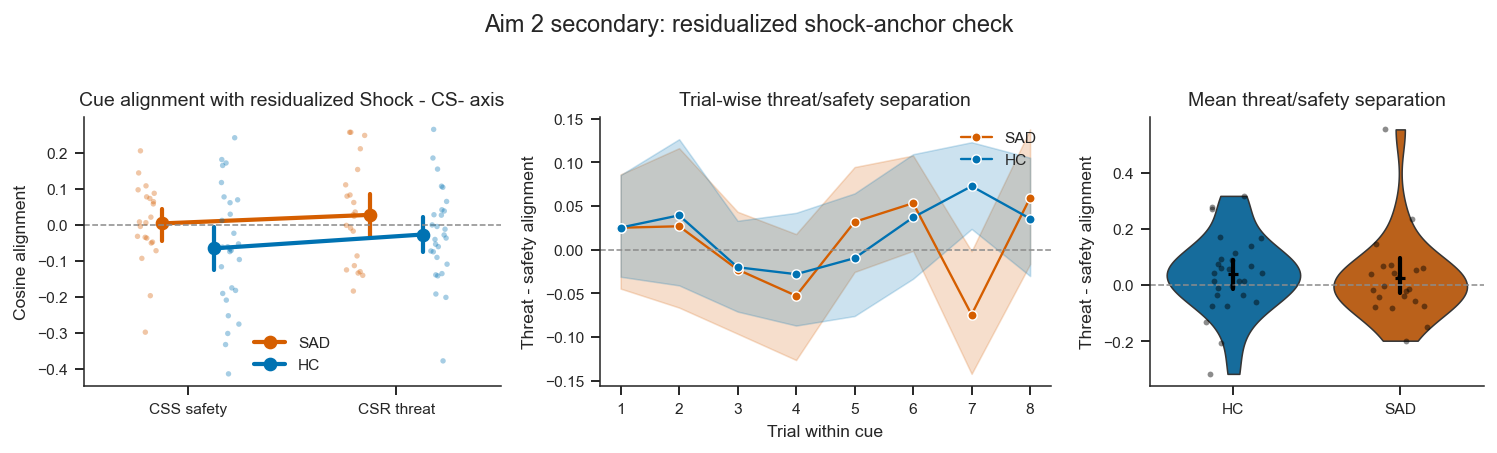

In [15]:
def trial_feature_mean_residualize(X):
    X = np.asarray(X, dtype=float)
    if X.ndim != 2 or X.size == 0:
        return X
    return X - np.nanmean(X, axis=1, keepdims=True)


def condition_mask(labels, names):
    if isinstance(names, str):
        names = [names]
    return np.isin(np.asarray(labels).astype(str), list(names))


def shock_anchor_source_arrays(feature_space='FearNetwork'):
    base = feature_space_dir(feature_space)
    cell3 = load_joblib(base / 'checkpoints' / 'cell_03.joblib') or {}
    cell5 = load_joblib(base / 'checkpoints' / 'cell_05.joblib') or {}
    ext_subsets = cell5.get('ext_subsets', {}) if isinstance(cell5, dict) else {}
    subject_sets = {}
    for group, key in [('SAD', 'SAD_Placebo'), ('HC', 'HC_Placebo')]:
        subset = ext_subsets.get(key, {}) if isinstance(ext_subsets, dict) else {}
        subject_sets[group] = set(np.asarray(subset.get('sub', [])).astype(str))
    needed = ['X_ext', 'y_ext', 'sub_ext', 'X_reinst', 'y_reinst', 'sub_reinst']
    if not all(k in cell3 for k in needed):
        return {}, f'Missing required arrays in {base / "checkpoints" / "cell_03.joblib"}'
    return {
        'X_ext': np.asarray(cell3['X_ext'], dtype=float),
        'y_ext': np.asarray(cell3['y_ext']).astype(str),
        'sub_ext': np.asarray(cell3['sub_ext']).astype(str),
        'X_reinst': np.asarray(cell3['X_reinst'], dtype=float),
        'y_reinst': np.asarray(cell3['y_reinst']).astype(str),
        'sub_reinst': np.asarray(cell3['sub_reinst']).astype(str),
        'subject_sets': subject_sets,
        'feature_space': feature_space,
    }, None


def calculate_residualized_shock_anchor_projection_for_group(arrays, group):
    rows = []
    subjects = arrays['subject_sets'].get(group, set())
    if not subjects:
        return pd.DataFrame(rows)
    ext_subject_mask = np.isin(arrays['sub_ext'], list(subjects))
    shock_subject_mask = np.isin(arrays['sub_reinst'], list(subjects))
    X_cs = trial_feature_mean_residualize(arrays['X_ext'][ext_subject_mask])
    y_cs = arrays['y_ext'][ext_subject_mask]
    sub_cs = arrays['sub_ext'][ext_subject_mask]
    shock_mask = shock_subject_mask & condition_mask(arrays['y_reinst'], 'SHOCK')
    X_shock = trial_feature_mean_residualize(arrays['X_reinst'][shock_mask])
    sub_shock = arrays['sub_reinst'][shock_mask]
    shared_subjects = np.intersect1d(np.unique(sub_cs), np.unique(sub_shock))
    for sub in shared_subjects:
        m_base = (sub_cs == sub) & condition_mask(y_cs, 'CS-')
        m_css = (sub_cs == sub) & condition_mask(y_cs, 'CSS')
        m_csr = (sub_cs == sub) & condition_mask(y_cs, 'CSR')
        m_shock = sub_shock == sub
        if not (np.any(m_base) and np.any(m_css) and np.any(m_csr) and np.any(m_shock)):
            continue
        base = np.nanmean(X_cs[m_base], axis=0)
        css = np.nanmean(X_cs[m_css], axis=0)
        csr = np.nanmean(X_cs[m_csr], axis=0)
        shock = np.nanmean(X_shock[m_shock], axis=0)
        shock_axis = shock - base
        axis_norm = np.linalg.norm(shock_axis)
        if not np.isfinite(axis_norm) or axis_norm <= 0:
            continue
        shock_axis = shock_axis / axis_norm
        def project(vec):
            delta = vec - base
            delta_norm = np.linalg.norm(delta)
            projection = float(np.dot(delta, shock_axis))
            cosine = np.nan if delta_norm <= 0 else float(projection / delta_norm)
            return projection, cosine
        proj_css, cos_css = project(css)
        proj_csr, cos_csr = project(csr)
        rows.append({
            'Subject': sub,
            'Group': group,
            'Projection_CSS': proj_css,
            'Projection_CSR': proj_csr,
            'Projection_CSR_minus_CSS': proj_csr - proj_css,
            'Cosine_CSS': cos_css,
            'Cosine_CSR': cos_csr,
            'Cosine_CSR_minus_CSS': cos_csr - cos_css if np.isfinite(cos_css) and np.isfinite(cos_csr) else np.nan,
            'Shock_Axis_Norm': float(axis_norm),
            'n_shock_trials': int(np.sum(m_shock)),
            'n_csminus_trials': int(np.sum(m_base)),
            'n_css_trials': int(np.sum(m_css)),
            'n_csr_trials': int(np.sum(m_csr)),
        })
    return pd.DataFrame(rows)


def calculate_residualized_shock_anchor_trialwise_for_group(arrays, group):
    rows = []
    subjects = arrays['subject_sets'].get(group, set())
    if not subjects:
        return pd.DataFrame(rows), pd.DataFrame()
    ext_subject_mask = np.isin(arrays['sub_ext'], list(subjects))
    shock_subject_mask = np.isin(arrays['sub_reinst'], list(subjects))
    X_cs = trial_feature_mean_residualize(arrays['X_ext'][ext_subject_mask])
    y_cs = arrays['y_ext'][ext_subject_mask]
    sub_cs = arrays['sub_ext'][ext_subject_mask]
    shock_mask = shock_subject_mask & condition_mask(arrays['y_reinst'], 'SHOCK')
    X_shock = trial_feature_mean_residualize(arrays['X_reinst'][shock_mask])
    sub_shock = arrays['sub_reinst'][shock_mask]
    shared_subjects = np.intersect1d(np.unique(sub_cs), np.unique(sub_shock))
    for sub in shared_subjects:
        m_sub = sub_cs == sub
        m_base = m_sub & condition_mask(y_cs, 'CS-')
        m_shock = sub_shock == sub
        if not (np.any(m_base) and np.any(m_shock)):
            continue
        base = np.nanmean(X_cs[m_base], axis=0)
        shock = np.nanmean(X_shock[m_shock], axis=0)
        shock_axis = shock - base
        axis_norm = np.linalg.norm(shock_axis)
        if not np.isfinite(axis_norm) or axis_norm <= 0:
            continue
        shock_axis = shock_axis / axis_norm
        cue_counts = {'CSS': 0, 'CSR': 0}
        subject_idx = np.where(m_sub)[0]
        for idx in subject_idx:
            cue = str(y_cs[idx])
            if cue not in cue_counts:
                continue
            cue_counts[cue] += 1
            delta = X_cs[idx] - base
            delta_norm = np.linalg.norm(delta)
            projection = float(np.dot(delta, shock_axis))
            cosine = np.nan if delta_norm <= 0 else float(projection / delta_norm)
            rows.append({
                'Subject': sub,
                'Group': group,
                'Cue': cue,
                'Trial': int(cue_counts[cue]),
                'Projection': projection,
                'Cosine': cosine,
                'Shock_Axis_Norm': float(axis_norm),
            })
    long_df = pd.DataFrame(rows)
    if long_df.empty:
        return long_df, pd.DataFrame()
    paired = long_df.pivot_table(index=['Subject', 'Group', 'Trial'], columns='Cue', values='Cosine', aggfunc='mean').reset_index()
    if {'CSR', 'CSS'}.issubset(paired.columns):
        paired['Cosine_CSR_minus_CSS'] = paired['CSR'] - paired['CSS']
    else:
        paired['Cosine_CSR_minus_CSS'] = np.nan
    return long_df, paired


def summarize_shock_anchor_trialwise(paired_df):
    if paired_df is None or paired_df.empty:
        return pd.DataFrame()
    rows = []
    try:
        from scipy import stats
    except Exception:
        stats = None
    for trial, trial_df in paired_df.groupby('Trial'):
        for group in ['SAD', 'HC']:
            vals = pd.to_numeric(trial_df.loc[trial_df['Group'].eq(group), 'Cosine_CSR_minus_CSS'], errors='coerce').dropna().to_numpy()
            rows.append({'contrast': 'trial mean', 'Trial': int(trial), 'group': group, 'n': int(vals.size), 'mean': float(np.nanmean(vals)) if vals.size else np.nan, 'sd': float(np.nanstd(vals, ddof=1)) if vals.size > 1 else np.nan, 't': np.nan, 'p': np.nan})
        sad = pd.to_numeric(trial_df.loc[trial_df['Group'].eq('SAD'), 'Cosine_CSR_minus_CSS'], errors='coerce').dropna().to_numpy()
        hc = pd.to_numeric(trial_df.loc[trial_df['Group'].eq('HC'), 'Cosine_CSR_minus_CSS'], errors='coerce').dropna().to_numpy()
        if stats is not None and sad.size >= 2 and hc.size >= 2:
            t_val, p_val = stats.ttest_ind(sad, hc, equal_var=False, nan_policy='omit')
        else:
            t_val = p_val = np.nan
        rows.append({'contrast': 'SAD - HC at trial', 'Trial': int(trial), 'group': 'GroupDiff', 'n': int(sad.size + hc.size), 'mean': float(np.nanmean(sad) - np.nanmean(hc)) if sad.size and hc.size else np.nan, 'sd': np.nan, 't': float(t_val) if np.isfinite(t_val) else np.nan, 'p': float(p_val) if np.isfinite(p_val) else np.nan})
    slope_rows = []
    for (sub, group), sub_df in paired_df.groupby(['Subject', 'Group']):
        temp = sub_df[['Trial', 'Cosine_CSR_minus_CSS']].copy()
        temp['Trial'] = pd.to_numeric(temp['Trial'], errors='coerce')
        temp['Cosine_CSR_minus_CSS'] = pd.to_numeric(temp['Cosine_CSR_minus_CSS'], errors='coerce')
        temp = temp.dropna()
        if temp['Trial'].nunique() < 2:
            continue
        x = (temp['Trial'] - temp['Trial'].mean()).to_numpy(dtype=float)
        y = temp['Cosine_CSR_minus_CSS'].to_numpy(dtype=float)
        denom = float(np.dot(x, x))
        if denom <= 0:
            continue
        slope = float(np.dot(x, y - np.nanmean(y)) / denom)
        slope_rows.append({'Subject': sub, 'Group': group, 'ShockAnchor_Separation_Slope': slope, 'n_trials': int(temp.shape[0])})
    slope_df = pd.DataFrame(slope_rows)
    for group in ['SAD', 'HC']:
        vals = pd.to_numeric(slope_df.loc[slope_df['Group'].eq(group), 'ShockAnchor_Separation_Slope'], errors='coerce').dropna().to_numpy() if not slope_df.empty else np.array([])
        if stats is not None and vals.size >= 2:
            t_val, p_val = stats.ttest_1samp(vals, 0.0, nan_policy='omit')
        else:
            t_val = p_val = np.nan
        rows.append({'contrast': 'slope one-sample vs 0', 'Trial': np.nan, 'group': group, 'n': int(vals.size), 'mean': float(np.nanmean(vals)) if vals.size else np.nan, 'sd': float(np.nanstd(vals, ddof=1)) if vals.size > 1 else np.nan, 't': float(t_val) if np.isfinite(t_val) else np.nan, 'p': float(p_val) if np.isfinite(p_val) else np.nan})
    sad = pd.to_numeric(slope_df.loc[slope_df['Group'].eq('SAD'), 'ShockAnchor_Separation_Slope'], errors='coerce').dropna().to_numpy() if not slope_df.empty else np.array([])
    hc = pd.to_numeric(slope_df.loc[slope_df['Group'].eq('HC'), 'ShockAnchor_Separation_Slope'], errors='coerce').dropna().to_numpy() if not slope_df.empty else np.array([])
    if stats is not None and sad.size >= 2 and hc.size >= 2:
        t_val, p_val = stats.ttest_ind(sad, hc, equal_var=False, nan_policy='omit')
    else:
        t_val = p_val = np.nan
    rows.append({'contrast': 'slope SAD - HC', 'Trial': np.nan, 'group': 'GroupDiff', 'n': int(sad.size + hc.size), 'mean': float(np.nanmean(sad) - np.nanmean(hc)) if sad.size and hc.size else np.nan, 'sd': np.nan, 't': float(t_val) if np.isfinite(t_val) else np.nan, 'p': float(p_val) if np.isfinite(p_val) else np.nan})
    return pd.DataFrame(rows), slope_df


def residualized_shock_anchor_results(feature_space='FearNetwork'):
    arrays, err = shock_anchor_source_arrays(feature_space)
    if err:
        print(err)
        return pd.DataFrame(), pd.DataFrame()
    frames = [calculate_residualized_shock_anchor_projection_for_group(arrays, group) for group in ['SAD', 'HC']]
    trial_long_frames = []
    trial_paired_frames = []
    for group in ['SAD', 'HC']:
        long_df, paired_df = calculate_residualized_shock_anchor_trialwise_for_group(arrays, group)
        if not long_df.empty:
            trial_long_frames.append(long_df)
        if not paired_df.empty:
            trial_paired_frames.append(paired_df)
    df = pd.concat([f for f in frames if not f.empty], ignore_index=True) if any(not f.empty for f in frames) else pd.DataFrame()
    trial_long_df = pd.concat(trial_long_frames, ignore_index=True) if trial_long_frames else pd.DataFrame()
    trial_paired_df = pd.concat(trial_paired_frames, ignore_index=True) if trial_paired_frames else pd.DataFrame()
    if df.empty:
        print('Residualized shock-anchor data are unavailable.')
        return df, pd.DataFrame(), trial_long_df, trial_paired_df, pd.DataFrame(), pd.DataFrame()
    rows = []
    try:
        from scipy import stats
    except Exception:
        stats = None
    metrics = ['Cosine_CSS', 'Cosine_CSR', 'Cosine_CSR_minus_CSS', 'Projection_CSR_minus_CSS', 'Shock_Axis_Norm']
    for metric in metrics:
        for group in ['SAD', 'HC']:
            vals = pd.to_numeric(df.loc[df['Group'].eq(group), metric], errors='coerce').dropna().to_numpy()
            if vals.size == 0:
                continue
            t_val = p_val = np.nan
            if stats is not None and vals.size >= 2 and metric.endswith('minus_CSS'):
                t_val, p_val = stats.ttest_1samp(vals, 0.0, nan_policy='omit')
            rows.append({
                'contrast': 'one-sample vs 0' if metric.endswith('minus_CSS') else 'descriptive',
                'metric': metric,
                'group': group,
                'n': int(vals.size),
                'mean': float(np.nanmean(vals)),
                'sd': float(np.nanstd(vals, ddof=1)) if vals.size > 1 else np.nan,
                't': float(t_val) if np.isfinite(t_val) else np.nan,
                'p': float(p_val) if np.isfinite(p_val) else np.nan,
            })
        sad = pd.to_numeric(df.loc[df['Group'].eq('SAD'), metric], errors='coerce').dropna().to_numpy()
        hc = pd.to_numeric(df.loc[df['Group'].eq('HC'), metric], errors='coerce').dropna().to_numpy()
        if stats is not None and sad.size >= 2 and hc.size >= 2:
            t_val, p_val = stats.ttest_ind(sad, hc, equal_var=False, nan_policy='omit')
        else:
            t_val = p_val = np.nan
        rows.append({
            'contrast': 'SAD - HC',
            'metric': metric,
            'group': 'GroupDiff',
            'n': int(sad.size + hc.size),
            'mean': float(np.nanmean(sad) - np.nanmean(hc)) if sad.size and hc.size else np.nan,
            'sd': np.nan,
            't': float(t_val) if np.isfinite(t_val) else np.nan,
            'p': float(p_val) if np.isfinite(p_val) else np.nan,
        })
    summary = pd.DataFrame(rows)
    trial_summary, slope_df = summarize_shock_anchor_trialwise(trial_paired_df)
    out_subject = STATS_DIR / 'aim2_residualized_shock_anchor_subjects.csv'
    out_summary = STATS_DIR / 'aim2_residualized_shock_anchor_summary.csv'
    out_trial_long = STATS_DIR / 'aim2_residualized_shock_anchor_trialwise_long.csv'
    out_trial_paired = STATS_DIR / 'aim2_residualized_shock_anchor_trialwise_paired.csv'
    out_trial_summary = STATS_DIR / 'aim2_residualized_shock_anchor_trialwise_summary.csv'
    out_trial_slopes = STATS_DIR / 'aim2_residualized_shock_anchor_trialwise_slopes.csv'
    df.to_csv(out_subject, index=False)
    summary.to_csv(out_summary, index=False)
    trial_long_df.to_csv(out_trial_long, index=False)
    trial_paired_df.to_csv(out_trial_paired, index=False)
    trial_summary.to_csv(out_trial_summary, index=False)
    slope_df.to_csv(out_trial_slopes, index=False)
    print(f'Wrote residualized shock-anchor subject table: {out_subject}')
    print(f'Wrote residualized shock-anchor summary table: {out_summary}')
    print(f'Wrote residualized shock-anchor trial-wise table: {out_trial_paired}')
    print(f'Wrote residualized shock-anchor trial-wise summary: {out_trial_summary}')
    return df, summary, trial_long_df, trial_paired_df, trial_summary, slope_df


def plot_residualized_shock_anchor(df, trial_paired_df=None, filename='aim2_residualized_shock_anchor'):
    if df is None or df.empty:
        print('No residualized shock-anchor figure available.')
        return None
    long = df.melt(id_vars=['Subject', 'Group'], value_vars=['Cosine_CSS', 'Cosine_CSR'], var_name='Cue', value_name='Cosine alignment')
    long['Cue'] = long['Cue'].map({'Cosine_CSS': 'CSS safety', 'Cosine_CSR': 'CSR threat'})
    sep = df[['Subject', 'Group', 'Cosine_CSR_minus_CSS']].copy().rename(columns={'Cosine_CSR_minus_CSS': 'Threat - safety alignment'})
    has_trial = trial_paired_df is not None and not trial_paired_df.empty and 'Cosine_CSR_minus_CSS' in trial_paired_df.columns
    if has_trial:
        fig, axes = plt.subplots(1, 3, figsize=(10.8, 3.1), gridspec_kw={'width_ratios': [1.25, 1.35, 1]})
    else:
        fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.1), gridspec_kw={'width_ratios': [1.35, 1]})
    sns.pointplot(data=long, x='Cue', y='Cosine alignment', hue='Group', palette=GROUP_COLORS, dodge=0.25, errorbar=('ci', 95), markers='o', linestyles='-', ax=axes[0])
    sns.stripplot(data=long, x='Cue', y='Cosine alignment', hue='Group', palette=GROUP_COLORS, dodge=True, alpha=0.35, size=2.8, ax=axes[0])
    handles, labels = axes[0].get_legend_handles_labels()
    axes[0].legend(handles[:2], labels[:2], title='', frameon=False)
    axes[0].axhline(0, color='0.55', linestyle='--', linewidth=0.8)
    axes[0].set_title('Cue alignment with residualized Shock - CS- axis')
    axes[0].set_xlabel('')
    if has_trial:
        trial_plot = trial_paired_df.copy()
        trial_plot['Trial'] = pd.to_numeric(trial_plot['Trial'], errors='coerce')
        trial_plot['Shock-anchor separation'] = pd.to_numeric(trial_plot['Cosine_CSR_minus_CSS'], errors='coerce')
        trial_plot = trial_plot.dropna(subset=['Trial', 'Shock-anchor separation'])
        sns.lineplot(data=trial_plot, x='Trial', y='Shock-anchor separation', hue='Group', hue_order=['SAD', 'HC'], palette=GROUP_COLORS, errorbar=('ci', 95), marker='o', ax=axes[1])
        axes[1].axhline(0, color='0.55', linestyle='--', linewidth=0.8)
        axes[1].set_title('Trial-wise threat/safety separation')
        axes[1].set_xlabel('Trial within cue')
        axes[1].set_ylabel('Threat - safety alignment')
        axes[1].legend(title='', frameon=False)
        dist_ax = axes[2]
    else:
        dist_ax = axes[1]
    sns.violinplot(data=sep, x='Group', y='Threat - safety alignment', order=['HC', 'SAD'], palette=GROUP_COLORS, inner=None, cut=0, linewidth=0.8, ax=dist_ax)
    sns.stripplot(data=sep, x='Group', y='Threat - safety alignment', order=['HC', 'SAD'], color='black', alpha=0.45, size=3, jitter=0.18, ax=dist_ax)
    sns.pointplot(data=sep, x='Group', y='Threat - safety alignment', order=['HC', 'SAD'], color='black', errorbar=('ci', 95), markers='_', linestyles='none', ax=dist_ax)
    dist_ax.axhline(0, color='0.55', linestyle='--', linewidth=0.8)
    dist_ax.set_title('Mean threat/safety separation')
    dist_ax.set_xlabel('')
    fig.suptitle('Aim 2 secondary: residualized shock-anchor check', y=1.03)
    fig.tight_layout()
    save_figure(fig, filename)
    return fig

shock_anchor_df, shock_anchor_summary, shock_anchor_trial_long_df, shock_anchor_trial_paired_df, shock_anchor_trial_summary, shock_anchor_trial_slope_df = residualized_shock_anchor_results('FearNetwork')
display(Markdown('**Residualized shock-anchor summary:** shock is used as an aversive anchor after trial-wise feature-mean residualization; this reduces global shock amplitude dominance.'))
display(tidy_result_table(shock_anchor_summary, n=60))
display(tidy_result_table(shock_anchor_df, n=80))
display(Markdown('**Trial-wise residualized shock-anchor dynamics:** within-subject cue occurrence indexes are used as trial order for CSS and CSR. The dynamic readout is trial-wise `CSR - CSS` cosine alignment with the residualized shock axis.'))
display(tidy_result_table(shock_anchor_trial_summary, n=80))
display(tidy_result_table(shock_anchor_trial_slope_df, n=80))
show_figure_once(plot_residualized_shock_anchor(shock_anchor_df, shock_anchor_trial_paired_df))


### Aim 2 Support/Contextual Only Metrics

These secondary metrics clarify specificity: whether a shared-metric finding is safety-specific, threat-specific, or reflects broader reorganization of the threat-safety neural space. They are displayed as support/contextual only and are not part of the shared Aim 2-5 primary inferential metric family.


**Support/contextual only metrics:** descriptive group distributions only; these metrics are not included in the shared Aim 2-5 primary inferential model family.

,metric,role,available_in_subject_table
0,Neural_Dist_Threat_Background,support/contextual only,False
1,Neural_Boundary_Separation,support/contextual only,True
2,Neural_Decoder_Entropy_CSS,support/contextual only,False
3,Neural_Decoder_Entropy_CSR,support/contextual only,False


/var/folders/63/3j_hstl96w58qx1sdw9czhxr0000gn/T/ipykernel_93400/2147339308.py:238: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x=group_col, y=metric, order=order, palette=palette, inner=None, linewidth=0.8, cut=0, ax=ax)


Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim2_support_contextual_metric_distributions.png
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim2_support_contextual_metric_distributions.pdf


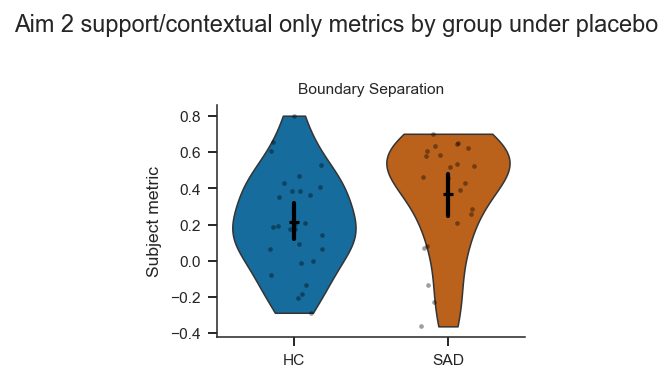

In [16]:
display(Markdown('**Support/contextual only metrics:** descriptive group distributions only; these metrics are not included in the shared Aim 2-5 primary inferential model family.'))
secondary_available = [m for m in SECONDARY_SUPPORT_METRICS if not metrics_df.empty and m in metrics_df.columns]
secondary_metric_registry = pd.DataFrame({
    'metric': SECONDARY_SUPPORT_METRICS,
    'role': 'support/contextual only',
    'available_in_subject_table': [metric in secondary_available for metric in SECONDARY_SUPPORT_METRICS],
})
display(secondary_metric_registry)
show_figure_once(plot_subject_metric_grid(metrics_df, secondary_available, 'Aim 2 support/contextual only metrics by group under placebo', feature_space='FearNetwork', drug='Placebo', filename='aim2_support_contextual_metric_distributions'))


### Aim 2 Sensitivity: Alternative Masks And Feature Spaces

These checks test whether SAD-HC neural-profile results are robust to alternative feature definitions when those outputs are available. Missing whole-brain/Schaefer results are labeled as pending rather than interpreted as null.


,analysis,sensitivity,feature_space,metric,scr_index,term,estimate,ci_low,ci_high,p,q,n,r2,status,formula
45,Sensitivity_Aim2_Group,SCRCohort:SCR_Physiological_Responder,FearNetwork,Neural_Boundary_Separation,NaN,"C(Group, Treatment(reference='HC'))[T.SAD]",0.319540,0.103919,0.535162,0.005199,0.017923,31,0.257194,ok,"Q('Neural_Boundary_Separation') ~ C(Group, Tre..."
47,Sensitivity_Aim2_Group,SCRCohort:SCR_Physiological_Responder,FearNetwork,Neural_Safety_Trajectory_Slope,NaN,"C(Group, Treatment(reference='HC'))[T.SAD]",0.021812,0.005946,0.037678,0.008872,0.017923,31,0.415559,ok,"Q('Neural_Safety_Trajectory_Slope') ~ C(Group,..."
43,Sensitivity_Aim2_Group,SCRCohort:SCR_Physiological_Responder,FearNetwork,Neural_ThreatLike_Safety,NaN,"C(Group, Treatment(reference='HC'))[T.SAD]",-0.190549,-0.332174,-0.048924,0.010242,0.017923,31,0.230055,ok,"Q('Neural_ThreatLike_Safety') ~ C(Group, Treat..."
44,Sensitivity_Aim2_Group,SCRCohort:SCR_Physiological_Responder,FearNetwork,Neural_SafetyLike_Safety,NaN,"C(Group, Treatment(reference='HC'))[T.SAD]",0.190549,0.048924,0.332174,0.010242,0.017923,31,0.230055,ok,"Q('Neural_SafetyLike_Safety') ~ C(Group, Treat..."
85,Sensitivity_Aim2_Group,SCRCohort:SCR_Simple_Acquisition_Differential_...,FearNetwork,Neural_ThreatLike_Safety,NaN,"C(Group, Treatment(reference='HC'))[T.SAD]",-0.221705,-0.387688,-0.055723,0.012030,0.038529,20,0.371243,ok,"Q('Neural_ThreatLike_Safety') ~ C(Group, Treat..."
86,Sensitivity_Aim2_Group,SCRCohort:SCR_Simple_Acquisition_Differential_...,FearNetwork,Neural_SafetyLike_Safety,NaN,"C(Group, Treatment(reference='HC'))[T.SAD]",0.221705,0.055723,0.387688,0.012030,0.038529,20,0.371243,ok,"Q('Neural_SafetyLike_Safety') ~ C(Group, Treat..."
87,Sensitivity_Aim2_Group,SCRCohort:SCR_Simple_Acquisition_Differential_...,FearNetwork,Neural_Boundary_Separation,NaN,"C(Group, Treatment(reference='HC'))[T.SAD]",0.303959,0.063307,0.544611,0.016513,0.038529,20,0.350611,ok,"Q('Neural_Boundary_Separation') ~ C(Group, Tre..."
128,Sensitivity_Aim2_Group,SCRCohort:SCR_Habituation_Adjusted_Learner,FearNetwork,Neural_SafetyLike_Safety,NaN,"C(Group, Treatment(reference='HC'))[T.SAD]",0.185155,0.015467,0.354844,0.034927,0.122246,16,0.428032,ok,"Q('Neural_SafetyLike_Safety') ~ C(Group, Treat..."
127,Sensitivity_Aim2_Group,SCRCohort:SCR_Habituation_Adjusted_Learner,FearNetwork,Neural_ThreatLike_Safety,NaN,"C(Group, Treatment(reference='HC'))[T.SAD]",-0.185155,-0.354844,-0.015467,0.034927,0.122246,16,0.428032,ok,"Q('Neural_ThreatLike_Safety') ~ C(Group, Treat..."
129,Sensitivity_Aim2_Group,SCRCohort:SCR_Habituation_Adjusted_Learner,FearNetwork,Neural_Boundary_Separation,NaN,"C(Group, Treatment(reference='HC'))[T.SAD]",0.259810,-0.025195,0.544814,0.070335,0.164116,16,0.328466,ok,"Q('Neural_Boundary_Separation') ~ C(Group, Tre..."


,analysis,sensitivity,feature_space,n_tests
0,Sensitivity_Aim2_Group,FeatureSpace:MemoryFearNetwork,MemoryFearNetwork,7
1,Sensitivity_Aim2_Group,SCRCohort:SCR_Habituation_Adjusted_Learner,FearNetwork,7
2,Sensitivity_Aim2_Group,SCRCohort:SCR_Late_Phase_Sensitivity_Learner,FearNetwork,7
3,Sensitivity_Aim2_Group,SCRCohort:SCR_Physiological_Responder,FearNetwork,7
4,Sensitivity_Aim2_Group,SCRCohort:SCR_Simple_Acquisition_Differential_...,FearNetwork,7


/var/folders/63/3j_hstl96w58qx1sdw9czhxr0000gn/T/ipykernel_93400/2147339308.py:211: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.tight_layout()


Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim2_sensitivity_signed_heatmap.png
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim2_sensitivity_signed_heatmap.pdf


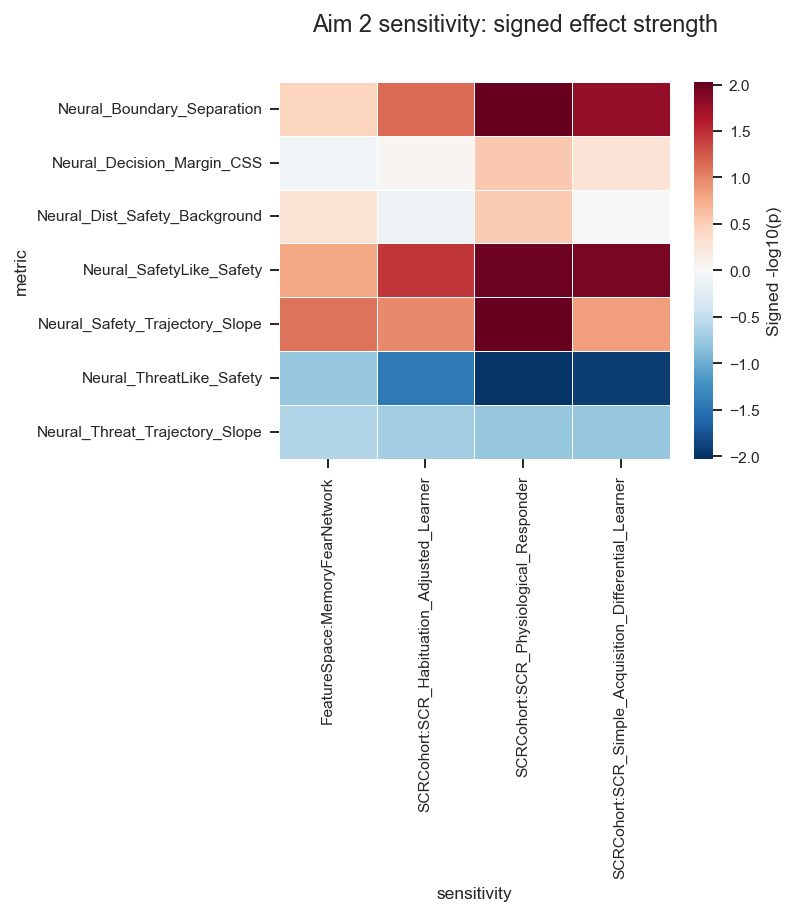

Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim2_sensitivity_forest.png
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim2_sensitivity_forest.pdf


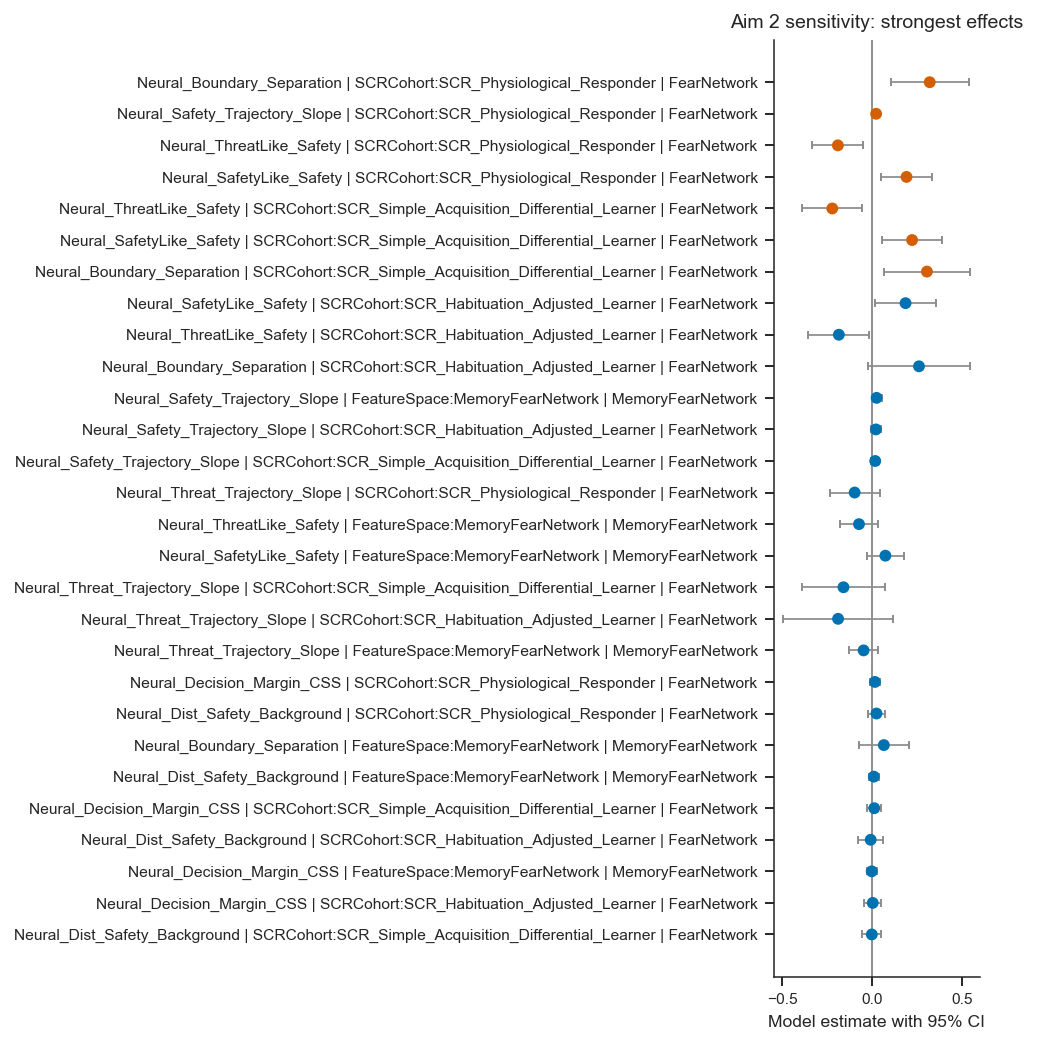

Sensitivity feature spaces in model table: ['FearNetwork', 'MemoryFearNetwork']
Whole-brain/Schaefer sensitivity was not run or not available. This is expected for the current no-wholebrain workflow.


In [17]:
aim2_sens = render_sensitivity_block('Aim 2', 'Aim2', label_fields=['metric', 'sensitivity', 'feature_space'], filename_prefix='aim2')
if sensitivity_df.empty:
    print('No alternative-mask or alternative-feature-space sensitivity model table is available yet.')
elif 'feature_space' in sensitivity_df.columns:
    sensitivity_feature_spaces = sorted(sensitivity_df['feature_space'].dropna().astype(str).unique())
    print(f'Sensitivity feature spaces in model table: {sensitivity_feature_spaces}')
    has_wholebrain_sensitivity = any(fs.lower() in {'schaefer', 'wholebrain', 'wholebrain_schaefer', 'wholebrainparcellation'} for fs in sensitivity_feature_spaces)
    if not has_wholebrain_sensitivity:
        print('Whole-brain/Schaefer sensitivity was not run or not available. This is expected for the current no-wholebrain workflow.')


## Aim 3: Clinical Relevance Under Placebo

Primary test first: within SAD-placebo and HC-placebo participants separately, z-scored anxiety symptoms are modeled as a function of z-scored neural metrics plus available covariates. Clinical-score outliers and neural-metric outliers are removed using the FearNetwork Stage-29 z-score rule.

Clinical endpoints follow `PROJECT_CONTEXT.md`: `dass_anxiety` and `lsas_total` are primary. `lsas_fear` and `lsas_avoid` are secondary support/contextual decomposition of LSAS and cannot carry primary Aim 3 claims. Multiple correction is applied within each placebo diagnostic group across the prespecified clinical-neural tests; the narrower `Group * clinical_score` q-value is retained as a descriptive column, not the primary q-value. Drug condition is not included in Aim 3.


**Aim 3 clinical endpoint hierarchy:**

,clinical_score,order,role,family,label
0,dass_anxiety,1,primary,general_anxiety,DASS anxiety
1,lsas_total,2,primary,social_anxiety_total,LSAS total
2,lsas_fear,3,support_contextual_only,social_anxiety_subscale,LSAS fear
3,lsas_avoid,4,support_contextual_only,social_anxiety_subscale,LSAS avoidance


**Aim 3 FDR families:** p-values are corrected within each diagnostic group.

,correction_family,n_tests
0,HC,28
1,SAD,28


**Descriptive Aim 3 clinical-score families:** retained for transparent comparison with score-specific summaries.

...

**Aim 3 primary clinical scores: `dass_anxiety` and `lsas_total`.**

,analysis,feature_space,session,Group,metric,metric_z,clinical_score,clinical_score_z,term,estimate,ci_low,ci_high,p,q,q_within_group,q_within_group_clinical_score,correction_family,aim3_clinical_score_family,n,n_clinical_outliers_removed,n_metric_outliers_removed,r2,status,formula
52,Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS,FearNetwork,Placebo,HC,Neural_Boundary_Separation,z_Neural_Boundary_Separation,dass_anxiety,z_dass_anxiety,Q('z_Neural_Boundary_Separation'),0.505875,0.119959,0.891791,0.012444,0.273767,0.273767,0.087111,HC,HC | dass_anxiety,27,1,0,0.251825,ok,Q('z_dass_anxiety') ~ Q('z_Neural_Boundary_Sep...
54,Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS,FearNetwork,Placebo,HC,Neural_Safety_Trajectory_Slope,z_Neural_Safety_Trajectory_Slope,dass_anxiety,z_dass_anxiety,Q('z_Neural_Safety_Trajectory_Slope'),-0.476273,-0.927187,-0.025359,0.039374,0.273767,0.273767,0.114070,HC,HC | dass_anxiety,26,1,1,0.184812,ok,Q('z_dass_anxiety') ~ Q('z_Neural_Safety_Traje...
51,Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS,FearNetwork,Placebo,HC,Neural_ThreatLike_Safety,z_Neural_ThreatLike_Safety,dass_anxiety,z_dass_anxiety,Q('z_Neural_ThreatLike_Safety'),-0.448411,-0.894441,-0.002380,0.048887,0.273767,0.273767,0.114070,HC,HC | dass_anxiety,27,1,0,0.168914,ok,Q('z_dass_anxiety') ~ Q('z_Neural_ThreatLike_S...
50,Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS,FearNetwork,Placebo,HC,Neural_Dist_Threat_Safety,z_Neural_Dist_Threat_Safety,dass_anxiety,z_dass_anxiety,Q('z_Neural_Dist_Threat_Safety'),0.386111,-0.027531,0.799752,0.065841,0.307258,0.307258,0.115222,HC,HC | dass_anxiety,26,1,1,0.153561,ok,Q('z_dass_anxiety') ~ Q('z_Neural_Dist_Threat_...
5,Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS,FearNetwork,Placebo,SAD,Neural_Safety_Trajectory_Slope,z_Neural_Safety_Trajectory_Slope,lsas_total,z_lsas_total,Q('z_Neural_Safety_Trajectory_Slope'),0.461676,-0.036657,0.960009,0.067390,0.651140,0.651140,0.471731,SAD,SAD | lsas_total,22,0,1,0.221052,ok,Q('z_lsas_total') ~ Q('z_Neural_Safety_Traject...
24,Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS,FearNetwork,Placebo,SAD,Neural_Boundary_Separation,z_Neural_Boundary_Separation,dass_anxiety,z_dass_anxiety,Q('z_Neural_Boundary_Separation'),0.378550,-0.069915,0.827015,0.093335,0.651140,0.651140,0.650182,SAD,SAD | dass_anxiety,23,0,0,0.227902,ok,Q('z_dass_anxiety') ~ Q('z_Neural_Boundary_Sep...
30,Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS,FearNetwork,Placebo,HC,Neural_ThreatLike_Safety,z_Neural_ThreatLike_Safety,lsas_total,z_lsas_total,Q('z_Neural_ThreatLike_Safety'),-0.287762,-0.710630,0.135107,0.172986,0.605451,0.605451,0.807426,HC,HC | lsas_total,28,0,0,0.121246,ok,Q('z_lsas_total') ~ Q('z_Neural_ThreatLike_Saf...
23,Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS,FearNetwork,Placebo,SAD,Neural_ThreatLike_Safety,z_Neural_ThreatLike_Safety,dass_anxiety,z_dass_anxiety,Q('z_Neural_ThreatLike_Safety'),-0.292729,-0.759004,0.173546,0.204488,0.651140,0.651140,0.650182,SAD,SAD | dass_anxiety,23,0,0,0.175947,ok,Q('z_dass_anxiety') ~ Q('z_Neural_ThreatLike_S...
25,Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS,FearNetwork,Placebo,SAD,Neural_Decision_Margin_CSS,z_Neural_Decision_Margin_CSS,dass_anxiety,z_dass_anxiety,Q('z_Neural_Decision_Margin_CSS'),-0.237477,-0.683157,0.208202,0.278649,0.651140,0.651140,0.650182,SAD,SAD | dass_anxiety,23,0,0,0.156293,ok,Q('z_dass_anxiety') ~ Q('z_Neural_Decision_Mar...
2,Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS,FearNetwork,Placebo,SAD,Neural_ThreatLike_Safety,z_Neural_ThreatLike_Safety,lsas_total,z_lsas_total,Q('z_Neural_ThreatLike_Safety'),0.256764,-0.226013,0.739542,0.279521,0.651140,0.651140,0.589845,SAD,SAD | lsas_total,23,0,0,0.116583,ok,Q('z_lsas_total') ~ Q('z_Neural_ThreatLike_Saf...


**Aim 3 support/contextual only clinical scores: `lsas_fear` and `lsas_avoid`.**

,analysis,feature_space,session,Group,metric,metric_z,clinical_score,clinical_score_z,term,estimate,ci_low,ci_high,p,q,q_within_group,q_within_group_clinical_score,correction_family,aim3_clinical_score_family,n,n_clinical_outliers_removed,n_metric_outliers_removed,r2,status,formula
12,Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS,FearNetwork,Placebo,SAD,Neural_Safety_Trajectory_Slope,z_Neural_Safety_Trajectory_Slope,lsas_fear,z_lsas_fear,Q('z_Neural_Safety_Trajectory_Slope'),0.553775,0.069087,1.038464,0.027405,0.651140,0.651140,0.191836,SAD,SAD | lsas_fear,22,0,1,0.251166,ok,Q('z_lsas_fear') ~ Q('z_Neural_Safety_Trajecto...
37,Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS,FearNetwork,Placebo,HC,Neural_ThreatLike_Safety,z_Neural_ThreatLike_Safety,lsas_fear,z_lsas_fear,Q('z_Neural_ThreatLike_Safety'),-0.426677,-0.836308,-0.017046,0.041863,0.273767,0.273767,0.153028,HC,HC | lsas_fear,28,0,0,0.165110,ok,Q('z_lsas_fear') ~ Q('z_Neural_ThreatLike_Safe...
38,Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS,FearNetwork,Placebo,HC,Neural_Boundary_Separation,z_Neural_Boundary_Separation,lsas_fear,z_lsas_fear,Q('z_Neural_Boundary_Separation'),0.404871,0.012365,0.797376,0.043722,0.273767,0.273767,0.153028,HC,HC | lsas_fear,28,0,0,0.162498,ok,Q('z_lsas_fear') ~ Q('z_Neural_Boundary_Separa...
40,Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS,FearNetwork,Placebo,HC,Neural_Safety_Trajectory_Slope,z_Neural_Safety_Trajectory_Slope,lsas_fear,z_lsas_fear,Q('z_Neural_Safety_Trajectory_Slope'),-0.348504,-0.797701,0.100692,0.122150,0.488601,0.488601,0.285017,HC,HC | lsas_fear,27,0,1,0.105756,ok,Q('z_lsas_fear') ~ Q('z_Neural_Safety_Trajecto...
44,Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS,FearNetwork,Placebo,HC,Neural_ThreatLike_Safety,z_Neural_ThreatLike_Safety,lsas_avoid,z_lsas_avoid,Q('z_Neural_ThreatLike_Safety'),-0.265992,-0.716991,0.185006,0.234804,0.730500,0.730500,0.692330,HC,HC | lsas_avoid,27,1,0,0.089995,ok,Q('z_lsas_avoid') ~ Q('z_Neural_ThreatLike_Saf...
19,Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS,FearNetwork,Placebo,SAD,Neural_Safety_Trajectory_Slope,z_Neural_Safety_Trajectory_Slope,lsas_avoid,z_lsas_avoid,Q('z_Neural_Safety_Trajectory_Slope'),0.293258,-0.222241,0.808756,0.247528,0.651140,0.651140,0.678717,SAD,SAD | lsas_avoid,22,0,1,0.171023,ok,Q('z_lsas_avoid') ~ Q('z_Neural_Safety_Traject...
7,Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS,FearNetwork,Placebo,SAD,Neural_Dist_Safety_Background,z_Neural_Dist_Safety_Background,lsas_fear,z_lsas_fear,Q('z_Neural_Dist_Safety_Background'),0.290082,-0.227140,0.807303,0.254954,0.651140,0.651140,0.472438,SAD,SAD | lsas_fear,23,0,0,0.093424,ok,Q('z_lsas_fear') ~ Q('z_Neural_Dist_Safety_Bac...
48,Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS,FearNetwork,Placebo,HC,Neural_Threat_Trajectory_Slope,z_Neural_Threat_Trajectory_Slope,lsas_avoid,z_lsas_avoid,Q('z_Neural_Threat_Trajectory_Slope'),0.243970,-0.201249,0.689188,0.268002,0.750406,0.750406,0.692330,HC,HC | lsas_avoid,26,1,1,0.107345,ok,Q('z_lsas_avoid') ~ Q('z_Neural_Threat_Traject...
9,Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS,FearNetwork,Placebo,SAD,Neural_ThreatLike_Safety,z_Neural_ThreatLike_Safety,lsas_fear,z_lsas_fear,Q('z_Neural_ThreatLike_Safety'),0.265642,-0.224522,0.755806,0.270776,0.651140,0.651140,0.472438,SAD,SAD | lsas_fear,23,0,0,0.089343,ok,Q('z_lsas_fear') ~ Q('z_Neural_ThreatLike_Safe...
17,Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS,FearNetwork,Placebo,SAD,Neural_Boundary_Separation,z_Neural_Boundary_Separation,lsas_avoid,z_lsas_avoid,Q('z_Neural_Boundary_Separation'),-0.247636,-0.723502,0.228229,0.289692,0.651140,0.651140,0.678717,SAD,SAD | lsas_avoid,23,0,0,0.130670,ok,Q('z_lsas_avoid') ~ Q('z_Neural_Boundary_Separ...


Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim3_primary_clinical_heatmap.png
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim3_primary_clinical_heatmap.pdf


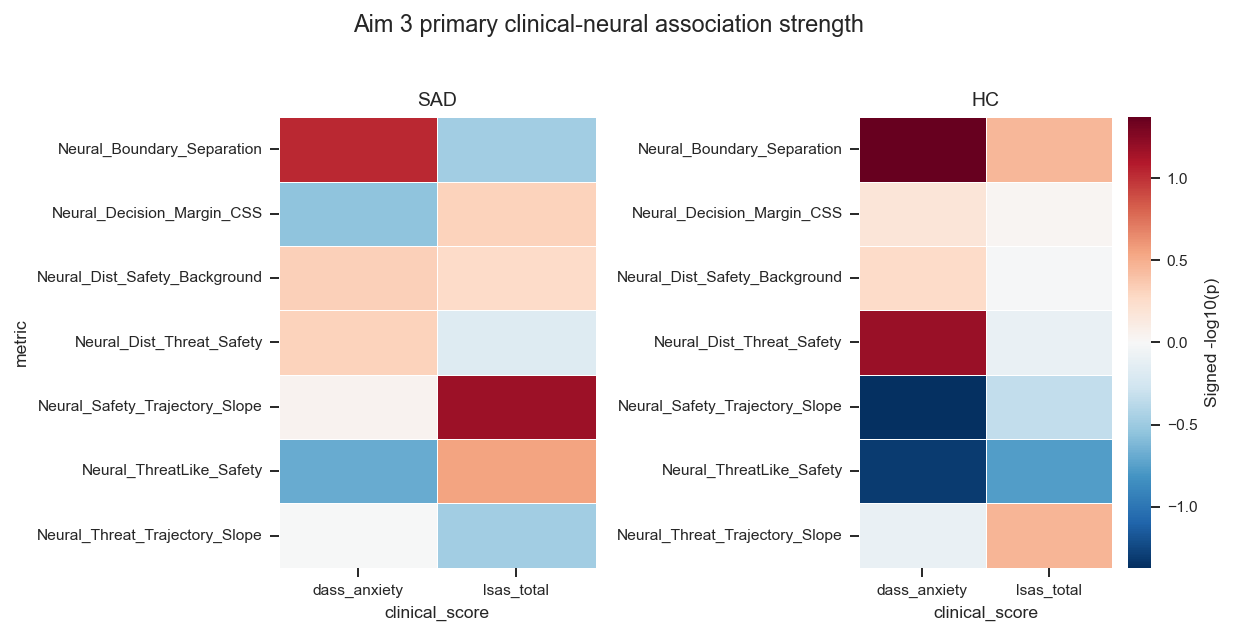

Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim3_primary_clinical_forest.png
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim3_primary_clinical_forest.pdf


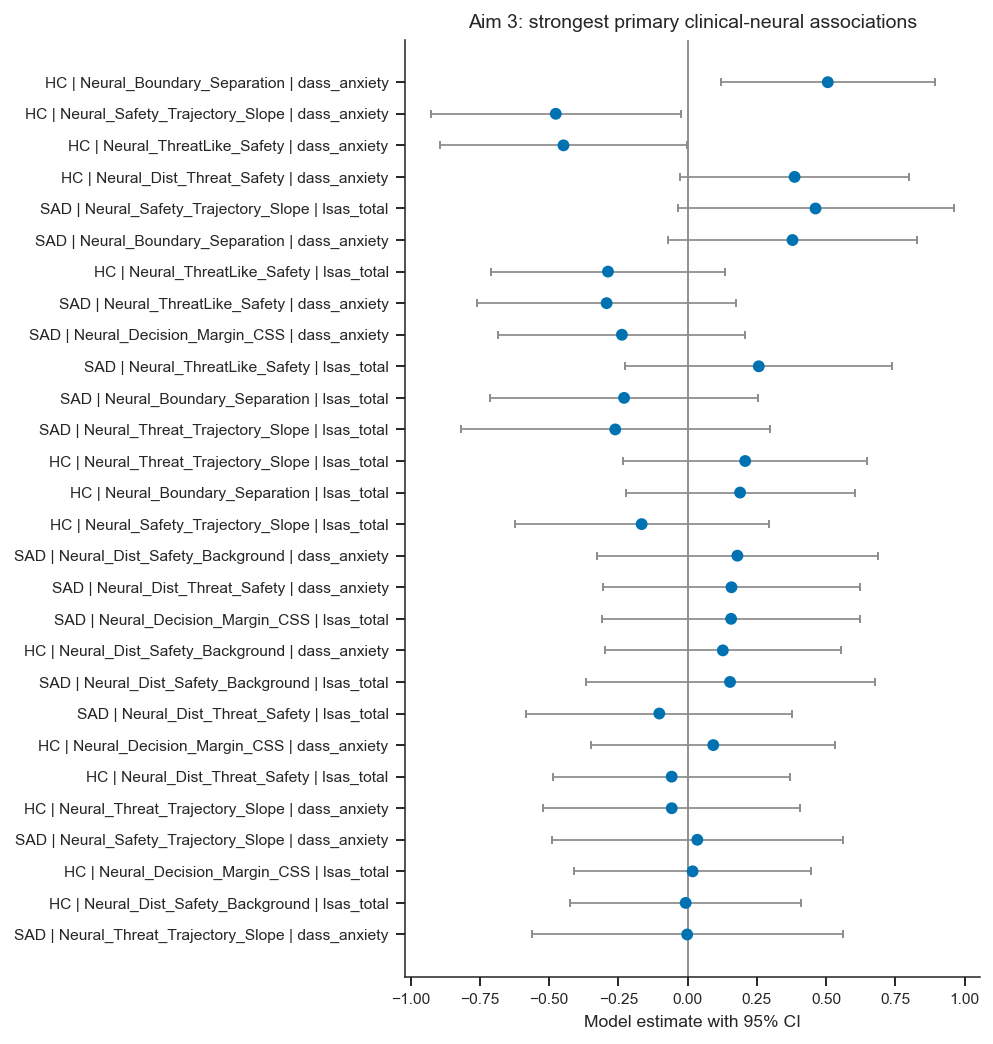

Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim3_support_contextual_clinical_heatmap.png
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim3_support_contextual_clinical_heatmap.pdf


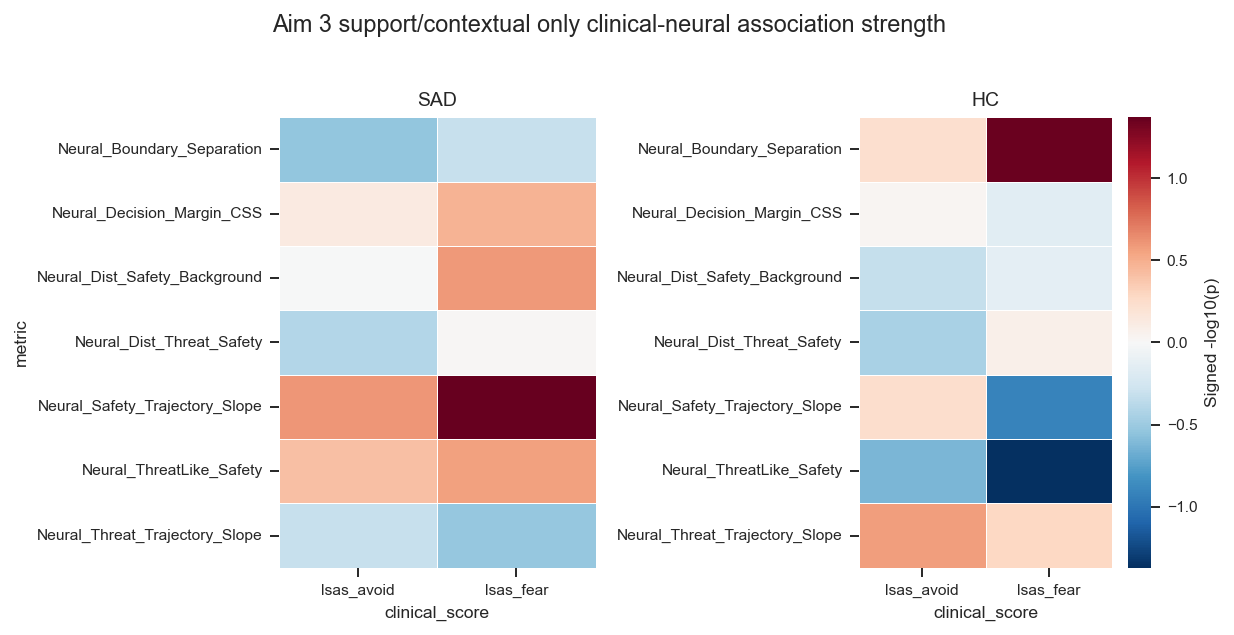

In [18]:
clinical_hierarchy_df = pd.DataFrame([
    {'clinical_score': score, **details}
    for score, details in CLINICAL_HIERARCHY.items()
]).sort_values('order')
display(Markdown('**Aim 3 clinical endpoint hierarchy:**'))
display(clinical_hierarchy_df)

if not aim3_df.empty and 'clinical_score' in aim3_df.columns:
    aim3_primary_scores = aim3_df[aim3_df['clinical_score'].isin(PRIMARY_CLINICAL)].copy()
    aim3_support_scores = aim3_df[aim3_df['clinical_score'].isin(SECONDARY_CLINICAL)].copy()
else:
    aim3_primary_scores = pd.DataFrame()
    aim3_support_scores = pd.DataFrame()

if not manuscript_primary_df.empty:
    aim3_manuscript = manuscript_primary_df[manuscript_primary_df.get('aim', pd.Series(index=manuscript_primary_df.index, dtype=object)).eq('Aim 3')].copy()
    if not aim3_manuscript.empty:
        display(Markdown('**Manuscript-ready Aim 3 primary rows:**'))
        display(hierarchy_result_table(aim3_manuscript, n=80))

if not aim3_df.empty:
    if 'correction_family' in aim3_df.columns:
        display(Markdown('**Aim 3 FDR families:** p-values are corrected within each diagnostic group.'))
        display(aim3_df.groupby('correction_family', dropna=False).size().rename('n_tests').reset_index())
    if 'aim3_clinical_score_family' in aim3_df.columns:
        display(Markdown('**Descriptive Aim 3 clinical-score families:** retained for transparent comparison with score-specific summaries.'))
        display(aim3_df.groupby('aim3_clinical_score_family', dropna=False).size().rename('n_tests').reset_index())
    display(Markdown('**Aim 3 primary clinical scores: `dass_anxiety` and `lsas_total`.**'))
    display(tidy_result_table(aim3_primary_scores, n=120))
    display(Markdown('**Aim 3 support/contextual only clinical scores: `lsas_fear` and `lsas_avoid`.**'))
    display(tidy_result_table(aim3_support_scores, n=80))
else:
    print('Aim 3 model table is not available yet.')
show_figure_once(signed_logp_heatmap(aim3_primary_scores, 'metric', 'clinical_score', 'Aim 3 primary clinical-neural association strength', group_col='Group', filename='aim3_primary_clinical_heatmap'))
show_figure_once(plot_forest(aim3_primary_scores, 'Aim 3: strongest primary clinical-neural associations', top_n=35, label_fields=['Group', 'metric', 'clinical_score'], filename='aim3_primary_clinical_forest'))
if not aim3_support_scores.empty:
    show_figure_once(signed_logp_heatmap(aim3_support_scores, 'metric', 'clinical_score', 'Aim 3 support/contextual only clinical-neural association strength', group_col='Group', filename='aim3_support_contextual_clinical_heatmap'))


### Aim 3 Sensitivity: Clinical Model Robustness

These checks are reserved for placebo-session clinical-neural models with alternative outlier handling, covariates, or feature spaces when available.


In [19]:
render_sensitivity_block('Aim 3', 'Aim3', label_fields=['Group', 'metric', 'clinical_score', 'sensitivity', 'feature_space'], filename_prefix='aim3')


No Aim 3 sensitivity model table found yet.


## Aim 4: Physiological Convergence With SCR Under Placebo

Primary test first: SCR learning indices are modeled separately within SAD-placebo and HC-placebo participants as a function of neural metrics and covariates. Drug condition is not included because Aim 4 is a placebo-session physiological convergence analysis. Multiple correction is applied within each diagnostic group across the prespecified SCR-neural tests.

The convergence matrix below is the manuscript-facing view: primary neural metrics are crossed with primary SCR indices and interpreted as convergence, dissociation, or null alignment based on effect size and confidence interval, not p-values alone.


Aim 4 convergence matrix artifact is not available yet. Run scripts/export_mvpa_l2_manuscript_artifacts.py after the primary models.


**Aim 4 FDR families:** p-values are corrected within each diagnostic group.

,correction_family,n_tests
0,HC,28
1,SAD,28


,analysis,feature_space,session,Group,metric,scr_index,term,estimate,ci_low,ci_high,p,q,q_within_group,correction_family,n,r2,status,formula
13,Aim4_SCR_Convergence_Groupwise_Placebo,FearNetwork,Placebo,SAD,Neural_Threat_Trajectory_Slope,SCR_ThreatMinusSafety,Q('Neural_Threat_Trajectory_Slope'),-0.190249,-0.315749,-0.064748,0.005131,0.143659,0.143659,SAD,22,0.451893,ok,Q('SCR_ThreatMinusSafety') ~ Q('Neural_Threat_...
4,Aim4_SCR_Convergence_Groupwise_Placebo,FearNetwork,Placebo,SAD,Neural_Decision_Margin_CSS,SCR_SafetyMinusBackground,Q('Neural_Decision_Margin_CSS'),0.218028,0.025416,0.410641,0.028683,0.388212,0.388212,SAD,22,0.318133,ok,Q('SCR_SafetyMinusBackground') ~ Q('Neural_Dec...
18,Aim4_SCR_Convergence_Groupwise_Placebo,FearNetwork,Placebo,SAD,Neural_Decision_Margin_CSS,SCR_Safety_Trajectory_Slope,Q('Neural_Decision_Margin_CSS'),0.039387,0.001673,0.077102,0.041594,0.388212,0.388212,SAD,22,0.251930,ok,Q('SCR_Safety_Trajectory_Slope') ~ Q('Neural_D...
1,Aim4_SCR_Convergence_Groupwise_Placebo,FearNetwork,Placebo,SAD,Neural_Dist_Threat_Safety,SCR_SafetyMinusBackground,Q('Neural_Dist_Threat_Safety'),0.066584,-0.005593,0.138762,0.068457,0.479200,0.479200,SAD,22,0.258607,ok,Q('SCR_SafetyMinusBackground') ~ Q('Neural_Dis...
44,Aim4_SCR_Convergence_Groupwise_Placebo,FearNetwork,Placebo,HC,Neural_ThreatLike_Safety,SCR_Safety_Trajectory_Slope,Q('Neural_ThreatLike_Safety'),-0.017173,-0.036751,0.002405,0.082773,0.985201,0.985201,HC,28,0.159474,ok,Q('SCR_Safety_Trajectory_Slope') ~ Q('Neural_T...
27,Aim4_SCR_Convergence_Groupwise_Placebo,FearNetwork,Placebo,SAD,Neural_Threat_Trajectory_Slope,SCR_Threat_Trajectory_Slope,Q('Neural_Threat_Trajectory_Slope'),-0.021805,-0.052792,0.009182,0.156598,0.876949,0.876949,SAD,22,0.299210,ok,Q('SCR_Threat_Trajectory_Slope') ~ Q('Neural_T...
49,Aim4_SCR_Convergence_Groupwise_Placebo,FearNetwork,Placebo,HC,Neural_Dist_Safety_Background,SCR_Threat_Trajectory_Slope,Q('Neural_Dist_Safety_Background'),0.035116,-0.015198,0.085430,0.162652,0.985201,0.985201,HC,28,0.242102,ok,Q('SCR_Threat_Trajectory_Slope') ~ Q('Neural_D...
54,Aim4_SCR_Convergence_Groupwise_Placebo,FearNetwork,Placebo,HC,Neural_Safety_Trajectory_Slope,SCR_Threat_Trajectory_Slope,Q('Neural_Safety_Trajectory_Slope'),-0.056777,-0.143715,0.030160,0.190279,0.985201,0.985201,HC,28,0.234524,ok,Q('SCR_Threat_Trajectory_Slope') ~ Q('Neural_S...
30,Aim4_SCR_Convergence_Groupwise_Placebo,FearNetwork,Placebo,HC,Neural_ThreatLike_Safety,SCR_SafetyMinusBackground,Q('Neural_ThreatLike_Safety'),0.051751,-0.033770,0.137272,0.223739,0.985201,0.985201,HC,28,0.149955,ok,Q('SCR_SafetyMinusBackground') ~ Q('Neural_Thr...
37,Aim4_SCR_Convergence_Groupwise_Placebo,FearNetwork,Placebo,HC,Neural_ThreatLike_Safety,SCR_ThreatMinusSafety,Q('Neural_ThreatLike_Safety'),-0.028838,-0.077081,0.019404,0.229245,0.985201,0.985201,HC,28,0.098364,ok,Q('SCR_ThreatMinusSafety') ~ Q('Neural_ThreatL...


Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim4_scr_heatmap.png
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim4_scr_heatmap.pdf


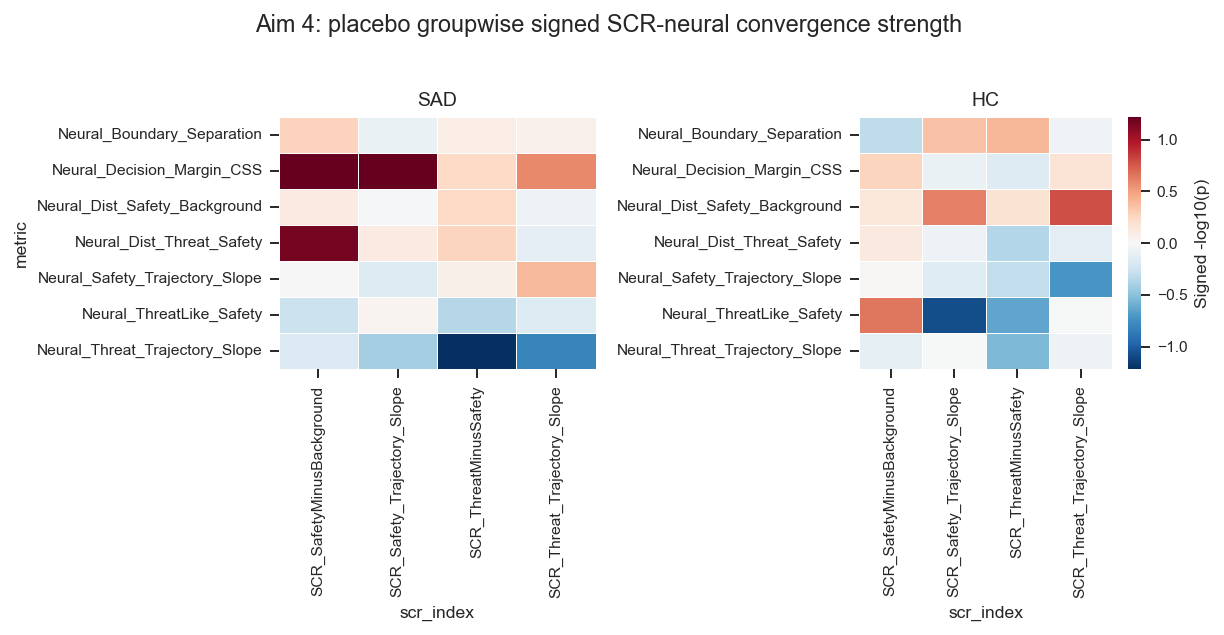

Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim4_scr_forest.png
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim4_scr_forest.pdf


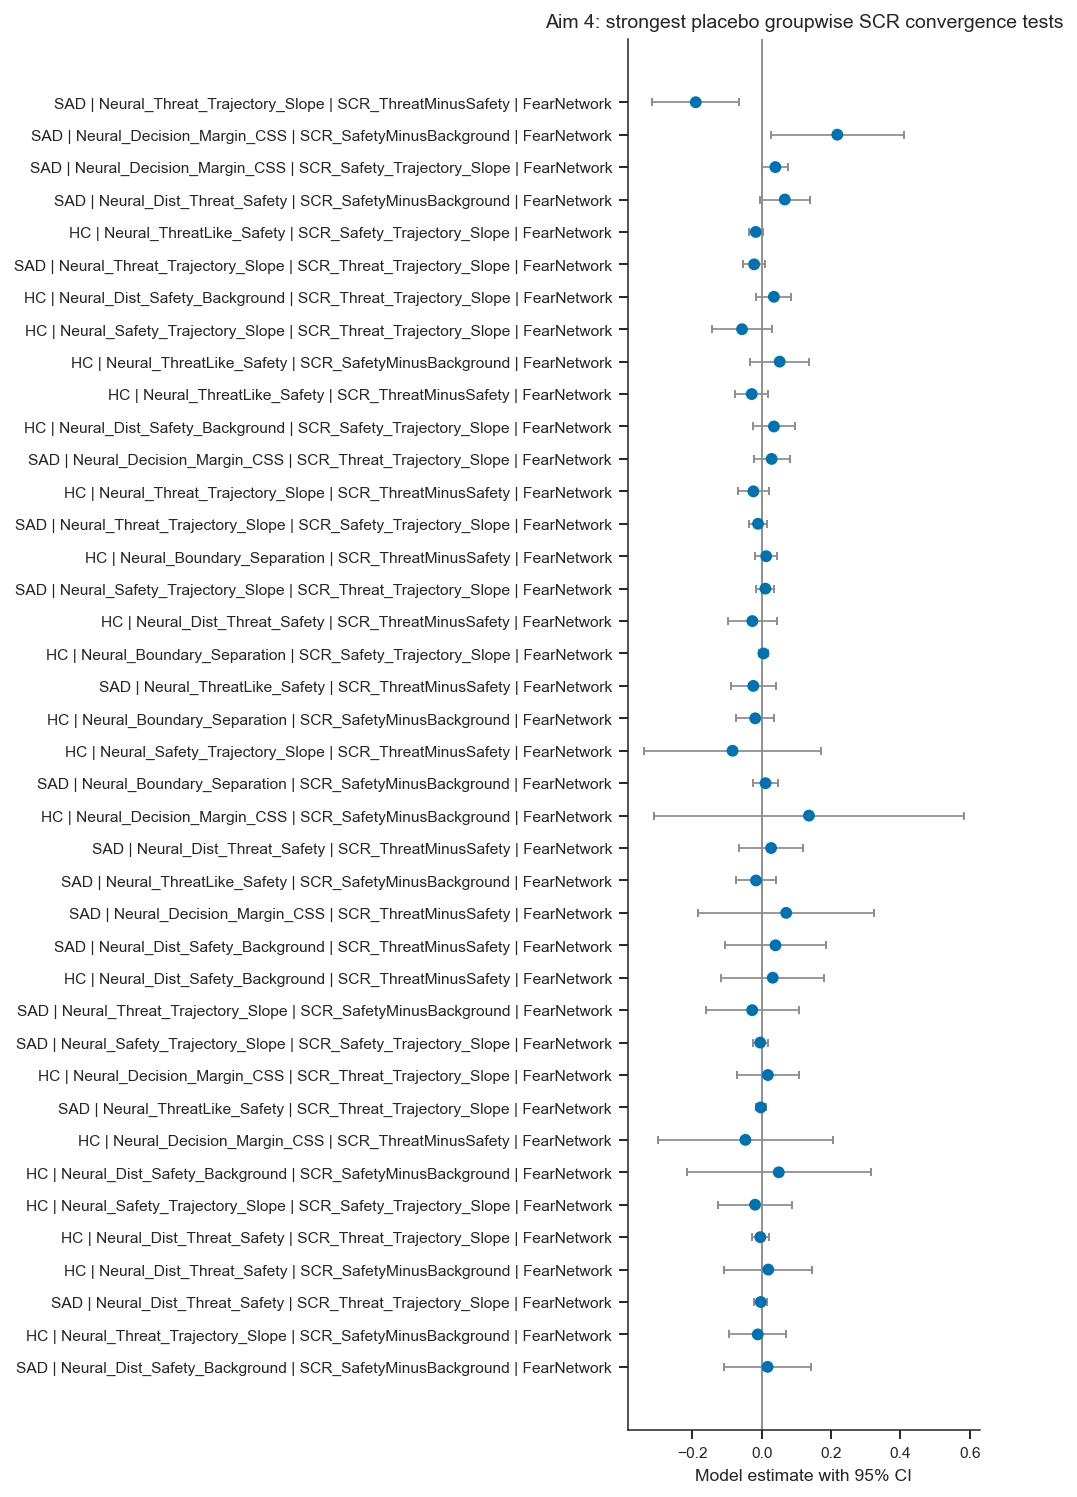

In [20]:
if not aim4_convergence_wide_df.empty:
    display(Markdown('**Manuscript-ready Aim 4 convergence matrix:** cells show estimate, 95% CI, and q-value.'))
    display(aim4_convergence_wide_df)
elif PATHS['aim4_convergence_md'].exists():
    display(Markdown(PATHS['aim4_convergence_md'].read_text()))
else:
    print('Aim 4 convergence matrix artifact is not available yet. Run scripts/export_mvpa_l2_manuscript_artifacts.py after the primary models.')

if not aim4_df.empty:
    if 'correction_family' in aim4_df.columns:
        display(Markdown('**Aim 4 FDR families:** p-values are corrected within each diagnostic group.'))
        display(aim4_df.groupby('correction_family', dropna=False).size().rename('n_tests').reset_index())
    display(tidy_result_table(aim4_df, n=120))
else:
    print('Aim 4 model table is not available yet.')
show_figure_once(signed_logp_heatmap(aim4_df, 'metric', 'scr_index', 'Aim 4: placebo groupwise signed SCR-neural convergence strength', group_col='Group', filename='aim4_scr_heatmap'))
show_figure_once(plot_forest(aim4_df, 'Aim 4: strongest placebo groupwise SCR convergence tests', top_n=40, label_fields=['Group', 'metric', 'scr_index', 'feature_space'], filename='aim4_scr_forest'))


### Aim 4 Sensitivity: SCR Cohorts And Model Robustness

SCR responder/learner cohorts are sensitivity populations, not replacement primary analyses. They test whether placebo-session SCR-neural convergence is stable among participants with measurable peripheral learning.


,analysis,sensitivity,feature_space,metric,scr_index,term,estimate,ci_low,ci_high,p,q,n,r2,status,formula
170,Sensitivity_Aim4_SCR,SCRCohort:SCR_Late_Phase_Sensitivity_Learner,FearNetwork,Neural_SafetyLike_Safety,SCR_SafetyMinusBackground,Q('Neural_SafetyLike_Safety'),0.120966,0.050649,0.191283,0.011982,0.167746,8,0.930514,ok,Q('SCR_SafetyMinusBackground') ~ Q('Neural_Saf...
169,Sensitivity_Aim4_SCR,SCRCohort:SCR_Late_Phase_Sensitivity_Learner,FearNetwork,Neural_ThreatLike_Safety,SCR_SafetyMinusBackground,Q('Neural_ThreatLike_Safety'),-0.120966,-0.191283,-0.050649,0.011982,0.167746,8,0.930514,ok,Q('SCR_SafetyMinusBackground') ~ Q('Neural_Thr...
188,Sensitivity_Aim4_SCR,SCRCohort:SCR_Late_Phase_Sensitivity_Learner,FearNetwork,Neural_Threat_Trajectory_Slope,SCR_Safety_Trajectory_Slope,Q('Neural_Threat_Trajectory_Slope'),-0.006660,-0.012874,-0.000445,0.042134,0.239687,8,0.827143,ok,Q('SCR_Safety_Trajectory_Slope') ~ Q('Neural_T...
191,Sensitivity_Aim4_SCR,SCRCohort:SCR_Late_Phase_Sensitivity_Learner,FearNetwork,Neural_SafetyLike_Safety,SCR_Threat_Trajectory_Slope,Q('Neural_SafetyLike_Safety'),-0.078425,-0.152067,-0.004783,0.042801,0.239687,8,0.830357,ok,Q('SCR_Threat_Trajectory_Slope') ~ Q('Neural_S...
190,Sensitivity_Aim4_SCR,SCRCohort:SCR_Late_Phase_Sensitivity_Learner,FearNetwork,Neural_ThreatLike_Safety,SCR_Threat_Trajectory_Slope,Q('Neural_ThreatLike_Safety'),0.078425,0.004783,0.152067,0.042801,0.239687,8,0.830357,ok,Q('SCR_Threat_Trajectory_Slope') ~ Q('Neural_T...
20,Sensitivity_Aim4_SCR,FeatureSpace:MemoryFearNetwork,MemoryFearNetwork,Neural_Threat_Trajectory_Slope,SCR_ThreatMinusSafety,Q('Neural_Threat_Trajectory_Slope'),-0.046785,-0.092652,-0.000917,0.045773,0.675894,50,0.180759,ok,Q('SCR_ThreatMinusSafety') ~ Q('Neural_Threat_...
156,Sensitivity_Aim4_SCR,SCRCohort:SCR_Habituation_Adjusted_Learner,FearNetwork,Neural_SafetyLike_Safety,SCR_Threat_Trajectory_Slope,Q('Neural_SafetyLike_Safety'),0.031402,-0.000396,0.063201,0.052405,0.534290,15,0.502818,ok,Q('SCR_Threat_Trajectory_Slope') ~ Q('Neural_S...
155,Sensitivity_Aim4_SCR,SCRCohort:SCR_Habituation_Adjusted_Learner,FearNetwork,Neural_ThreatLike_Safety,SCR_Threat_Trajectory_Slope,Q('Neural_ThreatLike_Safety'),-0.031402,-0.063201,0.000396,0.052405,0.534290,15,0.502818,ok,Q('SCR_Threat_Trajectory_Slope') ~ Q('Neural_T...
171,Sensitivity_Aim4_SCR,SCRCohort:SCR_Late_Phase_Sensitivity_Learner,FearNetwork,Neural_Boundary_Separation,SCR_SafetyMinusBackground,Q('Neural_Boundary_Separation'),0.102999,-0.016948,0.222946,0.071772,0.306362,8,0.781131,ok,Q('SCR_SafetyMinusBackground') ~ Q('Neural_Bou...
53,Sensitivity_Aim4_SCR,SCRCohort:SCR_Physiological_Responder,FearNetwork,Neural_Decision_Margin_CSS,SCR_SafetyMinusBackground,Q('Neural_Decision_Margin_CSS'),0.346175,-0.038521,0.730871,0.075677,0.961643,30,0.203264,ok,Q('SCR_SafetyMinusBackground') ~ Q('Neural_Dec...


,analysis,sensitivity,feature_space,n_tests
0,Sensitivity_Aim4_SCR,FeatureSpace:MemoryFearNetwork,MemoryFearNetwork,28
1,Sensitivity_Aim4_SCR,SCRCohort:SCR_Habituation_Adjusted_Learner,FearNetwork,28
2,Sensitivity_Aim4_SCR,SCRCohort:SCR_Late_Phase_Sensitivity_Learner,FearNetwork,28
3,Sensitivity_Aim4_SCR,SCRCohort:SCR_Physiological_Responder,FearNetwork,28
4,Sensitivity_Aim4_SCR,SCRCohort:SCR_Simple_Acquisition_Differential_...,FearNetwork,28


/var/folders/63/3j_hstl96w58qx1sdw9czhxr0000gn/T/ipykernel_93400/2147339308.py:211: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.tight_layout()


Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim4_sensitivity_signed_heatmap.png
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim4_sensitivity_signed_heatmap.pdf


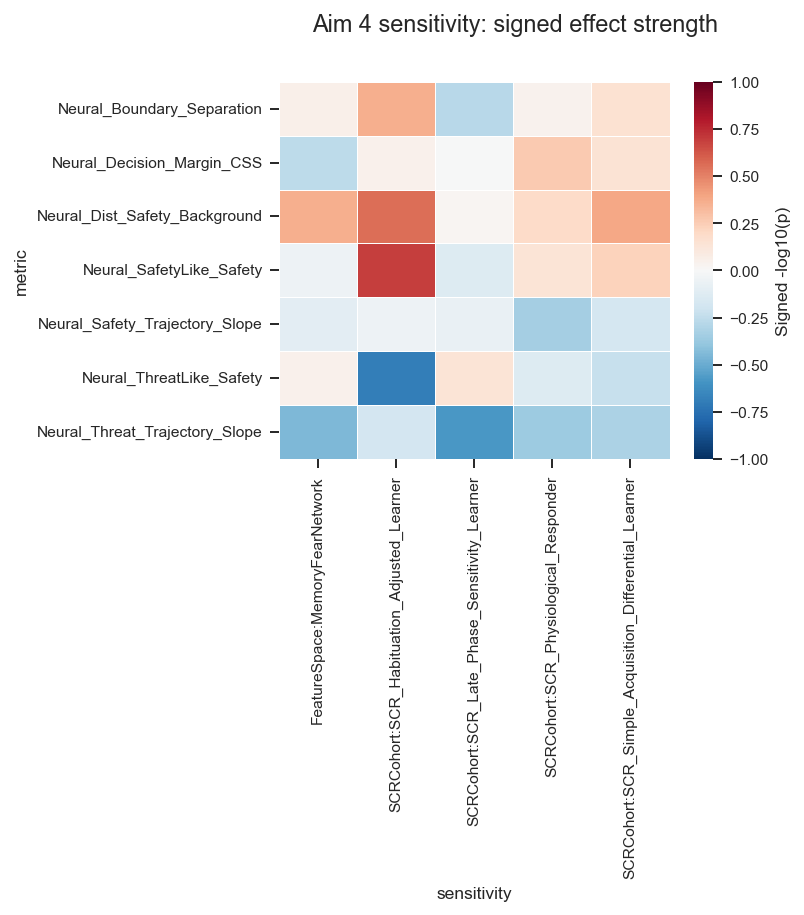

,status,outcome,term,estimate,std_error,t,p,ci_low,ci_high,n,r2,formula,analysis,sensitivity,metric,feature_space,scr_index,q
7,ok,SCR_SafetyMinusBackground,Q('Neural_Dist_Safety_Background'),-0.017740,0.096794,-0.183270,0.855409,-0.212693,0.177214,50,0.051278,Q('SCR_SafetyMinusBackground') ~ Q('Neural_Dis...,Sensitivity_Aim4_SCR,FeatureSpace:MemoryFearNetwork,Neural_Dist_Safety_Background,MemoryFearNetwork,SCR_SafetyMinusBackground,0.887091
8,ok,SCR_SafetyMinusBackground,Q('Neural_ThreatLike_Safety'),-0.013902,0.025423,-0.546822,0.587202,-0.065108,0.037303,50,0.056837,Q('SCR_SafetyMinusBackground') ~ Q('Neural_Thr...,Sensitivity_Aim4_SCR,FeatureSpace:MemoryFearNetwork,Neural_ThreatLike_Safety,MemoryFearNetwork,SCR_SafetyMinusBackground,0.887091
9,ok,SCR_SafetyMinusBackground,Q('Neural_SafetyLike_Safety'),0.013902,0.025423,0.546822,0.587202,-0.037303,0.065108,50,0.056837,Q('SCR_SafetyMinusBackground') ~ Q('Neural_Saf...,Sensitivity_Aim4_SCR,FeatureSpace:MemoryFearNetwork,Neural_SafetyLike_Safety,MemoryFearNetwork,SCR_SafetyMinusBackground,0.887091
10,ok,SCR_SafetyMinusBackground,Q('Neural_Boundary_Separation'),0.007940,0.018850,0.421218,0.675601,-0.030026,0.045907,50,0.054299,Q('SCR_SafetyMinusBackground') ~ Q('Neural_Bou...,Sensitivity_Aim4_SCR,FeatureSpace:MemoryFearNetwork,Neural_Boundary_Separation,MemoryFearNetwork,SCR_SafetyMinusBackground,0.887091
11,ok,SCR_SafetyMinusBackground,Q('Neural_Decision_Margin_CSS'),0.166790,0.092536,1.802444,0.078176,-0.019586,0.353167,50,0.114499,Q('SCR_SafetyMinusBackground') ~ Q('Neural_Dec...,Sensitivity_Aim4_SCR,FeatureSpace:MemoryFearNetwork,Neural_Decision_Margin_CSS,MemoryFearNetwork,SCR_SafetyMinusBackground,0.675894
12,ok,SCR_SafetyMinusBackground,Q('Neural_Safety_Trajectory_Slope'),-0.087017,0.095725,-0.909024,0.368181,-0.279817,0.105784,50,0.067690,Q('SCR_SafetyMinusBackground') ~ Q('Neural_Saf...,Sensitivity_Aim4_SCR,FeatureSpace:MemoryFearNetwork,Neural_Safety_Trajectory_Slope,MemoryFearNetwork,SCR_SafetyMinusBackground,0.887091
13,ok,SCR_SafetyMinusBackground,Q('Neural_Threat_Trajectory_Slope'),0.009402,0.033132,0.283778,0.777882,-0.057329,0.076133,50,0.052266,Q('SCR_SafetyMinusBackground') ~ Q('Neural_Thr...,Sensitivity_Aim4_SCR,FeatureSpace:MemoryFearNetwork,Neural_Threat_Trajectory_Slope,MemoryFearNetwork,SCR_SafetyMinusBackground,0.887091
14,ok,SCR_ThreatMinusSafety,Q('Neural_Dist_Safety_Background'),0.087541,0.068310,1.281527,0.206573,-0.050042,0.225125,50,0.135475,Q('SCR_ThreatMinusSafety') ~ Q('Neural_Dist_Sa...,Sensitivity_Aim4_SCR,FeatureSpace:MemoryFearNetwork,Neural_Dist_Safety_Background,MemoryFearNetwork,SCR_ThreatMinusSafety,0.887091
15,ok,SCR_ThreatMinusSafety,Q('Neural_ThreatLike_Safety'),-0.007421,0.018287,-0.405798,0.686814,-0.044252,0.029411,50,0.107190,Q('SCR_ThreatMinusSafety') ~ Q('Neural_ThreatL...,Sensitivity_Aim4_SCR,FeatureSpace:MemoryFearNetwork,Neural_ThreatLike_Safety,MemoryFearNetwork,SCR_ThreatMinusSafety,0.887091
16,ok,SCR_ThreatMinusSafety,Q('Neural_SafetyLike_Safety'),0.007421,0.018287,0.405798,0.686814,-0.029411,0.044252,50,0.107190,Q('SCR_ThreatMinusSafety') ~ Q('Neural_SafetyL...,Sensitivity_Aim4_SCR,FeatureSpace:MemoryFearNetwork,Neural_SafetyLike_Safety,MemoryFearNetwork,SCR_ThreatMinusSafety,0.887091


In [21]:
render_sensitivity_block('Aim 4', 'Aim4', label_fields=['Group', 'metric', 'scr_index', 'sensitivity', 'feature_space'], filename_prefix='aim4', show_forest=False)


## Aim 5: Oxytocin Modulation

Primary test first: `neural_metric ~ Group * Drug + covariates`. Aim 5 is the only full placebo/oxytocin model in this notebook. The strongest mechanistic claim is a directional shift of SAD-oxytocin toward the HC-placebo reference on metrics that differ under placebo.


,analysis,feature_space,metric,term,estimate,ci_low,ci_high,p,q,n,r2,status,formula
1,Aim5_Group_x_Drug,FearNetwork,Neural_Dist_Threat_Safety,"C(Group, Treatment(reference='HC'))[T.SAD]:C(D...",-0.010710,-0.088202,0.066782,0.784416,0.849107,102,0.122510,ok,"Q('Neural_Dist_Threat_Safety') ~ C(Group, Trea..."
0,Aim5_Group_x_Drug,FearNetwork,Neural_Dist_Safety_Background,"C(Group, Treatment(reference='HC'))[T.SAD]:C(D...",0.005202,-0.048920,0.059323,0.849107,0.849107,102,0.161058,ok,"Q('Neural_Dist_Safety_Background') ~ C(Group, ..."
2,Aim5_Group_x_Drug,FearNetwork,Neural_ThreatLike_Safety,"C(Group, Treatment(reference='HC'))[T.SAD]:C(D...",NaN,NaN,NaN,NaN,NaN,51,NaN,missing_group_drug_complete_cases,"Q('Neural_ThreatLike_Safety') ~ C(Group, Treat..."
3,Aim5_Group_x_Drug,FearNetwork,Neural_Boundary_Separation,"C(Group, Treatment(reference='HC'))[T.SAD]:C(D...",NaN,NaN,NaN,NaN,NaN,51,NaN,missing_group_drug_complete_cases,"Q('Neural_Boundary_Separation') ~ C(Group, Tre..."
4,Aim5_Group_x_Drug,FearNetwork,Neural_Decision_Margin_CSS,"C(Group, Treatment(reference='HC'))[T.SAD]:C(D...",NaN,NaN,NaN,NaN,NaN,51,NaN,missing_group_drug_complete_cases,"Q('Neural_Decision_Margin_CSS') ~ C(Group, Tre..."
5,Aim5_Group_x_Drug,FearNetwork,Neural_Safety_Trajectory_Slope,"C(Group, Treatment(reference='HC'))[T.SAD]:C(D...",NaN,NaN,NaN,NaN,NaN,51,NaN,missing_group_drug_complete_cases,"Q('Neural_Safety_Trajectory_Slope') ~ C(Group,..."
6,Aim5_Group_x_Drug,FearNetwork,Neural_Threat_Trajectory_Slope,"C(Group, Treatment(reference='HC'))[T.SAD]:C(D...",NaN,NaN,NaN,NaN,NaN,50,NaN,missing_group_drug_complete_cases,"Q('Neural_Threat_Trajectory_Slope') ~ C(Group,..."


**Aim 5 model-status summary**

,status,n_metrics
0,missing_group_drug_complete_cases,5
1,ok,2


**Aim 5 availability diagnostics**

,metric,status,n,metric_cell_counts,complete_case_cell_counts,missing_complete_cells,covariates_used
0,Neural_Dist_Safety_Background,ok,102,HC_Placebo:28;HC_Oxytocin:24;SAD_Placebo:23;SA...,HC_Placebo:28;HC_Oxytocin:24;SAD_Placebo:23;SA...,NaN,"demo_age,Gender"
1,Neural_Dist_Threat_Safety,ok,102,HC_Placebo:28;HC_Oxytocin:24;SAD_Placebo:23;SA...,HC_Placebo:28;HC_Oxytocin:24;SAD_Placebo:23;SA...,NaN,"demo_age,Gender"
2,Neural_ThreatLike_Safety,missing_group_drug_complete_cases,51,HC_Placebo:28;HC_Oxytocin:0;SAD_Placebo:23;SAD...,HC_Placebo:28;HC_Oxytocin:0;SAD_Placebo:23;SAD...,HC_Oxytocin;SAD_Oxytocin,"demo_age,Gender"
3,Neural_Boundary_Separation,missing_group_drug_complete_cases,51,HC_Placebo:28;HC_Oxytocin:0;SAD_Placebo:23;SAD...,HC_Placebo:28;HC_Oxytocin:0;SAD_Placebo:23;SAD...,HC_Oxytocin;SAD_Oxytocin,"demo_age,Gender"
4,Neural_Decision_Margin_CSS,missing_group_drug_complete_cases,51,HC_Placebo:28;HC_Oxytocin:0;SAD_Placebo:23;SAD...,HC_Placebo:28;HC_Oxytocin:0;SAD_Placebo:23;SAD...,HC_Oxytocin;SAD_Oxytocin,"demo_age,Gender"
5,Neural_Safety_Trajectory_Slope,missing_group_drug_complete_cases,51,HC_Placebo:28;HC_Oxytocin:0;SAD_Placebo:23;SAD...,HC_Placebo:28;HC_Oxytocin:0;SAD_Placebo:23;SAD...,HC_Oxytocin;SAD_Oxytocin,"demo_age,Gender"
6,Neural_Threat_Trajectory_Slope,missing_group_drug_complete_cases,50,HC_Placebo:28;HC_Oxytocin:0;SAD_Placebo:22;SAD...,HC_Placebo:28;HC_Oxytocin:0;SAD_Placebo:22;SAD...,HC_Oxytocin;SAD_Oxytocin,"demo_age,Gender"


Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim5_group_drug_forest.png
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim5_group_drug_forest.pdf


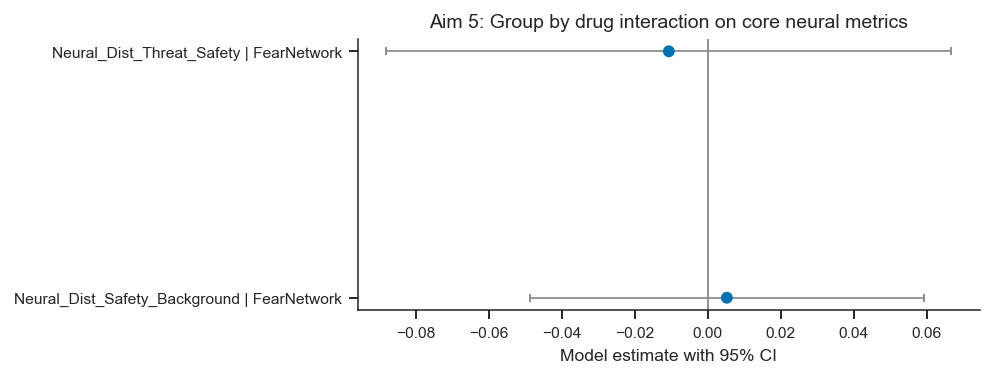

/var/folders/63/3j_hstl96w58qx1sdw9czhxr0000gn/T/ipykernel_93400/2982052667.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='GroupDrug', y=metric, order=order, palette=palette, width=0.55, fliersize=0, linewidth=0.8, ax=ax)
/var/folders/63/3j_hstl96w58qx1sdw9czhxr0000gn/T/ipykernel_93400/2982052667.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='GroupDrug', y=metric, order=order, palette=palette, width=0.55, fliersize=0, linewidth=0.8, ax=ax)


Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim5_group_drug_metric_distributions.png
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim5_group_drug_metric_distributions.pdf


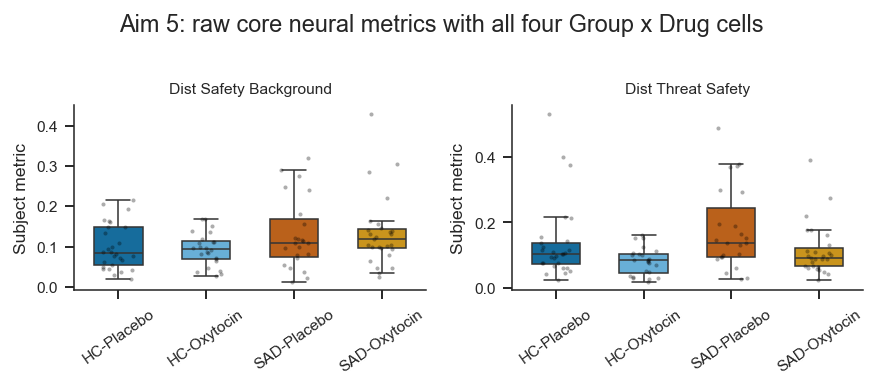

In [22]:
display(tidy_result_table(aim5_df, n=100))

if aim5_df.empty:
    display(Markdown('Aim 5 model output is not available.'))
else:
    if 'status' in aim5_df.columns:
        status_table = aim5_df['status'].fillna('missing').value_counts().rename_axis('status').reset_index(name='n_metrics')
        display(Markdown('**Aim 5 model-status summary**'))
        display(status_table)
    diag_cols = [c for c in ['metric', 'status', 'n', 'metric_cell_counts', 'complete_case_cell_counts', 'missing_complete_cells', 'covariates_used'] if c in aim5_df.columns]
    if diag_cols:
        display(Markdown('**Aim 5 availability diagnostics**'))
        display(aim5_df[diag_cols])
    ok_df = aim5_df[aim5_df.get('status', pd.Series(index=aim5_df.index, dtype=object)).astype(str).eq('ok')].copy()
    ok_df = ok_df[pd.to_numeric(ok_df.get('p', pd.Series(index=ok_df.index, dtype=float)), errors='coerce').notna()]
    if ok_df.empty:
        display(Markdown('No Aim 5 `Group * Drug` interaction was estimable under the planned covariate-adjusted model. The diagnostics above show whether the failure is due to missing oxytocin neural metrics, missing covariates, or both.'))
    else:
        show_figure_once(plot_forest(ok_df, 'Aim 5: Group by drug interaction on core neural metrics', top_n=35, label_fields=['metric', 'feature_space'], filename='aim5_group_drug_forest'))

if not metrics_df.empty and {'Group', 'Drug'}.issubset(metrics_df.columns):
    sub = metrics_df.copy()
    if 'FeatureSpace' in sub.columns:
        sub = sub[sub['FeatureSpace'].astype(str).eq('FearNetwork')]
    raw_available = []
    for metric in [m for m in CORE_METRICS if m in sub.columns]:
        metric_df = sub.dropna(subset=[metric, 'Group', 'Drug']).copy()
        cells = metric_df.groupby(['Group', 'Drug']).size().to_dict()
        required = [('HC', 'Placebo'), ('HC', 'Oxytocin'), ('SAD', 'Placebo'), ('SAD', 'Oxytocin')]
        if all(cells.get(cell, 0) > 0 for cell in required):
            raw_available.append(metric)
    if raw_available:
        n_cols = 2
        n_rows = math.ceil(len(raw_available) / n_cols)
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.4, 2.7 * n_rows), squeeze=False)
        sub = sub.copy()
        sub['GroupDrug'] = sub['Group'].astype(str) + '-' + sub['Drug'].astype(str)
        order = ['HC-Placebo', 'HC-Oxytocin', 'SAD-Placebo', 'SAD-Oxytocin']
        palette = [OKABE['blue'], OKABE['sky'], OKABE['vermillion'], OKABE['orange']]
        for ax, metric in zip(axes.ravel(), raw_available):
            plot_df = sub[['GroupDrug', metric]].copy()
            plot_df[metric] = pd.to_numeric(plot_df[metric], errors='coerce')
            plot_df = plot_df.dropna()
            sns.boxplot(data=plot_df, x='GroupDrug', y=metric, order=order, palette=palette, width=0.55, fliersize=0, linewidth=0.8, ax=ax)
            sns.stripplot(data=plot_df, x='GroupDrug', y=metric, order=order, color='black', alpha=0.32, size=2.1, jitter=0.18, ax=ax)
            ax.set_title(metric.replace('Neural_', '').replace('_', ' '), fontsize=8)
            ax.set_xlabel('')
            ax.set_ylabel('Subject metric')
            ax.tick_params(axis='x', rotation=35)
        for ax in axes.ravel()[len(raw_available):]:
            ax.axis('off')
        fig.suptitle('Aim 5: raw core neural metrics with all four Group x Drug cells', y=1.01)
        fig.tight_layout()
        save_figure(fig, 'aim5_group_drug_metric_distributions')
        show_figure_once(fig)
    else:
        display(Markdown('No core neural metric currently has nonmissing raw values in all four Aim 5 `Group * Drug` cells.'))


### Aim 5 Sensitivity: Drug-Modulation Robustness

These checks are reserved for alternative feature spaces or model specifications for the `Group * Drug` estimand when available.


,analysis,sensitivity,feature_space,metric,scr_index,term,estimate,ci_low,ci_high,p,q,n,r2,status,formula
35,Sensitivity_Aim5_Group_x_Drug,FeatureSpace:MemoryFearNetwork,MemoryFearNetwork,Neural_Dist_Safety_Background,NaN,"C(Group, Treatment(reference='HC'))[T.SAD]:C(D...",0.0,0.0,0.0,NaN,NaN,51,0.021184,ok,"Q('Neural_Dist_Safety_Background') ~ C(Group, ..."
36,Sensitivity_Aim5_Group_x_Drug,FeatureSpace:MemoryFearNetwork,MemoryFearNetwork,Neural_ThreatLike_Safety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51,NaN,term_missing,"Q('Neural_ThreatLike_Safety') ~ C(Group, Treat..."
37,Sensitivity_Aim5_Group_x_Drug,FeatureSpace:MemoryFearNetwork,MemoryFearNetwork,Neural_SafetyLike_Safety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51,NaN,term_missing,"Q('Neural_SafetyLike_Safety') ~ C(Group, Treat..."
38,Sensitivity_Aim5_Group_x_Drug,FeatureSpace:MemoryFearNetwork,MemoryFearNetwork,Neural_Boundary_Separation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51,NaN,term_missing,"Q('Neural_Boundary_Separation') ~ C(Group, Tre..."
39,Sensitivity_Aim5_Group_x_Drug,FeatureSpace:MemoryFearNetwork,MemoryFearNetwork,Neural_Decision_Margin_CSS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51,NaN,term_missing,"Q('Neural_Decision_Margin_CSS') ~ C(Group, Tre..."
40,Sensitivity_Aim5_Group_x_Drug,FeatureSpace:MemoryFearNetwork,MemoryFearNetwork,Neural_Safety_Trajectory_Slope,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51,NaN,term_missing,"Q('Neural_Safety_Trajectory_Slope') ~ C(Group,..."
41,Sensitivity_Aim5_Group_x_Drug,FeatureSpace:MemoryFearNetwork,MemoryFearNetwork,Neural_Threat_Trajectory_Slope,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50,NaN,term_missing,"Q('Neural_Threat_Trajectory_Slope') ~ C(Group,..."
77,Sensitivity_Aim5_Group_x_Drug,SCRCohort:SCR_Physiological_Responder,FearNetwork,Neural_Dist_Safety_Background,NaN,"C(Group, Treatment(reference='HC'))[T.SAD]:C(D...",0.0,0.0,0.0,NaN,NaN,31,0.056186,ok,"Q('Neural_Dist_Safety_Background') ~ C(Group, ..."
78,Sensitivity_Aim5_Group_x_Drug,SCRCohort:SCR_Physiological_Responder,FearNetwork,Neural_ThreatLike_Safety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31,NaN,term_missing,"Q('Neural_ThreatLike_Safety') ~ C(Group, Treat..."
79,Sensitivity_Aim5_Group_x_Drug,SCRCohort:SCR_Physiological_Responder,FearNetwork,Neural_SafetyLike_Safety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31,NaN,term_missing,"Q('Neural_SafetyLike_Safety') ~ C(Group, Treat..."


,analysis,sensitivity,feature_space,n_tests
0,Sensitivity_Aim5_Group_x_Drug,FeatureSpace:MemoryFearNetwork,MemoryFearNetwork,7
1,Sensitivity_Aim5_Group_x_Drug,SCRCohort:SCR_Physiological_Responder,FearNetwork,7
2,Sensitivity_Aim5_Group_x_Drug,SCRCohort:SCR_Simple_Acquisition_Differential_...,FearNetwork,7


Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim5_sensitivity_signed_heatmap.png
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim5_sensitivity_signed_heatmap.pdf


/Users/xiaoqianxiao/fsl/lib/python3.11/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
/Users/xiaoqianxiao/fsl/lib/python3.11/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


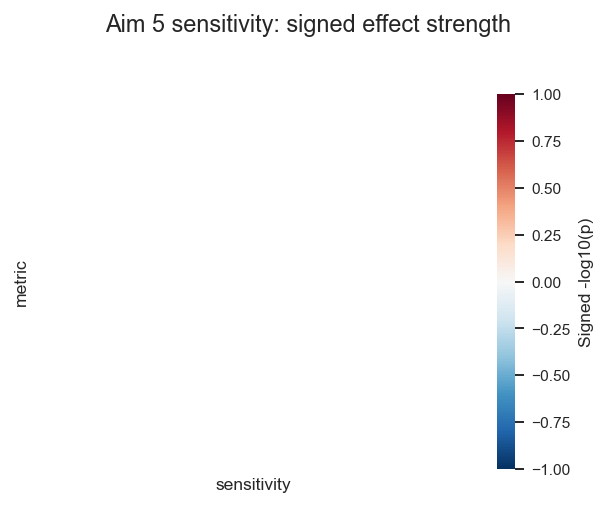

Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim5_sensitivity_forest.png
Saved /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/figures/aim5_sensitivity_forest.pdf


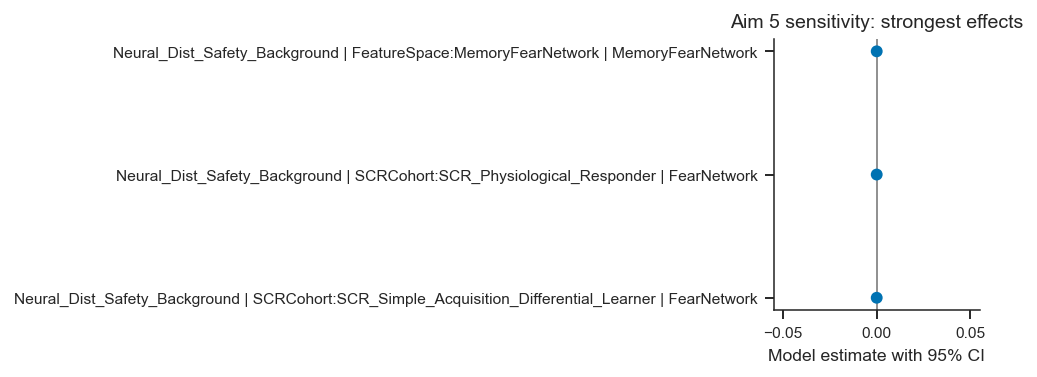

,status,outcome,term,estimate,std_error,t,p,ci_low,ci_high,n,r2,formula,analysis,sensitivity,metric,feature_space,scr_index,q
35,ok,Neural_Dist_Safety_Background,"C(Group, Treatment(reference='HC'))[T.SAD]:C(D...",0.0,0.0,NaN,NaN,0.0,0.0,51,0.021184,"Q('Neural_Dist_Safety_Background') ~ C(Group, ...",Sensitivity_Aim5_Group_x_Drug,FeatureSpace:MemoryFearNetwork,Neural_Dist_Safety_Background,MemoryFearNetwork,NaN,NaN
36,term_missing,Neural_ThreatLike_Safety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51,NaN,"Q('Neural_ThreatLike_Safety') ~ C(Group, Treat...",Sensitivity_Aim5_Group_x_Drug,FeatureSpace:MemoryFearNetwork,Neural_ThreatLike_Safety,MemoryFearNetwork,NaN,NaN
37,term_missing,Neural_SafetyLike_Safety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51,NaN,"Q('Neural_SafetyLike_Safety') ~ C(Group, Treat...",Sensitivity_Aim5_Group_x_Drug,FeatureSpace:MemoryFearNetwork,Neural_SafetyLike_Safety,MemoryFearNetwork,NaN,NaN
38,term_missing,Neural_Boundary_Separation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51,NaN,"Q('Neural_Boundary_Separation') ~ C(Group, Tre...",Sensitivity_Aim5_Group_x_Drug,FeatureSpace:MemoryFearNetwork,Neural_Boundary_Separation,MemoryFearNetwork,NaN,NaN
39,term_missing,Neural_Decision_Margin_CSS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51,NaN,"Q('Neural_Decision_Margin_CSS') ~ C(Group, Tre...",Sensitivity_Aim5_Group_x_Drug,FeatureSpace:MemoryFearNetwork,Neural_Decision_Margin_CSS,MemoryFearNetwork,NaN,NaN
40,term_missing,Neural_Safety_Trajectory_Slope,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51,NaN,"Q('Neural_Safety_Trajectory_Slope') ~ C(Group,...",Sensitivity_Aim5_Group_x_Drug,FeatureSpace:MemoryFearNetwork,Neural_Safety_Trajectory_Slope,MemoryFearNetwork,NaN,NaN
41,term_missing,Neural_Threat_Trajectory_Slope,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50,NaN,"Q('Neural_Threat_Trajectory_Slope') ~ C(Group,...",Sensitivity_Aim5_Group_x_Drug,FeatureSpace:MemoryFearNetwork,Neural_Threat_Trajectory_Slope,MemoryFearNetwork,NaN,NaN
77,ok,Neural_Dist_Safety_Background,"C(Group, Treatment(reference='HC'))[T.SAD]:C(D...",0.0,0.0,NaN,NaN,0.0,0.0,31,0.056186,"Q('Neural_Dist_Safety_Background') ~ C(Group, ...",Sensitivity_Aim5_Group_x_Drug,SCRCohort:SCR_Physiological_Responder,Neural_Dist_Safety_Background,FearNetwork,NaN,NaN
78,term_missing,Neural_ThreatLike_Safety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31,NaN,"Q('Neural_ThreatLike_Safety') ~ C(Group, Treat...",Sensitivity_Aim5_Group_x_Drug,SCRCohort:SCR_Physiological_Responder,Neural_ThreatLike_Safety,FearNetwork,NaN,NaN
79,term_missing,Neural_SafetyLike_Safety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31,NaN,"Q('Neural_SafetyLike_Safety') ~ C(Group, Treat...",Sensitivity_Aim5_Group_x_Drug,SCRCohort:SCR_Physiological_Responder,Neural_SafetyLike_Safety,FearNetwork,NaN,NaN


In [23]:
render_sensitivity_block('Aim 5', 'Aim5', label_fields=['metric', 'sensitivity', 'feature_space'], filename_prefix='aim5')


## Integrated Manuscript Primary Result Summary

This final audit table uses `manuscript_primary_results.csv` when available. It condenses the primary Aim 2-5 rows in manuscript order, foregrounding effect estimates and confidence intervals while retaining corrected p-values for reference.


In [24]:
if not manuscript_primary_df.empty:
    primary_view = manuscript_primary_df.copy()
elif primary_all_df.empty:
    frames = [df for df in [aim2_df, aim3_df, aim4_df, aim5_df] if not df.empty]
    primary_view = pd.concat(frames, ignore_index=True, sort=False) if frames else pd.DataFrame()
else:
    primary_view = primary_all_df.copy()

if primary_view.empty:
    print('No primary model results available yet.')
else:
    if not manuscript_primary_df.empty:
        display(hierarchy_result_table(primary_view, n=200))
    else:
        display(tidy_result_table(primary_view, n=160))
    p_col = 'p' if 'p' in primary_view.columns else 'p_value' if 'p_value' in primary_view.columns else None
    if 'q' in primary_view.columns:
        q = numeric_col(primary_view, 'q')
        sig = primary_view[q < 0.05].copy()
        print(f'FDR-significant primary rows: {len(sig)}')
        display(hierarchy_result_table(sig, n=160) if not manuscript_primary_df.empty else tidy_result_table(sig, n=160))
    if p_col:
        p = numeric_col(primary_view, p_col)
        if 'q' in primary_view.columns:
            q = numeric_col(primary_view, 'q')
            nominal = primary_view[(p < 0.05) & ~(q < 0.05)].copy()
        else:
            nominal = primary_view[p < 0.05].copy()
        print(f'Nominal primary rows needing cautious interpretation: {len(nominal)}')
        display(hierarchy_result_table(nominal, n=120) if not manuscript_primary_df.empty else tidy_result_table(nominal, n=120))


,analysis,feature_space,session,Group,metric,metric_role,metric_z,clinical_score,clinical_score_z,scr_index,term,estimate,ci_low,ci_high,p,q,q_within_question,q_within_group,q_within_group_clinical_score,correction_family,aim3_clinical_score_family,n,n_clinical_outliers_removed,n_metric_outliers_removed,r2,status,formula
76,Aim4_SCR_Convergence_Groupwise_Placebo,FearNetwork,Placebo,SAD,Neural_Threat_Trajectory_Slope,NaN,NaN,NaN,NaN,SCR_ThreatMinusSafety,Q('Neural_Threat_Trajectory_Slope'),-0.190249,-0.315749,-0.064748,0.005131,0.143659,NaN,0.143659,NaN,SAD,NaN,22,NaN,NaN,0.451893,ok,Q('SCR_ThreatMinusSafety') ~ Q('Neural_Threat_...
5,Aim2_SAD_HC_Placebo,FearNetwork,NaN,NaN,Neural_Safety_Trajectory_Slope,shared_primary,NaN,NaN,NaN,NaN,"C(Group, Treatment(reference='HC'))[T.SAD]",0.062737,0.019209,0.106265,0.005665,0.011331,0.011331,NaN,NaN,NaN,NaN,51,NaN,NaN,0.227211,ok,"Q('Neural_Safety_Trajectory_Slope') ~ C(Group,..."
59,Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS,FearNetwork,Placebo,HC,Neural_Boundary_Separation,NaN,z_Neural_Boundary_Separation,dass_anxiety,z_dass_anxiety,NaN,Q('z_Neural_Boundary_Separation'),0.505875,0.119959,0.891791,0.012444,0.273767,NaN,0.273767,0.087111,HC,HC | dass_anxiety,27,1.0,0.0,0.251825,ok,Q('z_dass_anxiety') ~ Q('z_Neural_Boundary_Sep...
19,Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS,FearNetwork,Placebo,SAD,Neural_Safety_Trajectory_Slope,NaN,z_Neural_Safety_Trajectory_Slope,lsas_fear,z_lsas_fear,NaN,Q('z_Neural_Safety_Trajectory_Slope'),0.553775,0.069087,1.038464,0.027405,0.651140,NaN,0.651140,0.191836,SAD,SAD | lsas_fear,22,0.0,1.0,0.251166,ok,Q('z_lsas_fear') ~ Q('z_Neural_Safety_Trajecto...
67,Aim4_SCR_Convergence_Groupwise_Placebo,FearNetwork,Placebo,SAD,Neural_Decision_Margin_CSS,NaN,NaN,NaN,NaN,SCR_SafetyMinusBackground,Q('Neural_Decision_Margin_CSS'),0.218028,0.025416,0.410641,0.028683,0.388212,NaN,0.388212,NaN,SAD,NaN,22,NaN,NaN,0.318133,ok,Q('SCR_SafetyMinusBackground') ~ Q('Neural_Dec...
61,Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS,FearNetwork,Placebo,HC,Neural_Safety_Trajectory_Slope,NaN,z_Neural_Safety_Trajectory_Slope,dass_anxiety,z_dass_anxiety,NaN,Q('z_Neural_Safety_Trajectory_Slope'),-0.476273,-0.927187,-0.025359,0.039374,0.273767,NaN,0.273767,0.114070,HC,HC | dass_anxiety,26,1.0,1.0,0.184812,ok,Q('z_dass_anxiety') ~ Q('z_Neural_Safety_Traje...
81,Aim4_SCR_Convergence_Groupwise_Placebo,FearNetwork,Placebo,SAD,Neural_Decision_Margin_CSS,NaN,NaN,NaN,NaN,SCR_Safety_Trajectory_Slope,Q('Neural_Decision_Margin_CSS'),0.039387,0.001673,0.077102,0.041594,0.388212,NaN,0.388212,NaN,SAD,NaN,22,NaN,NaN,0.251930,ok,Q('SCR_Safety_Trajectory_Slope') ~ Q('Neural_D...
44,Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS,FearNetwork,Placebo,HC,Neural_ThreatLike_Safety,NaN,z_Neural_ThreatLike_Safety,lsas_fear,z_lsas_fear,NaN,Q('z_Neural_ThreatLike_Safety'),-0.426677,-0.836308,-0.017046,0.041863,0.273767,NaN,0.273767,0.153028,HC,HC | lsas_fear,28,0.0,0.0,0.165110,ok,Q('z_lsas_fear') ~ Q('z_Neural_ThreatLike_Safe...
45,Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS,FearNetwork,Placebo,HC,Neural_Boundary_Separation,NaN,z_Neural_Boundary_Separation,lsas_fear,z_lsas_fear,NaN,Q('z_Neural_Boundary_Separation'),0.404871,0.012365,0.797376,0.043722,0.273767,NaN,0.273767,0.153028,HC,HC | lsas_fear,28,0.0,0.0,0.162498,ok,Q('z_lsas_fear') ~ Q('z_Neural_Boundary_Separa...
58,Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS,FearNetwork,Placebo,HC,Neural_ThreatLike_Safety,NaN,z_Neural_ThreatLike_Safety,dass_anxiety,z_dass_anxiety,NaN,Q('z_Neural_ThreatLike_Safety'),-0.448411,-0.894441,-0.002380,0.048887,0.273767,NaN,0.273767,0.114070,HC,HC | dass_anxiety,27,1.0,0.0,0.168914,ok,Q('z_dass_anxiety') ~ Q('z_Neural_ThreatLike_S...


FDR-significant primary rows: 1


,analysis,feature_space,session,Group,metric,metric_role,metric_z,clinical_score,clinical_score_z,scr_index,term,estimate,ci_low,ci_high,p,q,q_within_question,q_within_group,q_within_group_clinical_score,correction_family,aim3_clinical_score_family,n,n_clinical_outliers_removed,n_metric_outliers_removed,r2,status,formula
5,Aim2_SAD_HC_Placebo,FearNetwork,NaN,NaN,Neural_Safety_Trajectory_Slope,shared_primary,NaN,NaN,NaN,NaN,"C(Group, Treatment(reference='HC'))[T.SAD]",0.062737,0.019209,0.106265,0.005665,0.011331,0.011331,NaN,NaN,NaN,NaN,51,NaN,NaN,0.227211,ok,"Q('Neural_Safety_Trajectory_Slope') ~ C(Group,..."


Nominal primary rows needing cautious interpretation: 9


,analysis,feature_space,session,Group,metric,metric_role,metric_z,clinical_score,clinical_score_z,scr_index,term,estimate,ci_low,ci_high,p,q,q_within_question,q_within_group,q_within_group_clinical_score,correction_family,aim3_clinical_score_family,n,n_clinical_outliers_removed,n_metric_outliers_removed,r2,status,formula
76,Aim4_SCR_Convergence_Groupwise_Placebo,FearNetwork,Placebo,SAD,Neural_Threat_Trajectory_Slope,NaN,NaN,NaN,NaN,SCR_ThreatMinusSafety,Q('Neural_Threat_Trajectory_Slope'),-0.190249,-0.315749,-0.064748,0.005131,0.143659,NaN,0.143659,NaN,SAD,NaN,22,NaN,NaN,0.451893,ok,Q('SCR_ThreatMinusSafety') ~ Q('Neural_Threat_...
59,Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS,FearNetwork,Placebo,HC,Neural_Boundary_Separation,NaN,z_Neural_Boundary_Separation,dass_anxiety,z_dass_anxiety,NaN,Q('z_Neural_Boundary_Separation'),0.505875,0.119959,0.891791,0.012444,0.273767,NaN,0.273767,0.087111,HC,HC | dass_anxiety,27,1.0,0.0,0.251825,ok,Q('z_dass_anxiety') ~ Q('z_Neural_Boundary_Sep...
19,Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS,FearNetwork,Placebo,SAD,Neural_Safety_Trajectory_Slope,NaN,z_Neural_Safety_Trajectory_Slope,lsas_fear,z_lsas_fear,NaN,Q('z_Neural_Safety_Trajectory_Slope'),0.553775,0.069087,1.038464,0.027405,0.651140,NaN,0.651140,0.191836,SAD,SAD | lsas_fear,22,0.0,1.0,0.251166,ok,Q('z_lsas_fear') ~ Q('z_Neural_Safety_Trajecto...
67,Aim4_SCR_Convergence_Groupwise_Placebo,FearNetwork,Placebo,SAD,Neural_Decision_Margin_CSS,NaN,NaN,NaN,NaN,SCR_SafetyMinusBackground,Q('Neural_Decision_Margin_CSS'),0.218028,0.025416,0.410641,0.028683,0.388212,NaN,0.388212,NaN,SAD,NaN,22,NaN,NaN,0.318133,ok,Q('SCR_SafetyMinusBackground') ~ Q('Neural_Dec...
61,Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS,FearNetwork,Placebo,HC,Neural_Safety_Trajectory_Slope,NaN,z_Neural_Safety_Trajectory_Slope,dass_anxiety,z_dass_anxiety,NaN,Q('z_Neural_Safety_Trajectory_Slope'),-0.476273,-0.927187,-0.025359,0.039374,0.273767,NaN,0.273767,0.114070,HC,HC | dass_anxiety,26,1.0,1.0,0.184812,ok,Q('z_dass_anxiety') ~ Q('z_Neural_Safety_Traje...
81,Aim4_SCR_Convergence_Groupwise_Placebo,FearNetwork,Placebo,SAD,Neural_Decision_Margin_CSS,NaN,NaN,NaN,NaN,SCR_Safety_Trajectory_Slope,Q('Neural_Decision_Margin_CSS'),0.039387,0.001673,0.077102,0.041594,0.388212,NaN,0.388212,NaN,SAD,NaN,22,NaN,NaN,0.251930,ok,Q('SCR_Safety_Trajectory_Slope') ~ Q('Neural_D...
44,Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS,FearNetwork,Placebo,HC,Neural_ThreatLike_Safety,NaN,z_Neural_ThreatLike_Safety,lsas_fear,z_lsas_fear,NaN,Q('z_Neural_ThreatLike_Safety'),-0.426677,-0.836308,-0.017046,0.041863,0.273767,NaN,0.273767,0.153028,HC,HC | lsas_fear,28,0.0,0.0,0.165110,ok,Q('z_lsas_fear') ~ Q('z_Neural_ThreatLike_Safe...
45,Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS,FearNetwork,Placebo,HC,Neural_Boundary_Separation,NaN,z_Neural_Boundary_Separation,lsas_fear,z_lsas_fear,NaN,Q('z_Neural_Boundary_Separation'),0.404871,0.012365,0.797376,0.043722,0.273767,NaN,0.273767,0.153028,HC,HC | lsas_fear,28,0.0,0.0,0.162498,ok,Q('z_lsas_fear') ~ Q('z_Neural_Boundary_Separa...
58,Aim3_Clinical_Relevance_Groupwise_Placebo_ZOLS,FearNetwork,Placebo,HC,Neural_ThreatLike_Safety,NaN,z_Neural_ThreatLike_Safety,dass_anxiety,z_dass_anxiety,NaN,Q('z_Neural_ThreatLike_Safety'),-0.448411,-0.894441,-0.002380,0.048887,0.273767,NaN,0.273767,0.114070,HC,HC | dass_anxiety,27,1.0,0.0,0.168914,ok,Q('z_dass_anxiety') ~ Q('z_Neural_ThreatLike_S...


## Saved Manuscript Artifacts And QC Dashboard

If the post-Hyak manuscript exporter has been run, the notebook displays the saved primary table, convergence matrix, reproducibility/QC dashboard, and compact Markdown summary for cross-checking. These rendered artifacts should agree with the required reproducibility table and pipeline compliance audit above.


In [25]:
for key, label in [
    ('manuscript_primary_md', 'Manuscript primary results'),
    ('aim4_convergence_md', 'Aim 4 convergence matrix'),
    ('qc_dashboard_md', 'Reproducibility/QC dashboard'),
    ('summary_md', 'Compact model summary'),
]:
    path = PATHS[key]
    if path.exists():
        display(Markdown(f'### {label}'))
        display(Markdown(path.read_text()))
    else:
        print(f'Missing {label}: {path}')


Missing Manuscript primary results: /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/manuscript_primary_results.md
Missing Aim 4 convergence matrix: /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/aim4_convergence_matrix.md
Missing Reproducibility/QC dashboard: /Users/xiaoqianxiao/projects/NARSAD/LSS/results/mvpa_l2/stats/mvpa_l2_qc_dashboard.md


### Compact model summary

# MVPA L2 Results Summary

## aim2_group_difference

| analysis | feature_space | metric | term | estimate | ci_low | ci_high | p | q | n | status |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Aim2_SAD_HC_Placebo | FearNetwork | Neural_Safety_Trajectory_Slope | C(Group, Treatment(reference='HC'))[T.SAD] | 0.06274 | 0.01921 | 0.1063 | 0.005665 | 0.03966 | 51 | ok |
| Aim2_SAD_HC_Placebo | FearNetwork | Neural_Threat_Trajectory_Slope | C(Group, Treatment(reference='HC'))[T.SAD] | -0.08397 | -0.1704 | 0.002441 | 0.05655 | 0.148 | 50 | ok |
| Aim2_SAD_HC_Placebo | FearNetwork | Neural_Boundary_Separation | C(Group, Treatment(reference='HC'))[T.SAD] | 0.1526 | -0.01683 | 0.322 | 0.0764 | 0.148 | 51 | ok |
| Aim2_SAD_HC_Placebo | FearNetwork | Neural_Dist_Safety_Background | C(Group, Treatment(reference='HC'))[T.SAD] | 0.03586 | -0.005085 | 0.0768 | 0.08459 | 0.148 | 51 | ok |
| Aim2_SAD_HC_Placebo | FearNetwork | Neural_ThreatLike_Safety | C(Group, Treatment(reference='HC'))[T.SAD] | -0.06809 | -0.1747 | 0.03853 | 0.2052 | 0.2394 | 51 | ok |
| Aim2_SAD_HC_Placebo | FearNetwork | Neural_SafetyLike_Safety | C(Group, Treatment(reference='HC'))[T.SAD] | 0.06809 | -0.03853 | 0.1747 | 0.2052 | 0.2394 | 51 | ok |
| Aim2_SAD_HC_Placebo | FearNetwork | Neural_Decision_Margin_CSS | C(Group, Treatment(reference='HC'))[T.SAD] | 0.002223 | -0.02057 | 0.02502 | 0.8453 | 0.8453 | 51 | ok |

## aim3_clinical_relevance

| analysis | feature_space | Group | metric | metric_z | clinical_score | clinical_score_z | term | estimate | ci_low | ci_high | p | q | n | n_clinical_outliers_removed | n_metric_outliers_removed | status |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Aim3_Clinical_Relevance_Groupwise_ZOLS | FearNetwork | HC | Neural_Boundary_Separation | z_Neural_Boundary_Separation | dass_anxiety | z_dass_anxiety | Q('z_Neural_Boundary_Separation') | 0.4228 | 0.1003 | 0.7454 | 0.01244 | 0.3422 | 27 | 2 | 0 | ok |
| Aim3_Clinical_Relevance_Groupwise_ZOLS | FearNetwork | SAD | Neural_Safety_Trajectory_Slope | z_Neural_Safety_Trajectory_Slope | lsas_fear | z_lsas_fear | Q('z_Neural_Safety_Trajectory_Slope') | 0.5997 | 0.07482 | 1.125 | 0.02741 | 0.3422 | 22 | 0 | 1 | ok |
| Aim3_Clinical_Relevance_Groupwise_ZOLS | FearNetwork | HC | Neural_Safety_Trajectory_Slope | z_Neural_Safety_Trajectory_Slope | dass_anxiety | z_dass_anxiety | Q('z_Neural_Safety_Trajectory_Slope') | -0.3981 | -0.775 | -0.0212 | 0.03937 | 0.3422 | 26 | 2 | 1 | ok |
| Aim3_Clinical_Relevance_Groupwise_ZOLS | FearNetwork | HC | Neural_SafetyLike_Safety | z_Neural_SafetyLike_Safety | lsas_fear | z_lsas_fear | Q('z_Neural_SafetyLike_Safety') | 0.4192 | 0.01675 | 0.8217 | 0.04186 | 0.3422 | 28 | 0 | 0 | ok |
| Aim3_Clinical_Relevance_Groupwise_ZOLS | FearNetwork | HC | Neural_ThreatLike_Safety | z_Neural_ThreatLike_Safety | lsas_fear | z_lsas_fear | Q('z_Neural_ThreatLike_Safety') | -0.4192 | -0.8217 | -0.01675 | 0.04186 | 0.3422 | 28 | 0 | 0 | ok |
| Aim3_Clinical_Relevance_Groupwise_ZOLS | FearNetwork | HC | Neural_Boundary_Separation | z_Neural_Boundary_Separation | lsas_fear | z_lsas_fear | Q('z_Neural_Boundary_Separation') | 0.3978 | 0.01215 | 0.7835 | 0.04372 | 0.3422 | 28 | 0 | 0 | ok |
| Aim3_Clinical_Relevance_Groupwise_ZOLS | FearNetwork | HC | Neural_ThreatLike_Safety | z_Neural_ThreatLike_Safety | dass_anxiety | z_dass_anxiety | Q('z_Neural_ThreatLike_Safety') | -0.3748 | -0.7476 | -0.001989 | 0.04889 | 0.3422 | 27 | 2 | 0 | ok |
| Aim3_Clinical_Relevance_Groupwise_ZOLS | FearNetwork | HC | Neural_SafetyLike_Safety | z_Neural_SafetyLike_Safety | dass_anxiety | z_dass_anxiety | Q('z_Neural_SafetyLike_Safety') | 0.3748 | 0.001989 | 0.7476 | 0.04889 | 0.3422 | 27 | 2 | 0 | ok |
| Aim3_Clinical_Relevance_Groupwise_ZOLS | FearNetwork | SAD | Neural_Safety_Trajectory_Slope | z_Neural_Safety_Trajectory_Slope | lsas_total | z_lsas_total | Q('z_Neural_Safety_Trajectory_Slope') | 0.4793 | -0.03806 | 0.9967 | 0.06739 | 0.4193 | 22 | 0 | 1 | ok |
| Aim3_Clinical_Relevance_Groupwise_ZOLS | FearNetwork | SAD | Neural_Decision_Margin_CSS | z_Neural_Decision_Margin_CSS | dass_anxiety | z_dass_anxiety | Q('z_Neural_Decision_Margin_CSS') | -0.3397 | -0.7407 | 0.06125 | 0.09169 | 0.5135 | 21 | 2 | 0 | ok |
| Aim3_Clinical_Relevance_Groupwise_ZOLS | FearNetwork | HC | Neural_Safety_Trajectory_Slope | z_Neural_Safety_Trajectory_Slope | lsas_fear | z_lsas_fear | Q('z_Neural_Safety_Trajectory_Slope') | -0.3424 | -0.7838 | 0.09894 | 0.1222 | 0.6219 | 27 | 0 | 1 | ok |
| Aim3_Clinical_Relevance_Groupwise_ZOLS | FearNetwork | SAD | Neural_Boundary_Separation | z_Neural_Boundary_Separation | dass_anxiety | z_dass_anxiety | Q('z_Neural_Boundary_Separation') | 0.3094 | -0.1361 | 0.7548 | 0.1611 | 0.6606 | 21 | 2 | 0 | ok |
| Aim3_Clinical_Relevance_Groupwise_ZOLS | FearNetwork | HC | Neural_SafetyLike_Safety | z_Neural_SafetyLike_Safety | lsas_total | z_lsas_total | Q('z_Neural_SafetyLike_Safety') | 0.246 | -0.1155 | 0.6075 | 0.173 | 0.6606 | 28 | 0 | 0 | ok |
| Aim3_Clinical_Relevance_Groupwise_ZOLS | FearNetwork | HC | Neural_ThreatLike_Safety | z_Neural_ThreatLike_Safety | lsas_total | z_lsas_total | Q('z_Neural_ThreatLike_Safety') | -0.246 | -0.6075 | 0.1155 | 0.173 | 0.6606 | 28 | 0 | 0 | ok |
| Aim3_Clinical_Relevance_Groupwise_ZOLS | FearNetwork | SAD | Neural_Safety_Trajectory_Slope | z_Neural_Safety_Trajectory_Slope | lsas_avoid | z_lsas_avoid | Q('z_Neural_Safety_Trajectory_Slope') | 0.296 | -0.2243 | 0.8164 | 0.2475 | 0.6606 | 22 | 0 | 1 | ok |
| Aim3_Clinical_Relevance_Groupwise_ZOLS | FearNetwork | SAD | Neural_Dist_Safety_Background | z_Neural_Dist_Safety_Background | lsas_fear | z_lsas_fear | Q('z_Neural_Dist_Safety_Background') | 0.2771 | -0.2169 | 0.7711 | 0.255 | 0.6606 | 23 | 0 | 1 | ok |
| Aim3_Clinical_Relevance_Groupwise_ZOLS | FearNetwork | SAD | Neural_SafetyLike_Safety | z_Neural_SafetyLike_Safety | lsas_fear | z_lsas_fear | Q('z_Neural_SafetyLike_Safety') | -0.2877 | -0.8185 | 0.2431 | 0.2708 | 0.6606 | 23 | 0 | 0 | ok |
| Aim3_Clinical_Relevance_Groupwise_ZOLS | FearNetwork | SAD | Neural_ThreatLike_Safety | z_Neural_ThreatLike_Safety | lsas_fear | z_lsas_fear | Q('z_Neural_ThreatLike_Safety') | 0.2877 | -0.2431 | 0.8185 | 0.2708 | 0.6606 | 23 | 0 | 0 | ok |
| Aim3_Clinical_Relevance_Groupwise_ZOLS | FearNetwork | SAD | Neural_SafetyLike_Safety | z_Neural_SafetyLike_Safety | lsas_total | z_lsas_total | Q('z_Neural_SafetyLike_Safety') | -0.2666 | -0.7678 | 0.2346 | 0.2795 | 0.6606 | 23 | 0 | 0 | ok |
| Aim3_Clinical_Relevance_Groupwise_ZOLS | FearNetwork | SAD | Neural_ThreatLike_Safety | z_Neural_ThreatLike_Safety | lsas_total | z_lsas_total | Q('z_Neural_ThreatLike_Safety') | 0.2666 | -0.2346 | 0.7678 | 0.2795 | 0.6606 | 23 | 0 | 0 | ok |

## aim4_scr_convergence

| analysis | feature_space | metric | scr_index | term | estimate | ci_low | ci_high | p | q | n | status |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Aim4_SCR_Convergence | FearNetwork | Neural_Threat_Trajectory_Slope | SCR_ThreatMinusSafety | Q('Neural_Threat_Trajectory_Slope') | -0.04291 | -0.08618 | 0.0003659 | 0.05189 | 0.8044 | 50 | ok |
| Aim4_SCR_Convergence | FearNetwork | Neural_Decision_Margin_CSS | SCR_SafetyMinusBackground | Q('Neural_Decision_Margin_CSS') | 0.1835 | -0.04497 | 0.4121 | 0.1127 | 0.8044 | 50 | ok |
| Aim4_SCR_Convergence | FearNetwork | Neural_ThreatLike_Safety | SCR_ThreatMinusSafety | Q('Neural_ThreatLike_Safety') | -0.02786 | -0.06277 | 0.007045 | 0.1149 | 0.8044 | 50 | ok |
| Aim4_SCR_Convergence | FearNetwork | Neural_SafetyLike_Safety | SCR_ThreatMinusSafety | Q('Neural_SafetyLike_Safety') | 0.02786 | -0.007045 | 0.06277 | 0.1149 | 0.8044 | 50 | ok |
| Aim4_SCR_Convergence | FearNetwork | Neural_SafetyLike_Safety | SCR_Safety_Trajectory_Slope | Q('Neural_SafetyLike_Safety') | 0.007172 | -0.003758 | 0.0181 | 0.193 | 0.9006 | 50 | ok |
| Aim4_SCR_Convergence | FearNetwork | Neural_ThreatLike_Safety | SCR_Safety_Trajectory_Slope | Q('Neural_ThreatLike_Safety') | -0.007172 | -0.0181 | 0.003758 | 0.193 | 0.9006 | 50 | ok |
| Aim4_SCR_Convergence | FearNetwork | Neural_Decision_Margin_CSS | SCR_Threat_Trajectory_Slope | Q('Neural_Decision_Margin_CSS') | 0.02471 | -0.0223 | 0.07172 | 0.2954 | 0.9923 | 50 | ok |
| Aim4_SCR_Convergence | FearNetwork | Neural_Dist_Safety_Background | SCR_Safety_Trajectory_Slope | Q('Neural_Dist_Safety_Background') | 0.01342 | -0.01554 | 0.04238 | 0.3555 | 0.9923 | 50 | ok |
| Aim4_SCR_Convergence | FearNetwork | Neural_Dist_Safety_Background | SCR_Threat_Trajectory_Slope | Q('Neural_Dist_Safety_Background') | 0.01179 | -0.01453 | 0.03811 | 0.3719 | 0.9923 | 50 | ok |
| Aim4_SCR_Convergence | FearNetwork | Neural_Boundary_Separation | SCR_ThreatMinusSafety | Q('Neural_Boundary_Separation') | 0.009315 | -0.01334 | 0.03197 | 0.412 | 0.9923 | 50 | ok |
| Aim4_SCR_Convergence | FearNetwork | Neural_Decision_Margin_CSS | SCR_Safety_Trajectory_Slope | Q('Neural_Decision_Margin_CSS') | 0.01925 | -0.03283 | 0.07132 | 0.4605 | 0.9923 | 50 | ok |
| Aim4_SCR_Convergence | FearNetwork | Neural_Safety_Trajectory_Slope | SCR_SafetyMinusBackground | Q('Neural_Safety_Trajectory_Slope') | -0.04363 | -0.1654 | 0.07815 | 0.4743 | 0.9923 | 50 | ok |
| Aim4_SCR_Convergence | FearNetwork | Neural_Dist_Safety_Background | SCR_ThreatMinusSafety | Q('Neural_Dist_Safety_Background') | 0.03182 | -0.06191 | 0.1256 | 0.4976 | 0.9923 | 50 | ok |
| Aim4_SCR_Convergence | FearNetwork | Neural_Threat_Trajectory_Slope | SCR_Threat_Trajectory_Slope | Q('Neural_Threat_Trajectory_Slope') | -0.00377 | -0.01645 | 0.008907 | 0.5522 | 0.9923 | 50 | ok |
| Aim4_SCR_Convergence | FearNetwork | Neural_Boundary_Separation | SCR_Safety_Trajectory_Slope | Q('Neural_Boundary_Separation') | 0.001826 | -0.005237 | 0.00889 | 0.6051 | 0.9923 | 50 | ok |
| Aim4_SCR_Convergence | FearNetwork | Neural_SafetyLike_Safety | SCR_SafetyMinusBackground | Q('Neural_SafetyLike_Safety') | -0.009107 | -0.05901 | 0.0408 | 0.7149 | 0.9923 | 50 | ok |
| Aim4_SCR_Convergence | FearNetwork | Neural_ThreatLike_Safety | SCR_SafetyMinusBackground | Q('Neural_ThreatLike_Safety') | 0.009107 | -0.0408 | 0.05901 | 0.7149 | 0.9923 | 50 | ok |
| Aim4_SCR_Convergence | FearNetwork | Neural_Safety_Trajectory_Slope | SCR_Safety_Trajectory_Slope | Q('Neural_Safety_Trajectory_Slope') | -0.003885 | -0.03116 | 0.02339 | 0.7755 | 0.9923 | 50 | ok |
| Aim4_SCR_Convergence | FearNetwork | Neural_Threat_Trajectory_Slope | SCR_SafetyMinusBackground | Q('Neural_Threat_Trajectory_Slope') | -0.007402 | -0.07023 | 0.05542 | 0.8135 | 0.9923 | 50 | ok |
| Aim4_SCR_Convergence | FearNetwork | Neural_Decision_Margin_CSS | SCR_ThreatMinusSafety | Q('Neural_Decision_Margin_CSS') | 0.01764 | -0.1511 | 0.1864 | 0.8342 | 0.9923 | 50 | ok |

## aim5_oxytocin_modulation

| analysis | feature_space | metric | term | estimate | ci_low | ci_high | p | q | n | status |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Aim5_Group_x_Drug | FearNetwork | Neural_Dist_Safety_Background | C(Group, Treatment(reference='HC'))[T.SAD]:C(Drug, Treatment(reference='Placebo'))[T.Oxytocin] | 0 | 0 | 0 |  |  | 51 | ok |
| Aim5_Group_x_Drug | FearNetwork | Neural_ThreatLike_Safety | nan |  |  |  |  |  | 51 | term_missing |
| Aim5_Group_x_Drug | FearNetwork | Neural_SafetyLike_Safety | nan |  |  |  |  |  | 51 | term_missing |
| Aim5_Group_x_Drug | FearNetwork | Neural_Boundary_Separation | nan |  |  |  |  |  | 51 | term_missing |
| Aim5_Group_x_Drug | FearNetwork | Neural_Decision_Margin_CSS | nan |  |  |  |  |  | 51 | term_missing |
| Aim5_Group_x_Drug | FearNetwork | Neural_Safety_Trajectory_Slope | nan |  |  |  |  |  | 51 | term_missing |
| Aim5_Group_x_Drug | FearNetwork | Neural_Threat_Trajectory_Slope | nan |  |  |  |  |  | 50 | term_missing |

## primary_models_all

| analysis | feature_space | Group | metric | metric_z | clinical_score | clinical_score_z | scr_index | term | estimate | ci_low | ci_high | p | q | n | n_clinical_outliers_removed | n_metric_outliers_removed | status |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Aim2_SAD_HC_Placebo | FearNetwork | nan | Neural_Safety_Trajectory_Slope | nan | nan | nan | nan | C(Group, Treatment(reference='HC'))[T.SAD] | 0.06274 | 0.01921 | 0.1063 | 0.005665 | 0.03966 | 51 | nan | nan | ok |
| Aim3_Clinical_Relevance_Groupwise_ZOLS | FearNetwork | HC | Neural_Boundary_Separation | z_Neural_Boundary_Separation | dass_anxiety | z_dass_anxiety | nan | Q('z_Neural_Boundary_Separation') | 0.4228 | 0.1003 | 0.7454 | 0.01244 | 0.3422 | 27 | 2.0 | 0.0 | ok |
| Aim3_Clinical_Relevance_Groupwise_ZOLS | FearNetwork | SAD | Neural_Safety_Trajectory_Slope | z_Neural_Safety_Trajectory_Slope | lsas_fear | z_lsas_fear | nan | Q('z_Neural_Safety_Trajectory_Slope') | 0.5997 | 0.07482 | 1.125 | 0.02741 | 0.3422 | 22 | 0.0 | 1.0 | ok |
| Aim3_Clinical_Relevance_Groupwise_ZOLS | FearNetwork | HC | Neural_Safety_Trajectory_Slope | z_Neural_Safety_Trajectory_Slope | dass_anxiety | z_dass_anxiety | nan | Q('z_Neural_Safety_Trajectory_Slope') | -0.3981 | -0.775 | -0.0212 | 0.03937 | 0.3422 | 26 | 2.0 | 1.0 | ok |
| Aim3_Clinical_Relevance_Groupwise_ZOLS | FearNetwork | HC | Neural_SafetyLike_Safety | z_Neural_SafetyLike_Safety | lsas_fear | z_lsas_fear | nan | Q('z_Neural_SafetyLike_Safety') | 0.4192 | 0.01675 | 0.8217 | 0.04186 | 0.3422 | 28 | 0.0 | 0.0 | ok |
| Aim3_Clinical_Relevance_Groupwise_ZOLS | FearNetwork | HC | Neural_ThreatLike_Safety | z_Neural_ThreatLike_Safety | lsas_fear | z_lsas_fear | nan | Q('z_Neural_ThreatLike_Safety') | -0.4192 | -0.8217 | -0.01675 | 0.04186 | 0.3422 | 28 | 0.0 | 0.0 | ok |
| Aim3_Clinical_Relevance_Groupwise_ZOLS | FearNetwork | HC | Neural_Boundary_Separation | z_Neural_Boundary_Separation | lsas_fear | z_lsas_fear | nan | Q('z_Neural_Boundary_Separation') | 0.3978 | 0.01215 | 0.7835 | 0.04372 | 0.3422 | 28 | 0.0 | 0.0 | ok |
| Aim3_Clinical_Relevance_Groupwise_ZOLS | FearNetwork | HC | Neural_SafetyLike_Safety | z_Neural_SafetyLike_Safety | dass_anxiety | z_dass_anxiety | nan | Q('z_Neural_SafetyLike_Safety') | 0.3748 | 0.001989 | 0.7476 | 0.04889 | 0.3422 | 27 | 2.0 | 0.0 | ok |
| Aim3_Clinical_Relevance_Groupwise_ZOLS | FearNetwork | HC | Neural_ThreatLike_Safety | z_Neural_ThreatLike_Safety | dass_anxiety | z_dass_anxiety | nan | Q('z_Neural_ThreatLike_Safety') | -0.3748 | -0.7476 | -0.001989 | 0.04889 | 0.3422 | 27 | 2.0 | 0.0 | ok |
| Aim4_SCR_Convergence | FearNetwork | nan | Neural_Threat_Trajectory_Slope | nan | nan | nan | SCR_ThreatMinusSafety | Q('Neural_Threat_Trajectory_Slope') | -0.04291 | -0.08618 | 0.0003659 | 0.05189 | 0.8044 | 50 | nan | nan | ok |
| Aim2_SAD_HC_Placebo | FearNetwork | nan | Neural_Threat_Trajectory_Slope | nan | nan | nan | nan | C(Group, Treatment(reference='HC'))[T.SAD] | -0.08397 | -0.1704 | 0.002441 | 0.05655 | 0.148 | 50 | nan | nan | ok |
| Aim3_Clinical_Relevance_Groupwise_ZOLS | FearNetwork | SAD | Neural_Safety_Trajectory_Slope | z_Neural_Safety_Trajectory_Slope | lsas_total | z_lsas_total | nan | Q('z_Neural_Safety_Trajectory_Slope') | 0.4793 | -0.03806 | 0.9967 | 0.06739 | 0.4193 | 22 | 0.0 | 1.0 | ok |
| Aim2_SAD_HC_Placebo | FearNetwork | nan | Neural_Boundary_Separation | nan | nan | nan | nan | C(Group, Treatment(reference='HC'))[T.SAD] | 0.1526 | -0.01683 | 0.322 | 0.0764 | 0.148 | 51 | nan | nan | ok |
| Aim2_SAD_HC_Placebo | FearNetwork | nan | Neural_Dist_Safety_Background | nan | nan | nan | nan | C(Group, Treatment(reference='HC'))[T.SAD] | 0.03586 | -0.005085 | 0.0768 | 0.08459 | 0.148 | 51 | nan | nan | ok |
| Aim3_Clinical_Relevance_Groupwise_ZOLS | FearNetwork | SAD | Neural_Decision_Margin_CSS | z_Neural_Decision_Margin_CSS | dass_anxiety | z_dass_anxiety | nan | Q('z_Neural_Decision_Margin_CSS') | -0.3397 | -0.7407 | 0.06125 | 0.09169 | 0.5135 | 21 | 2.0 | 0.0 | ok |
| Aim4_SCR_Convergence | FearNetwork | nan | Neural_Decision_Margin_CSS | nan | nan | nan | SCR_SafetyMinusBackground | Q('Neural_Decision_Margin_CSS') | 0.1835 | -0.04497 | 0.4121 | 0.1127 | 0.8044 | 50 | nan | nan | ok |
| Aim4_SCR_Convergence | FearNetwork | nan | Neural_ThreatLike_Safety | nan | nan | nan | SCR_ThreatMinusSafety | Q('Neural_ThreatLike_Safety') | -0.02786 | -0.06277 | 0.007045 | 0.1149 | 0.8044 | 50 | nan | nan | ok |
| Aim4_SCR_Convergence | FearNetwork | nan | Neural_SafetyLike_Safety | nan | nan | nan | SCR_ThreatMinusSafety | Q('Neural_SafetyLike_Safety') | 0.02786 | -0.007045 | 0.06277 | 0.1149 | 0.8044 | 50 | nan | nan | ok |
| Aim3_Clinical_Relevance_Groupwise_ZOLS | FearNetwork | HC | Neural_Safety_Trajectory_Slope | z_Neural_Safety_Trajectory_Slope | lsas_fear | z_lsas_fear | nan | Q('z_Neural_Safety_Trajectory_Slope') | -0.3424 | -0.7838 | 0.09894 | 0.1222 | 0.6219 | 27 | 0.0 | 1.0 | ok |
| Aim3_Clinical_Relevance_Groupwise_ZOLS | FearNetwork | SAD | Neural_Boundary_Separation | z_Neural_Boundary_Separation | dass_anxiety | z_dass_anxiety | nan | Q('z_Neural_Boundary_Separation') | 0.3094 | -0.1361 | 0.7548 | 0.1611 | 0.6606 | 21 | 2.0 | 0.0 | ok |

## sensitivity_models_all

| analysis | sensitivity | feature_space | metric | scr_index | term | estimate | ci_low | ci_high | p | q | n | status |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Sensitivity_Aim2_Group | SCRCohort:SCR_Physiological_Responder | FearNetwork | Neural_Boundary_Separation | nan | C(Group, Treatment(reference='HC'))[T.SAD] | 0.3195 | 0.1039 | 0.5352 | 0.005199 | 0.01792 | 31 | ok |
| Sensitivity_Aim2_Group | SCRCohort:SCR_Physiological_Responder | FearNetwork | Neural_Safety_Trajectory_Slope | nan | C(Group, Treatment(reference='HC'))[T.SAD] | 0.02181 | 0.005946 | 0.03768 | 0.008872 | 0.01792 | 31 | ok |
| Sensitivity_Aim2_Group | SCRCohort:SCR_Physiological_Responder | FearNetwork | Neural_ThreatLike_Safety | nan | C(Group, Treatment(reference='HC'))[T.SAD] | -0.1905 | -0.3322 | -0.04892 | 0.01024 | 0.01792 | 31 | ok |
| Sensitivity_Aim2_Group | SCRCohort:SCR_Physiological_Responder | FearNetwork | Neural_SafetyLike_Safety | nan | C(Group, Treatment(reference='HC'))[T.SAD] | 0.1905 | 0.04892 | 0.3322 | 0.01024 | 0.01792 | 31 | ok |
| Sensitivity_Aim4_SCR | SCRCohort:SCR_Late_Phase_Sensitivity_Learner | FearNetwork | Neural_ThreatLike_Safety | SCR_SafetyMinusBackground | Q('Neural_ThreatLike_Safety') | -0.121 | -0.1913 | -0.05065 | 0.01198 | 0.1677 | 8 | ok |
| Sensitivity_Aim4_SCR | SCRCohort:SCR_Late_Phase_Sensitivity_Learner | FearNetwork | Neural_SafetyLike_Safety | SCR_SafetyMinusBackground | Q('Neural_SafetyLike_Safety') | 0.121 | 0.05065 | 0.1913 | 0.01198 | 0.1677 | 8 | ok |
| Sensitivity_Aim2_Group | SCRCohort:SCR_Simple_Acquisition_Differential_Learner | FearNetwork | Neural_ThreatLike_Safety | nan | C(Group, Treatment(reference='HC'))[T.SAD] | -0.2217 | -0.3877 | -0.05572 | 0.01203 | 0.03853 | 20 | ok |
| Sensitivity_Aim2_Group | SCRCohort:SCR_Simple_Acquisition_Differential_Learner | FearNetwork | Neural_SafetyLike_Safety | nan | C(Group, Treatment(reference='HC'))[T.SAD] | 0.2217 | 0.05572 | 0.3877 | 0.01203 | 0.03853 | 20 | ok |
| Sensitivity_Aim2_Group | SCRCohort:SCR_Simple_Acquisition_Differential_Learner | FearNetwork | Neural_Boundary_Separation | nan | C(Group, Treatment(reference='HC'))[T.SAD] | 0.304 | 0.06331 | 0.5446 | 0.01651 | 0.03853 | 20 | ok |
| Sensitivity_Aim2_Group | SCRCohort:SCR_Habituation_Adjusted_Learner | FearNetwork | Neural_SafetyLike_Safety | nan | C(Group, Treatment(reference='HC'))[T.SAD] | 0.1852 | 0.01547 | 0.3548 | 0.03493 | 0.1222 | 16 | ok |
| Sensitivity_Aim2_Group | SCRCohort:SCR_Habituation_Adjusted_Learner | FearNetwork | Neural_ThreatLike_Safety | nan | C(Group, Treatment(reference='HC'))[T.SAD] | -0.1852 | -0.3548 | -0.01547 | 0.03493 | 0.1222 | 16 | ok |
| Sensitivity_Aim4_SCR | SCRCohort:SCR_Late_Phase_Sensitivity_Learner | FearNetwork | Neural_Threat_Trajectory_Slope | SCR_Safety_Trajectory_Slope | Q('Neural_Threat_Trajectory_Slope') | -0.00666 | -0.01287 | -0.0004454 | 0.04213 | 0.2397 | 8 | ok |
| Sensitivity_Aim4_SCR | SCRCohort:SCR_Late_Phase_Sensitivity_Learner | FearNetwork | Neural_SafetyLike_Safety | SCR_Threat_Trajectory_Slope | Q('Neural_SafetyLike_Safety') | -0.07843 | -0.1521 | -0.004783 | 0.0428 | 0.2397 | 8 | ok |
| Sensitivity_Aim4_SCR | SCRCohort:SCR_Late_Phase_Sensitivity_Learner | FearNetwork | Neural_ThreatLike_Safety | SCR_Threat_Trajectory_Slope | Q('Neural_ThreatLike_Safety') | 0.07843 | 0.004783 | 0.1521 | 0.0428 | 0.2397 | 8 | ok |
| Sensitivity_Aim4_SCR | FeatureSpace:MemoryFearNetwork | MemoryFearNetwork | Neural_Threat_Trajectory_Slope | SCR_ThreatMinusSafety | Q('Neural_Threat_Trajectory_Slope') | -0.04678 | -0.09265 | -0.0009175 | 0.04577 | 0.6759 | 50 | ok |
| Sensitivity_Aim4_SCR | SCRCohort:SCR_Habituation_Adjusted_Learner | FearNetwork | Neural_SafetyLike_Safety | SCR_Threat_Trajectory_Slope | Q('Neural_SafetyLike_Safety') | 0.0314 | -0.0003958 | 0.0632 | 0.05241 | 0.5343 | 15 | ok |
| Sensitivity_Aim4_SCR | SCRCohort:SCR_Habituation_Adjusted_Learner | FearNetwork | Neural_ThreatLike_Safety | SCR_Threat_Trajectory_Slope | Q('Neural_ThreatLike_Safety') | -0.0314 | -0.0632 | 0.0003958 | 0.05241 | 0.5343 | 15 | ok |
| Sensitivity_Aim2_Group | SCRCohort:SCR_Habituation_Adjusted_Learner | FearNetwork | Neural_Boundary_Separation | nan | C(Group, Treatment(reference='HC'))[T.SAD] | 0.2598 | -0.02519 | 0.5448 | 0.07034 | 0.1641 | 16 | ok |
| Sensitivity_Aim4_SCR | SCRCohort:SCR_Late_Phase_Sensitivity_Learner | FearNetwork | Neural_Boundary_Separation | SCR_SafetyMinusBackground | Q('Neural_Boundary_Separation') | 0.103 | -0.01695 | 0.2229 | 0.07177 | 0.3064 | 8 | ok |
| Sensitivity_Aim4_SCR | SCRCohort:SCR_Physiological_Responder | FearNetwork | Neural_Decision_Margin_CSS | SCR_SafetyMinusBackground | Q('Neural_Decision_Margin_CSS') | 0.3462 | -0.03852 | 0.7309 | 0.07568 | 0.9616 | 30 | ok |


## Reporting Checklist

Before using these figures or tables in a manuscript, confirm:

- Subject counts and feature counts are reported for every primary and sensitivity analysis; missing optional outputs are labeled as missing rather than interpreted as null.
- Aim 1 primary decoding tests are restricted to `SAD-Placebo` and `HC-Placebo` subjects in the primary `FearNetwork` feature space.
- Aim 1 primary inference uses subject-level forced-choice accuracy and the 5,000-iteration subject-label permutation null.
- Aim 1 cross-group decoding is reported as secondary functional specificity or a 2AFC generalization index, not as the primary identification test.
- Aim 1 spatial specificity is reported as discrimination-weight cosine similarity, with Haufe-transformed maps treated as secondary interpretive evidence.
- Aim 1 SCR responder/learner analyses are labeled as placebo-focused sensitivity checks and are not split by drug unless a future sample-size decision supports that extension.
- Aim 2 is organized by the three planned questions: geometry, decision certainty, and learning dynamics.
- Aim 3 labels `dass_anxiety` and `lsas_total` as primary clinical scores; LSAS subscales are support/contextual only.
- Aim 4 uses the convergence matrix to evaluate neural-SCR alignment by effect size and confidence interval, not p-values alone.
- Aim 4 separates full-sample inference from SCR responder/learner sensitivity cohorts.
- Aim 5 is the only full placebo/oxytocin `Group * Drug` model family in this notebook.
- The pipeline compliance audit has been reviewed for decoder, CV, permutation, leakage-prevention, and fallback-checkpoint status.
- Saved figures and Markdown/CSV exports are regenerated after any upstream Hyak rerun or result-table update.
